In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
# try:
#     from cellacdc import cca_functions
#     from cellacdc import myutils
# except FileNotFoundError:
#     # Check if user has developer version --> add the Cell_ACDC/cellacdc
#     # folder to path and import from thre
#     sys.path.insert(0, '../cellacdc/')
#     from cellacdc import cca_functions
#     from cellacdc import myutils

# ***Import nutrient switch data - original four strains*** 
# ***Import nutrient switch data - Cln3 deletions and MK strains***
# ***Import nutrient switch data - MK strains with deletions*** 
# ***Import steady state data*** 

In [3]:
NS_original_4strains= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\Analysed Live cell microscopy data\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_cln3dels_MKoriginals = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\Analysed Live cell microscopy data\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_MKstrains_withOriginalDels = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\Analysed Live cell microscopy data\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
SS_SCDnSCGE = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\Analysed Live cell microscopy data\steadystate_analysed_fornutswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")

C:\Users\timon\AppData\Local\Temp\ipykernel_42552\3144853366.py:1: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_original_4strains= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\Analysed Live cell microscopy data\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\timon\AppData\Local\Temp\ipykernel_42552\3144853366.py:2: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_cln3dels_MKoriginals = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\Analysed Live cell microscopy data\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\timon\AppData\Local\Temp\ipykernel_42552\3144853366.py:3: DtypeWarning: Columns (343) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_MKstrains_withOriginalDels = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scri

# ***update rep for MMY in the additional nutrient switch data*** 

In [4]:
#### because NS_cln3dels_MKoriginals has MMY cells with same rep, pos and Cell_ID as NS_original_4strains, edit rep column for these cells
# NS_MKstrains_withOriginalDels experiments did not have MMY 

NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 1), 'rep'] = 4
NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 2), 'rep'] = 5

NS_cln3dels_MKoriginals['f_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["strain"]}_{x["position"]}_Cell_{x["Cell_ID"]}_Gen_{int(x["generation_num"])}', axis=1)
NS_cln3dels_MKoriginals['rep_str_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["f_pos_cell_id"]}_Rep_{int(x["rep"])}', axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.drop(['f_pos_cell_id'], axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.rename(columns={"rep_str_pos_cell_id": "f_pos_cell_id"})


# ***because acdc output columns changed over the years, find differences between column names of different dfs and edit them*** 

In [5]:
NS_MKstrains_withOriginalDels.drop(columns =['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',  'num_objects', 'num_objects_rel',
       'will_divide', 'will_divide_rel'], inplace = True)
#print(NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns))

In [6]:
NS_cln3dels_MKoriginals.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [7]:
NS_MKstrains_withOriginalDels.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [8]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index(['does_cell_die_in_this_phase', 'vol_added_since_prev_frame_fl'], dtype='object')

In [9]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [10]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index(['does_cell_die_in_this_phase'], dtype='object')

In [11]:
NS_original_4strains = NS_original_4strains.rename(columns={"vol_added_since_last_frame": "vol_added_since_prev_frame_fl"})
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"Strain": "strain"})

In [12]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Add 'does_cell_die_in_this_phase' column to the datasets that don't have it*** 

In [13]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_original_4strains['rep'].unique():
        rep_df = NS_original_4strains[NS_original_4strains['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_original_4strains = pd.concat(list_for_joining)   

In [14]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_cln3dels_MKoriginals['rep'].unique():
        rep_df = NS_cln3dels_MKoriginals[NS_cln3dels_MKoriginals['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_cln3dels_MKoriginals = pd.concat(list_for_joining)   

In [15]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [16]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [17]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [18]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Drop columns not needed for analysis*** 

In [19]:
#drop columns we don't need
cols_to_be_dropped = ['Dia_Ph3_mean', 'Dia_Ph3_sum', 'Dia_Ph3_amount_autoBkgr', 'Dia_Ph3_amount_dataPrepBkgr', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox',
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl', 
'Dia_Ph3_median', 'Dia_Ph3_min', 'Dia_Ph3_max', 'Dia_Ph3_q25', 'Dia_Ph3_q75', 'Dia_Ph3_q05', 'Dia_Ph3_q95', 'Dia_Ph3_autoBkgr_bkgrVal_median', 
'Dia_Ph3_autoBkgr_bkgrVal_mean', 'Dia_Ph3_autoBkgr_bkgrVal_q75', 'Dia_Ph3_autoBkgr_bkgrVal_q25', 'Dia_Ph3_autoBkgr_bkgrVal_q95', 'Dia_Ph3_autoBkgr_bkgrVal_q05', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_median', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q75', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_q95', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05', 'Dia_Ph3_CV', 'major_axis_length_gui', 'minor_axis_length_gui', 'inertia_tensor_eigvals-0', 
'inertia_tensor_eigvals-1', 'equivalent_diameter', 'moments-0-0', 'moments-0-1', 'moments-0-2', 'moments-0-3', 'moments-1-0', 'moments-1-1', 'moments-1-2',
'moments-1-3', 'moments-2-0', 'moments-2-1', 'moments-2-2', 'moments-2-3', 'moments-3-0', 'moments-3-1', 'moments-3-2', 'moments-3-3', 'area_gui', 'solidity_gui', 
'extent', 'inertia_tensor-0-0', 'inertia_tensor-0-1', 'inertia_tensor-1-0', 'inertia_tensor-1-1', 'filled_area_gui', 'centroid-0', 'centroid-1', 'bbox_area',
'local_centroid-0', 'local_centroid-1', 'convex_area_gui', 'euler_number', 'moments_normalized-0-0', 'moments_normalized-0-1', 'moments_normalized-0-2',
'moments_normalized-0-3', 'moments_normalized-1-0', 'moments_normalized-1-1', 'moments_normalized-1-2', 'moments_normalized-1-3', 'moments_normalized-2-0',
'moments_normalized-2-1', 'moments_normalized-2-2', 'moments_normalized-2-3', 'moments_normalized-3-0', 'moments_normalized-3-1', 'moments_normalized-3-2',
'moments_normalized-3-3', 'moments_central-0-0', 'moments_central-0-1', 'moments_central-0-2', 'moments_central-0-3', 'moments_central-1-0', 'moments_central-1-1',
'moments_central-1-2', 'moments_central-1-3', 'moments_central-2-0', 'moments_central-2-1', 'moments_central-2-2', 'moments_central-2-3', 'moments_central-3-0',
'moments_central-3-1', 'moments_central-3-2', 'moments_central-3-3', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'area', 'convex_area', 'filled_area', 'major_axis_length','minor_axis_length', 'orientation', 'perimeter', 'centroid_y', 'centroid_x', 'solidity','velocity_pixel', 'velocity_um','Dia_Ph3_mean_rel', 'Dia_Ph3_sum_rel','Dia_Ph3_amount_autoBkgr_rel', 'Dia_Ph3_amount_dataPrepBkgr_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox_rel', 
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl_rel', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl_rel', 
'Dia_Ph3_median_rel', 'Dia_Ph3_min_rel', 'Dia_Ph3_max_rel', 'Dia_Ph3_q25_rel', 'Dia_Ph3_q75_rel', 'Dia_Ph3_q05_rel', 'Dia_Ph3_q95_rel',
'Dia_Ph3_autoBkgr_bkgrVal_median_rel', 'Dia_Ph3_autoBkgr_bkgrVal_mean_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q75_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q25_rel',
'Dia_Ph3_autoBkgr_bkgrVal_q95_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q05_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_median_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean_rel',
'Dia_Ph3_dataPrepBkgr_bkgrVal_q75_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q95_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05_rel', 
'Dia_Ph3_CV_rel', 'major_axis_length_gui_rel', 'minor_axis_length_gui_rel', 'inertia_tensor_eigvals-0_rel', 'inertia_tensor_eigvals-1_rel', 'equivalent_diameter_rel','moments-0-0_rel', 'moments-0-1_rel', 'moments-0-2_rel', 'moments-0-3_rel', 'moments-1-0_rel', 'moments-1-1_rel', 'moments-1-2_rel', 'moments-1-3_rel', 'moments-2-0_rel', 'moments-2-1_rel', 'moments-2-2_rel', 'moments-2-3_rel', 'moments-3-0_rel', 'moments-3-1_rel', 'moments-3-2_rel', 'moments-3-3_rel','area_gui_rel', 'solidity_gui_rel', 'extent_rel', 'inertia_tensor-0-0_rel', 'inertia_tensor-0-1_rel', 'inertia_tensor-1-0_rel', 'inertia_tensor-1-1_rel','filled_area_gui_rel', 'centroid-0_rel', 'centroid-1_rel', 'bbox_area_rel', 'local_centroid-0_rel', 'local_centroid-1_rel', 'convex_area_gui_rel', 'euler_number_rel', 'moments_normalized-0-0_rel', 'moments_normalized-0-1_rel', 'moments_normalized-0-2_rel', 'moments_normalized-0-3_rel', 
'moments_normalized-1-0_rel', 'moments_normalized-1-1_rel', 'moments_normalized-1-2_rel', 'moments_normalized-1-3_rel', 'moments_normalized-2-0_rel',
'moments_normalized-2-1_rel', 'moments_normalized-2-2_rel', 'moments_normalized-2-3_rel', 'moments_normalized-3-0_rel', 'moments_normalized-3-1_rel', 
'moments_normalized-3-2_rel', 'moments_normalized-3-3_rel', 'moments_central-0-0_rel', 'moments_central-0-1_rel', 'moments_central-0-2_rel', 
'moments_central-0-3_rel', 'moments_central-1-0_rel', 'moments_central-1-1_rel', 'moments_central-1-2_rel', 'moments_central-1-3_rel', 'moments_central-2-0_rel',
'moments_central-2-1_rel', 'moments_central-2-2_rel', 'moments_central-2-3_rel', 'moments_central-3-0_rel', 'moments_central-3-1_rel', 'moments_central-3-2_rel',
'moments_central-3-3_rel', 'bbox-0_rel', 'bbox-1_rel', 'bbox-2_rel', 'bbox-3_rel', 'area_rel', 'convex_area_rel', 'filled_area_rel', 'major_axis_length_rel', 
'minor_axis_length_rel', 'orientation_rel', 'perimeter_rel', 'centroid_y_rel', 'centroid_x_rel', 'solidity_rel', 'velocity_pixel_rel', 'velocity_um_rel',
'phase_Dia_Ph3_amount_at_beginning', 'phase_Dia_Ph3_mean_at_beginning', 'phase_Dia_Ph3_concentration_at_beginning', 'phase_Dia_Ph3_concentration_at_end', 
'phase_Dia_Ph3_combined_amount_at_beginning', 'phase_Dia_Ph3_combined_amount_at_end', 'Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
'Dia_Ph3_manualBkgr_bkgrVal_mean','Dia_Ph3_manualBkgr_bkgrVal_mean_rel','Dia_Ph3_manualBkgr_bkgrVal_median','Dia_Ph3_manualBkgr_bkgrVal_median_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel','Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel','Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox','bbox_rel', 'centroid', 'centroid_rel','daughter_disappears_before_division',
'daughter_disappears_before_division_rel', 'disappears_before_division','disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor','inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel','inertia_tensor_rel', 'label', 'label_rel', 'local_centroid','local_centroid_rel', 'moments', 'moments_central','moments_central_rel','moments_normalized','moments_normalized_rel','moments_rel', 'num_objects', 'num_objects_rel', 'time_hours','time_hours_rel', 'time_minutes', 'time_minutes_rel', 'will_divide','will_divide_rel']

NS_original_4strains.drop(columns=[col for col in NS_original_4strains if col in cols_to_be_dropped], inplace=True)
NS_cln3dels_MKoriginals.drop(columns=[col for col in NS_cln3dels_MKoriginals if col in cols_to_be_dropped], inplace=True)
NS_MKstrains_withOriginalDels.drop(columns=[col for col in NS_MKstrains_withOriginalDels if col in cols_to_be_dropped], inplace=True)
SS_SCDnSCGE.drop(columns=[col for col in SS_SCDnSCGE if col in cols_to_be_dropped], inplace=True)



In [20]:
print(NS_original_4strains.shape)
print(NS_cln3dels_MKoriginals.shape)
print(NS_MKstrains_withOriginalDels.shape)
print(SS_SCDnSCGE.shape)

NS_original_4strains['experiment_type'] = "nutrient_switch"
NS_cln3dels_MKoriginals['experiment_type'] = "nutrient_switch"
NS_MKstrains_withOriginalDels['experiment_type'] = "nutrient_switch"
SS_SCDnSCGE['experiment_type'] = "steady state"


(482563, 114)
(366669, 114)
(388955, 114)
(366878, 61)


In [21]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [22]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

In [23]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [24]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

# ***All the nutrient-switch dfs have the same columns now. Steady-state dfs were dataprepped with a different script before acdc downstream notebook was published, so they have very different columns.*** 

In [25]:
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"date": "rep", "Position": "position"})
SS_SCD = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCD"]
SS_SCGE = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCGE"]

# ***Check strain names and make them uniform between dfs*** 

In [26]:
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())
NS_MKstrains_withOriginalDels['strain'] = np.where(NS_MKstrains_withOriginalDels['strain'] == "MK40", "MK_40", NS_MKstrains_withOriginalDels['strain'])
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())

['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK_40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']


# ***Concatenate all nutrient switch dfs into one*** 

In [27]:
overall_df_with_rel_and_switch_info = pd.concat([NS_original_4strains, NS_cln3dels_MKoriginals, NS_MKstrains_withOriginalDels]).reset_index(drop = True)

# print(NS_original_4strains.shape)
# print(NS_cln3dels_MKoriginals.shape)
# print(NS_MKstrains_withOriginalDels.shape)
# overall_df_with_rel_and_switch_info.shape 

# ***Fig 4B: Switchers only - phase lengths - selected strains*** 

In [28]:
# display(SS_SCDnSCGE.complete_phase.unique())
# display(SS_SCDnSCGE.complete_cycle.unique())
# display(overall_df_with_rel_and_switch_info.complete_phase.unique())
# display(overall_df_with_rel_and_switch_info.complete_cycle.unique())

In [29]:
############################### steady state use old dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of both cell-cycle stages for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]

palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}

############################### nutrient switch switch cycle plotting df prep ############################################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

complete_switch_cycles = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase = []
for fposid in ((complete_switch_cycles['f_pos_cell_id']).unique()):
    fposid_df = complete_switch_cycles[complete_switch_cycles['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase.append(phase_df.iloc[:1])
unique_phase_first_frame_df = pd.concat(unique_f_pos_cell_id_phase).reset_index(drop = True)

unique_phase_first_frame_df['phase_length_mins'] = unique_phase_first_frame_df['phase_length']*3
display(unique_phase_first_frame_df['f_pos_cell_id'].loc[unique_phase_first_frame_df['phase_length_mins'] > 1250])

############################### nutrient switch cycle after switch cycle plotting df prep ############################################################################


complete_cycle_after_switch_cycle = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cell_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1) |
                                                               (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0")) 
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase_2 = []
for fposid in ((complete_cycle_after_switch_cycle['f_pos_cell_id']).unique()):
    fposid_df = complete_cycle_after_switch_cycle[complete_cycle_after_switch_cycle['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase_2.append(phase_df.iloc[:1])
unique_phase_first_frame_df_2 = pd.concat(unique_f_pos_cell_id_phase_2).reset_index(drop = True)

unique_phase_first_frame_df_2['phase_length_mins'] = unique_phase_first_frame_df_2['phase_length']*3




Series([], Name: f_pos_cell_id, dtype: object)


unique_steady_state_plotting_df, growthmedium == SCD
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'time_in_stage_mins'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, S)",699,50.6,51.0,0.44,10,Shapiro-Wilk,1.000000e-10,False
1,"(MMY, G1)",456,26.6,21.0,1.31,15,Shapiro-Wilk,0.000000e+00,False
2,"(WHI5DEL, S)",583,62.8,60.0,1.60,24,Shapiro-Wilk,0.000000e+00,False
3,"(BCK2DEL, G1)",488,22.4,18.0,0.97,6,Shapiro-Wilk,0.000000e+00,False
4,"(WHI5DEL, G1)",498,22.8,21.0,1.38,12,Shapiro-Wilk,0.000000e+00,False
5,"(MMY, S)",565,58.1,57.0,0.29,2,Shapiro-Wilk,1.877500e-06,False
6,"(WHI5_BCK2_DD, G1)",611,18.8,18.0,0.73,20,Shapiro-Wilk,0.000000e+00,False
7,"(BCK2DEL, S)",576,48.1,48.0,1.98,20,Shapiro-Wilk,0.000000e+00,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('MMY', 'S')",456,565,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",456,488,0.0001,0.0001,0.0001,True,True,True,False
2,"('MMY', 'G1') vs ('BCK2DEL', 'S')",456,576,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",456,498,0.0003,0.0003,0.0087,True,True,True,False
4,"('MMY', 'G1') vs ('WHI5DEL', 'S')",456,583,0.0000,0.0000,0.0000,True,True,True,False
5,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",456,611,0.0000,0.0000,0.0000,True,True,True,False
6,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'S')",456,699,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY', 'S') vs ('BCK2DEL', 'G1')",565,488,0.0000,0.0000,0.0000,True,True,True,False
8,"('MMY', 'S') vs ('BCK2DEL', 'S')",565,576,0.0000,0.0000,0.0000,True,True,True,False
9,"('MMY', 'S') vs ('WHI5DEL', 'G1')",565,498,0.0000,0.0000,0.0000,True,True,True,False



unique_steady_state_plotting_df, growthmedium == SCGE
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'time_in_stage_mins'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, S)",688,101.0,99.0,0.28,14,Shapiro-Wilk,0.000029,False
1,"(WHI5DEL, S)",623,123.2,120.0,0.47,12,Shapiro-Wilk,0.000003,False
2,"(MMY, G1)",724,46.4,42.0,1.35,26,Shapiro-Wilk,0.000000,False
3,"(BCK2DEL, G1)",519,59.0,51.0,1.91,21,Shapiro-Wilk,0.000000,False
4,"(WHI5DEL, G1)",518,36.8,33.0,0.90,5,Shapiro-Wilk,0.000000,False
5,"(MMY, S)",935,100.8,99.0,0.73,16,Shapiro-Wilk,0.000000,False
6,"(WHI5_BCK2_DD, G1)",558,45.3,42.0,1.25,20,Shapiro-Wilk,0.000000,False
7,"(BCK2DEL, S)",738,85.5,84.0,1.51,24,Shapiro-Wilk,0.000000,False


...

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('MMY', 'S')",120,91,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",120,49,0.0001,0.0000,0.0000,True,True,True,False
2,"('MMY', 'G1') vs ('BCK2DEL', 'S')",120,39,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",120,34,0.0699,0.0777,0.0446,False,False,True,True
4,"('MMY', 'G1') vs ('WHI5DEL', 'S')",120,14,0.0000,0.0000,0.0000,True,True,True,False
5,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",120,34,0.5765,0.5762,0.6532,False,False,False,False
6,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'S')",120,26,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY', 'S') vs ('BCK2DEL', 'G1')",91,49,0.9337,0.9128,0.0008,False,False,True,True
8,"('MMY', 'S') vs ('BCK2DEL', 'S')",91,39,0.2298,0.3043,0.3307,False,False,False,False
9,"('MMY', 'S') vs ('WHI5DEL', 'G1')",91,34,0.0000,0.0000,0.0000,True,True,True,False



unique_phase_first_frame_df_2, cell_saw_switch_in_G1 == False
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'phase_length_mins'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, S)",46,122.9,121.5,0.62,3,Shapiro-Wilk,0.083146,True
1,"(MMY, G1)",164,175.9,165.0,0.70,2,Shapiro-Wilk,0.000001,False
2,"(WHI5DEL, S)",29,134.5,138.0,0.03,0,Shapiro-Wilk,0.581437,True
3,"(BCK2DEL, G1)",51,253.0,270.0,0.09,0,Shapiro-Wilk,0.153028,True
4,"(WHI5DEL, G1)",47,161.1,150.0,0.28,0,Shapiro-Wilk,0.033377,False
5,"(MMY, S)",138,117.8,117.0,0.33,3,Shapiro-Wilk,0.094802,True
6,"(WHI5_BCK2_DD, G1)",61,221.0,189.0,1.56,2,Shapiro-Wilk,0.000004,False
7,"(BCK2DEL, S)",45,112.6,108.0,1.14,1,Shapiro-Wilk,0.004451,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('MMY', 'S')",164,138,0.0000,0.0000,0.0021,True,True,True,False
1,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",164,51,0.0021,0.0002,0.0013,True,True,True,False
2,"('MMY', 'G1') vs ('BCK2DEL', 'S')",164,45,0.0000,0.0004,0.0224,True,True,True,False
3,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",164,47,0.4309,0.4423,0.4752,False,False,False,False
4,"('MMY', 'G1') vs ('WHI5DEL', 'S')",164,29,0.0003,0.0617,0.2333,True,False,False,True
5,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",164,61,0.0798,0.0316,0.1954,False,True,False,True
6,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'S')",164,46,0.0000,0.0028,0.0507,True,True,False,True
7,"('MMY', 'S') vs ('BCK2DEL', 'G1')",138,51,0.0000,0.0000,0.0000,True,True,True,False
8,"('MMY', 'S') vs ('BCK2DEL', 'S')",138,45,0.1428,0.1823,0.1119,False,False,False,False
9,"('MMY', 'S') vs ('WHI5DEL', 'G1')",138,47,0.0113,0.0000,0.1310,True,True,False,True


C:\Users\timon\AppData\Local\Temp\ipykernel_42552\1472733525.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_42552\1472733525.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_42552\1472733525.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_42552\1472733525.py:273: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipyker

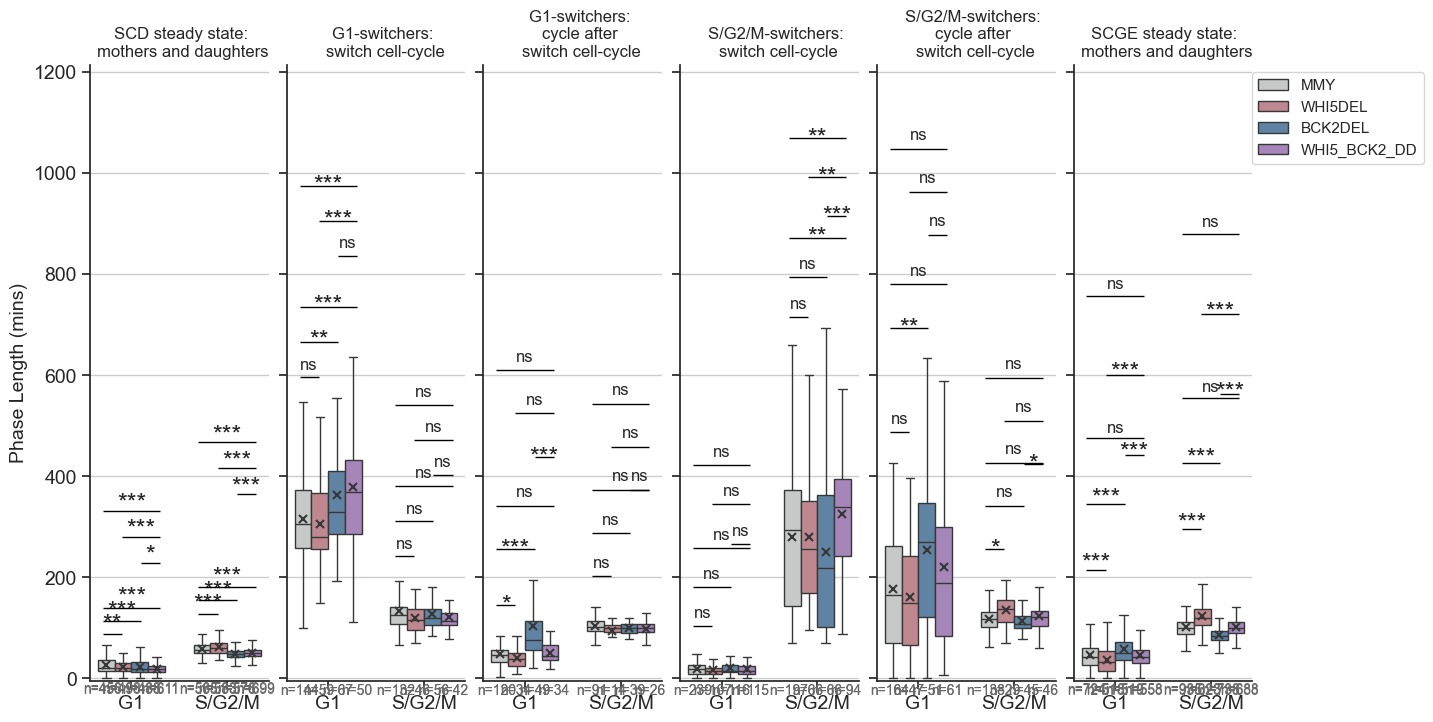

In [30]:

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
import importlib
import core
importlib.reload(core)

sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})
x_labels = ['G1', 'S']

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4, ax5, ax6)) = plt.subplots(nrows=1, ncols=6, sharex= False, sharey= True, figsize=(15, 8) )
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="time_in_stage_mins", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

core.run_stats(
      plotting_df = unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      title="unique_steady_state_plotting_df, growthmedium == SCD",
      value_cols = ['time_in_stage_mins'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax1, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      x_col='cell_cycle_stage', y_col='time_in_stage_mins', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2, bracket_step=0.25)

core.annotate_significance_hue_vs_ref(
      ax=ax1, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      x_col='cell_cycle_stage', y_col='time_in_stage_mins', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.8, bracket_step=0.25
)

ax1.set_title("SCD steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Phase Length (mins)", fontsize = 14)
S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="time_in_stage_mins",
                hue = "strain",
                ax = ax6,
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax6.set_title("SCGE steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax6.set_ylabel("")

core.run_stats(
      plotting_df = unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      title="unique_steady_state_plotting_df, growthmedium == SCGE",
      value_cols = ['time_in_stage_mins'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax6, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      x_col='cell_cycle_stage', y_col='time_in_stage_mins', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2, bracket_step=0.25)

core.annotate_significance_hue_vs_ref(
      ax=ax6, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      x_col='cell_cycle_stage', y_col='time_in_stage_mins', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.5, bracket_step=0.25
)

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("G1-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax2.set_ylabel("")

core.run_stats(
      plotting_df = unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      title="unique_phase_first_frame_df, cell_saw_switch_in_G1 == True",
      value_cols = ['phase_length_mins'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax2, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax2, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax4,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax4, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax4.set_title("S/G2/M-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax4.set_ylabel("")

core.run_stats(
      plotting_df = unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      title="unique_phase_first_frame_df, cell_saw_switch_in_G1 == False",
      value_cols = ['phase_length_mins'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax4, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax4, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]), 
#                         x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
core.run_stats(
      plotting_df = unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      title="unique_phase_first_frame_df_2, cell_saw_switch_in_G1 == True",
      value_cols = ['phase_length_mins'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax3, df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax3, df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)

ax3.set_title("G1-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax3.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                y="phase_length_mins",
                ax = ax5,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

core.annotate_significance_hue_vs_ref(
      ax=ax5, df=unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False)],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax5, df=unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False)],
      x_col='cell_cycle_stage', y_col='phase_length_mins', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)

core.run_stats(
      plotting_df = unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False],
      title="unique_phase_first_frame_df_2, cell_saw_switch_in_G1 == False",
      value_cols = ['phase_length_mins'], group_col=['strain', 'cell_cycle_stage']
)

# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]), 
#                         x= "cell_cycle_stage", y="phase_length_mins", ax = ax5, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax5.set_title("S/G2/M-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax5.set_ylabel("")

#display(unique_phase_first_frame_df[(unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False) 
                                   # & (unique_phase_first_frame_df['strain'] == "WHI5DEL")
                                   # & (unique_phase_first_frame_df['phase_length_mins'] <400)].drop(columns = ['directory']))


ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend([],[], frameon=False)
ax5.legend([],[], frameon=False)
ax6.legend(loc='upper right', bbox_to_anchor=(2, 1))

xtix = ['G1', 'S/G2/M']
ax1.set_xticklabels(xtix, fontsize = 14)
ax2.set_xticklabels(xtix, fontsize = 14)
ax3.set_xticklabels(xtix, fontsize = 14)
ax4.set_xticklabels(xtix, fontsize = 14)
ax5.set_xticklabels(xtix, fontsize = 14)
ax6.set_xticklabels(xtix, fontsize = 14)

ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig3\Panel2_switchers_G1_analysis.svg")
plt.show()

# ***Fig 4C: Switchers only - vol at G1 end - selected strains*** 

In [48]:
############################### steady state use old dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              #& (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                             ]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of both cell-cycle stages for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]


############################### nutrient switch switch cycle plotting df prep ############################################################################
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

complete_switch_cycles = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            #& (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase = []
for fposid in ((complete_switch_cycles['f_pos_cell_id']).unique()):
    fposid_df = complete_switch_cycles[complete_switch_cycles['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase.append(phase_df.iloc[:1])
unique_phase_first_frame_df = pd.concat(unique_f_pos_cell_id_phase).reset_index(drop = True)

unique_phase_first_frame_df['phase_length_mins'] = unique_phase_first_frame_df['phase_length']*3
display(unique_phase_first_frame_df['f_pos_cell_id'].loc[unique_phase_first_frame_df['phase_length_mins'] > 1250])

############################### nutrient switch cycle after switch cycle plotting df prep ############################################################################


complete_cycle_after_switch_cycle = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cell_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1) |
                                                               (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0")) 
                                                            #& (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]

# getting only the first frame of both cell-cycle stages for every cell
unique_f_pos_cell_id_phase_2 = []
for fposid in ((complete_cycle_after_switch_cycle['f_pos_cell_id']).unique()):
    fposid_df = complete_cycle_after_switch_cycle[complete_cycle_after_switch_cycle['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id_phase_2.append(phase_df.iloc[:1])
unique_phase_first_frame_df_2 = pd.concat(unique_f_pos_cell_id_phase_2).reset_index(drop = True)

unique_phase_first_frame_df_2['phase_length_mins'] = unique_phase_first_frame_df_2['phase_length']*3




Series([], Name: f_pos_cell_id, dtype: object)


unique_steady_state_plotting_df, growthmedium == SCD
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'sys_vol_at_frame_inc_G1_cells'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5DEL, S)",583,88.8,82.5,2.40,50,Shapiro-Wilk,0.0,False
1,"(WHI5DEL, G1)",498,52.3,48.2,2.56,27,Shapiro-Wilk,0.0,False
2,"(WHI5_BCK2_DD, S)",699,116.7,113.0,1.21,28,Shapiro-Wilk,0.0,False
3,"(BCK2DEL, G1)",488,95.3,90.9,1.79,21,Shapiro-Wilk,0.0,False
4,"(MMY, G1)",456,69.6,67.1,1.39,17,Shapiro-Wilk,0.0,False
5,"(BCK2DEL, S)",576,150.7,147.6,2.63,22,Shapiro-Wilk,0.0,False
6,"(WHI5_BCK2_DD, G1)",611,70.4,67.9,1.36,22,Shapiro-Wilk,0.0,False
7,"(MMY, S)",565,113.3,108.8,1.15,20,Shapiro-Wilk,0.0,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('MMY', 'S')",456,565,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",456,488,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', 'G1') vs ('BCK2DEL', 'S')",456,576,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",456,498,0.0000,0.0000,0.0000,True,True,True,False
4,"('MMY', 'G1') vs ('WHI5DEL', 'S')",456,583,0.0000,0.0000,0.0000,True,True,True,False
5,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",456,611,0.4518,0.4588,0.8031,False,False,False,False
6,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'S')",456,699,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY', 'S') vs ('BCK2DEL', 'G1')",565,488,0.0000,0.0000,0.0000,True,True,True,False
8,"('MMY', 'S') vs ('BCK2DEL', 'S')",565,576,0.0000,0.0000,0.0000,True,True,True,False
9,"('MMY', 'S') vs ('WHI5DEL', 'G1')",565,498,0.0000,0.0000,0.0000,True,True,True,False



unique_steady_state_plotting_df, growthmedium == SCGE
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'sys_vol_at_frame_inc_G1_cells'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5DEL, S)",623,79.0,73.9,1.70,34,Shapiro-Wilk,0.0,False
1,"(WHI5DEL, G1)",518,47.9,43.7,2.14,28,Shapiro-Wilk,0.0,False
2,"(WHI5_BCK2_DD, S)",688,102.0,92.4,2.62,34,Shapiro-Wilk,0.0,False
3,"(BCK2DEL, G1)",519,99.4,91.9,2.36,19,Shapiro-Wilk,0.0,False
4,"(MMY, G1)",724,56.5,53.0,2.68,23,Shapiro-Wilk,0.0,False
5,"(BCK2DEL, S)",738,148.8,136.4,2.59,40,Shapiro-Wilk,0.0,False
6,"(WHI5_BCK2_DD, G1)",558,64.7,58.3,2.90,29,Shapiro-Wilk,0.0,False
7,"(MMY, S)",935,90.0,86.3,2.46,42,Shapiro-Wilk,0.0,False


...

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('MMY', 'S')",120,91,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",120,49,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', 'G1') vs ('BCK2DEL', 'S')",120,39,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",120,34,0.0018,0.0022,0.0007,True,True,True,False
4,"('MMY', 'G1') vs ('WHI5DEL', 'S')",120,14,0.0029,0.0001,0.0005,True,True,True,False
5,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",120,34,0.0002,0.0000,0.0000,True,True,True,False
6,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'S')",120,26,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY', 'S') vs ('BCK2DEL', 'G1')",91,49,0.0097,0.0008,0.0044,True,True,True,False
8,"('MMY', 'S') vs ('BCK2DEL', 'S')",91,39,0.0003,0.0000,0.0000,True,True,True,False
9,"('MMY', 'S') vs ('WHI5DEL', 'G1')",91,34,0.0000,0.0000,0.0000,True,True,True,False



unique_phase_first_frame_df_2, cell_saw_switch_in_G1 == False
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'phase_combined_volume_at_end'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5DEL, S)",29,153.7,136.5,1.24,2,Shapiro-Wilk,3.729380e-03,False
1,"(WHI5DEL, G1)",47,101.3,90.6,1.18,2,Shapiro-Wilk,3.670665e-04,False
2,"(WHI5_BCK2_DD, S)",46,255.8,218.0,1.23,7,Shapiro-Wilk,1.335190e-05,False
3,"(BCK2DEL, G1)",51,227.7,213.5,1.36,3,Shapiro-Wilk,2.221017e-04,False
4,"(MMY, G1)",164,121.3,112.0,1.18,7,Shapiro-Wilk,9.160000e-08,False
5,"(BCK2DEL, S)",45,306.9,290.6,1.12,2,Shapiro-Wilk,7.149385e-03,False
6,"(WHI5_BCK2_DD, G1)",61,165.4,148.1,1.75,6,Shapiro-Wilk,3.250000e-07,False
7,"(MMY, S)",138,174.0,159.5,1.28,6,Shapiro-Wilk,2.830000e-08,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('MMY', 'S')",164,138,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",164,51,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', 'G1') vs ('BCK2DEL', 'S')",164,45,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",164,47,0.0003,0.0004,0.0000,True,True,True,False
4,"('MMY', 'G1') vs ('WHI5DEL', 'S')",164,29,0.0018,0.0000,0.0002,True,True,True,False
5,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",164,61,0.0000,0.0000,0.0000,True,True,True,False
6,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'S')",164,46,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY', 'S') vs ('BCK2DEL', 'G1')",138,51,0.0000,0.0000,0.0000,True,True,True,False
8,"('MMY', 'S') vs ('BCK2DEL', 'S')",138,45,0.0000,0.0000,0.0000,True,True,True,False
9,"('MMY', 'S') vs ('WHI5DEL', 'G1')",138,47,0.0000,0.0000,0.0000,True,True,True,False


C:\Users\timon\AppData\Local\Temp\ipykernel_43332\2752033271.py:269: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\2752033271.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\2752033271.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\2752033271.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(xtix, fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipyker

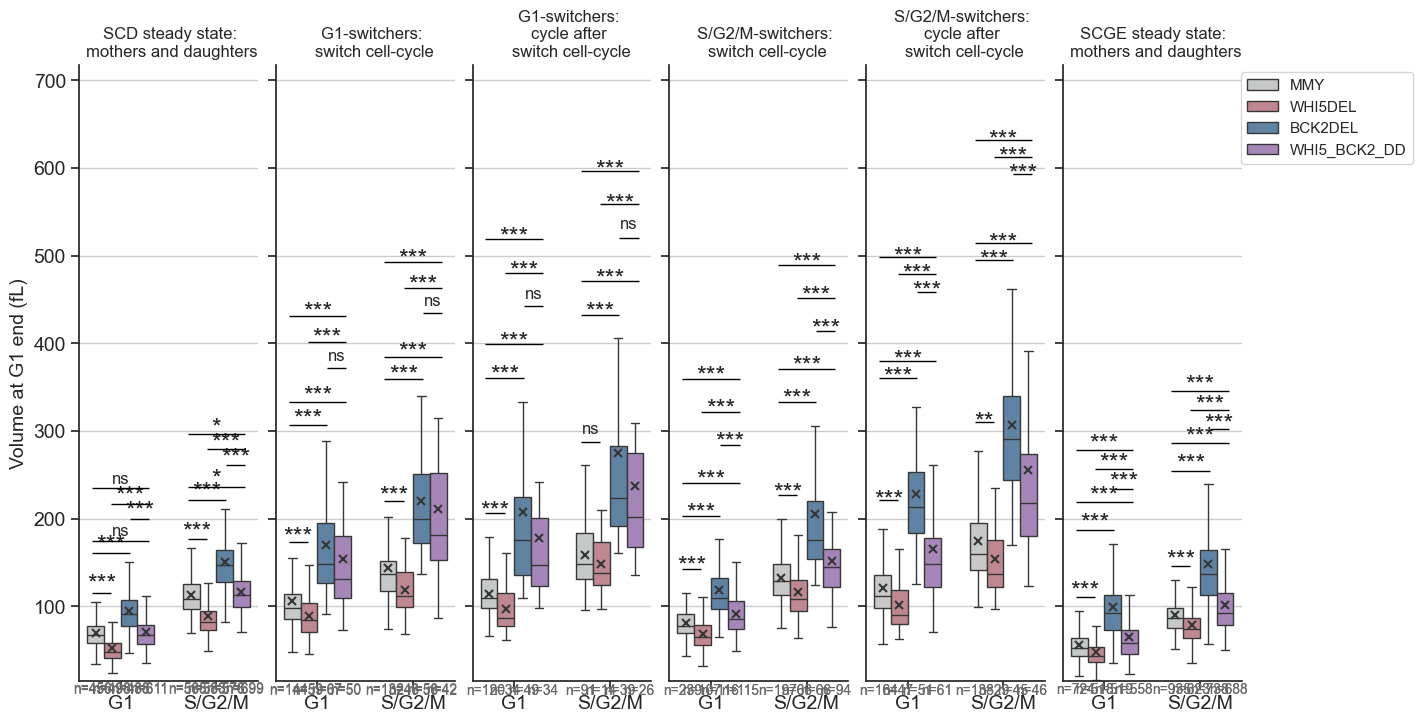

In [56]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4, ax5, ax6)) = plt.subplots(nrows=1, ncols=6, sharex= False, sharey= True, figsize=(15, 8) )

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                order = ['G1', 'S'],
                y="sys_vol_at_frame_inc_G1_cells", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Volume at G1 end (fL)", fontsize = 14)
core.run_stats(
      plotting_df = unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      title="unique_steady_state_plotting_df, growthmedium == SCD",
      value_cols = ['sys_vol_at_frame_inc_G1_cells'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax1, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      x_col='cell_cycle_stage', y_col='sys_vol_at_frame_inc_G1_cells', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels)

core.annotate_significance_hue_vs_ref(
      ax=ax1, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      x_col='cell_cycle_stage', y_col='sys_vol_at_frame_inc_G1_cells', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                # order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="sys_vol_at_frame_inc_G1_cells",
                hue = "strain",
                ax = ax6,
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax6.set_title("SCGE steady state: \nmothers and daughters", fontsize = 12, x=0.52)
ax6.set_ylabel("")

core.run_stats(
      plotting_df = unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      title="unique_steady_state_plotting_df, growthmedium == SCGE",
      value_cols = ['sys_vol_at_frame_inc_G1_cells'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax6, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      x_col='cell_cycle_stage', y_col='sys_vol_at_frame_inc_G1_cells', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, bracket_step=0.1)

core.annotate_significance_hue_vs_ref(
      ax=ax6, df=unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      x_col='cell_cycle_stage', y_col='sys_vol_at_frame_inc_G1_cells', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2, bracket_step=0.07
)

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax2, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("G1-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax2.set_ylabel("")

core.run_stats(
      plotting_df = unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      title="unique_phase_first_frame_df, cell_saw_switch_in_G1 == True",
      value_cols = ['phase_combined_volume_at_end'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax2, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax2, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)

S = sns.boxplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax4,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax4, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax4.set_title("S/G2/M-switchers: \nswitch cell-cycle", fontsize = 12, x=0.55)
ax4.set_ylabel("")
core.run_stats(
      plotting_df = unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      title="unique_phase_first_frame_df, cell_saw_switch_in_G1 == False",
      value_cols = ['phase_combined_volume_at_end'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax4, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax4, df=unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
) 

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
core.run_stats(
      plotting_df = unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      title="unique_phase_first_frame_df_2, cell_saw_switch_in_G1 == True",
      value_cols = ['phase_combined_volume_at_end'], group_col=['strain', 'cell_cycle_stage']
)

core.annotate_significance_hue_vs_ref(
      ax=ax3, df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels
)
core.annotate_significance_hue_vs_ref(
      ax=ax3, df=unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == True],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2
)
ax3.set_title("G1-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax3.set_ylabel("")

S = sns.boxplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]),
                showmeans = True,
                x= "cell_cycle_stage",
                order = ['G1', 'S'],
                y="phase_combined_volume_at_end",
                ax = ax5,
                hue = "strain",
                showfliers = False,
                width = 0.7,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_volume_at_end", ax = ax5, hue = "strain", color = "black", 
#                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
#                        dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax5.set_title("S/G2/M-switchers: \ncycle after \nswitch cell-cycle", fontsize = 12, x=0.55)
ax5.set_ylabel("")

core.annotate_significance_hue_vs_ref(
      ax=ax5, df=unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False)],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='MMY', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, bracket_step=0.03
)
core.annotate_significance_hue_vs_ref(
      ax=ax5, df=unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False)],
      x_col='cell_cycle_stage', y_col='phase_combined_volume_at_end', hue_col='strain',
      ref_hue='WHI5_BCK2_DD', test='mwu', hue_order=["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
      x_order=x_labels, y_gap=0.2, bracket_step=0.03
)

core.run_stats(
      plotting_df = unique_phase_first_frame_df_2[unique_phase_first_frame_df_2['cell_saw_switch_in_G1'] == False],
      title="unique_phase_first_frame_df_2, cell_saw_switch_in_G1 == False",
      value_cols = ['phase_combined_volume_at_end'], group_col=['strain', 'cell_cycle_stage'],
)

#display(unique_phase_first_frame_df[(unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False) 
                                   # & (unique_phase_first_frame_df['strain'] == "WHI5DEL")
                                   # & (unique_phase_first_frame_df['phase_length_mins'] <400)].drop(columns = ['directory']))

ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend([],[], frameon=False)
ax5.legend([],[], frameon=False)
ax6.legend(loc='upper right', bbox_to_anchor=(2, 1))

xtix = ['G1', 'S/G2/M']
ax1.set_xticklabels(xtix, fontsize = 14)
ax2.set_xticklabels(xtix, fontsize = 14)
ax3.set_xticklabels(xtix, fontsize = 14)
ax4.set_xticklabels(xtix, fontsize = 14)
ax5.set_xticklabels(xtix, fontsize = 14)
ax6.set_xticklabels(xtix, fontsize = 14)
#ax1.set_ylim(0,450)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)


ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig3\Panel3_switchers_volatG1andSend.svg")
plt.show()

# ***Fig 4C: Statistics - switch-cell-cycle*** 

In [32]:
from scipy import stats as scipystats
print("G1-switchers switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("G1-switchers switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "MMY") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "BCK2DEL") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df[(unique_phase_first_frame_df["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))



G1-switchers switch cell-cycle G1 stats:
WT n 144
Bck2del n 67
whi5del n 59
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=np.float64(3.307791622909012), pvalue=np.float64(0.001135343824312691), df=np.float64(180.1067821741331))
WT VS BCK2 TtestResult(statistic=np.float64(-7.047490719396623), pvalue=np.float64(3.200713938036026e-10), df=np.float64(92.484951808598))
WT VS DD TtestResult(statistic=np.float64(-4.66989453887733), pvalue=np.float64(1.5945922309897005e-05), df=np.float64(63.92187740436918))
DD VS BCK2 TtestResult(statistic=np.float64(-1.274801335674503), pvalue=np.float64(0.2051663597493428), df=np.float64(106.01955115905871))
DD VS WHI5 TtestResult(statistic=np.float64(6.336789008070276), pvalue=np.float64(3.269241843063593e-08), df=np.float64(60.373522445901784))
G1-switchers switch cell-cycle S/G2/M stats:
WT n 132
Bck2del n 56
whi5del n 46
whi5bck2dd n 42
WT VS WHI5 TtestResult(statistic=np.float64(4.1888607598268965), pvalue=np.float64(5.2658925002798604e-05), df=np.f

# ***Fig 4C: Statistics - cycle after switch-cell-cycle*** 

In [33]:
print("G1-switchers cycle after switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("G1-switchers cycle after switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)  
                                    & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == True)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers cycle after switch cell-cycle G1 stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))

print("S-switchers cycle after switch cell-cycle S/G2/M stats:")
WT_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "MMY") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                   & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5del_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                         & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
bck2del_df = unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "BCK2DEL") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False) 
                                        & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_phase_first_frame_df_2[(unique_phase_first_frame_df_2["strain"] == "WHI5_BCK2_DD") & (unique_phase_first_frame_df_2["cell_saw_switch_in_G1"] == False)
                                            & (unique_phase_first_frame_df_2["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_combined_volume_at_end"]), (whi5bck2dd_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (bck2del_df["phase_combined_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_combined_volume_at_end"]), (whi5del_df["phase_combined_volume_at_end"]), equal_var = False))


G1-switchers cycle after switch cell-cycle G1 stats:
WT n 120
Bck2del n 49
whi5del n 34
whi5bck2dd n 34
WT VS WHI5 TtestResult(statistic=np.float64(3.275150103752382), pvalue=np.float64(0.0017934073030164335), df=np.float64(57.393838109463246))
WT VS BCK2 TtestResult(statistic=np.float64(-5.164471710184172), pvalue=np.float64(4.160453616670941e-06), df=np.float64(50.23034653765064))
WT VS DD TtestResult(statistic=np.float64(-4.097037337275781), pvalue=np.float64(0.00023411884096565005), df=np.float64(35.161354848970305))
DD VS BCK2 TtestResult(statistic=np.float64(-1.3059861902624006), pvalue=np.float64(0.1952551830357971), df=np.float64(80.97433405802278))
DD VS WHI5 TtestResult(statistic=np.float64(5.095840854415213), pvalue=np.float64(9.122606776042724e-06), df=np.float64(39.233640107029785))
G1-switchers cycle after switch cell-cycle S/G2/M stats:
WT n 91
Bck2del n 39
whi5del n 14
whi5bck2dd n 26
WT VS WHI5 TtestResult(statistic=np.float64(0.9913212005895106), pvalue=np.float64(0.3

# ***Fig 4C: Statistics - steady-state cells*** 

In [34]:
print("SCD steady state volume at G1 end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCD steady state volume at S/G2/M end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCGE steady state volume at G1 end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "G1")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

print("SCGE steady state volume at S/G2/M end stats:")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                       & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                             & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                            & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")
                                                & (unique_steady_state_plotting_df["cell_cycle_stage"] == "S")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["sys_vol_at_frame_inc_G1_cells"]), (whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (bck2del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["sys_vol_at_frame_inc_G1_cells"]), (whi5del_df["sys_vol_at_frame_inc_G1_cells"]), equal_var = False))

SCD steady state volume at G1 end stats:
WT n 456
Bck2del n 488
whi5del n 498
whi5bck2dd n 611
WT VS WHI5 TtestResult(statistic=np.float64(14.850995245601297), pvalue=np.float64(5.097504070074375e-45), df=np.float64(949.8245552716488))
WT VS BCK2 TtestResult(statistic=np.float64(-16.937024073980464), pvalue=np.float64(1.978077658046818e-55), df=np.float64(822.8743903298803))
WT VS DD TtestResult(statistic=np.float64(-0.7527061154807382), pvalue=np.float64(0.4517986153522737), df=np.float64(1029.4568983629763))
DD VS BCK2 TtestResult(statistic=np.float64(-16.55142388027462), pvalue=np.float64(2.004427338157608e-53), df=np.float64(834.3093568838642))
DD VS WHI5 TtestResult(statistic=np.float64(15.887891238559439), pvalue=np.float64(2.8660975627555934e-51), df=np.float64(1086.488342000647))
SCD steady state volume at S/G2/M end stats:
WT n 565
Bck2del n 576
whi5del n 583
whi5bck2dd n 699
WT VS WHI5 TtestResult(statistic=np.float64(16.81774919717342), pvalue=np.float64(8.990034520001067e-5

# ***Fig 5B: Daughters of switchers - G1 lengths - selected strains*** 

In [57]:
############################### steady state dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                              & (SS_SCDnSCGE['Daughterhood_binary'] == 1)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of G1 for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]

palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3

############################### nutrient switch G1 daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_G1daughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_G1daughters = []
for fposid in ((post_switch_G1daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_G1daughters_complete_G1_df[post_switch_G1daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_G1daughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_G1daughters = pd.concat(unique_f_pos_cell_id_G1daughters).reset_index(drop = True)
unique_first_G1_frame_df_G1daughters['phase_length_mins'] = unique_first_G1_frame_df_G1daughters['phase_length']*3






SCD steady state: daughters
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'time_in_stage_mins'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, G1)",282,25.3,24.0,0.37,1,Shapiro-Wilk,4.007577e-04,False
1,"(BCK2DEL, G1)",214,34.4,33.0,0.50,4,Shapiro-Wilk,2.161039e-03,False
2,"(MMY, G1)",198,39.9,36.0,0.88,7,Shapiro-Wilk,1.477400e-06,False
3,"(WHI5DEL, G1)",232,28.7,27.0,1.22,3,Shapiro-Wilk,2.500000e-09,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",198,214,0.0007,0.0006,0.0041,True,True,True,False
1,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",198,232,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",198,282,0.0000,0.0000,0.0000,True,True,True,False
3,"('BCK2DEL', 'G1') vs ('WHI5DEL', 'G1')",214,232,0.0000,0.0000,0.0000,True,True,True,False
4,"('BCK2DEL', 'G1') vs ('WHI5_BCK2_DD', 'G1')",214,282,0.0000,0.0000,0.0000,True,True,True,False
5,"('WHI5DEL', 'G1') vs ('WHI5_BCK2_DD', 'G1')",232,282,0.0016,0.0013,0.0035,True,True,True,False



SCGE steady state: daughters
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'time_in_stage_mins'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, G1)",264,57.7,54.0,1.18,10,Shapiro-Wilk,9.000000e-10,False
1,"(BCK2DEL, G1)",240,77.4,69.0,1.79,10,Shapiro-Wilk,0.000000e+00,False
2,"(MMY, G1)",330,63.9,57.0,1.28,11,Shapiro-Wilk,0.000000e+00,False
3,"(WHI5DEL, G1)",244,51.3,51.0,0.91,8,Shapiro-Wilk,3.104000e-07,False


...

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


,S_switch_cells_daughter_wave,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5DEL, 3.0)",11,55.9,45.0,0.99,0,Shapiro-Wilk,0.017247,False
1,"(BCK2DEL, 1.0)",34,423.0,391.5,0.65,1,Shapiro-Wilk,0.121582,True
2,"(MMY, 1.0)",123,263.7,252.0,1.11,4,Shapiro-Wilk,0.000028,False
3,"(BCK2DEL, 4.0)",5,70.8,78.0,-1.33,1,Shapiro-Wilk,0.018439,False
4,"(MMY, 4.0)",6,55.0,45.0,0.49,0,Shapiro-Wilk,0.162204,True
5,"(WHI5_BCK2_DD, 2.0)",40,55.8,51.0,1.09,1,Shapiro-Wilk,0.010549,False
6,"(WHI5DEL, 2.0)",20,67.5,66.0,1.32,1,Shapiro-Wilk,0.028806,False
7,"(BCK2DEL, 3.0)",20,65.0,58.5,1.63,1,Shapiro-Wilk,0.002853,False
8,"(MMY, 3.0)",31,57.6,48.0,2.73,1,Shapiro-Wilk,0.000003,False
9,"(WHI5_BCK2_DD, 4.0)",8,51.0,51.0,0.07,0,Shapiro-Wilk,0.142904,True


    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('MMY', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('BCK2DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('WHI5DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('WHI5_BCK2_DD', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('MMY', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('BCK2DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('WHI5DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('WHI5_BCK2_DD', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(3.0))' vs '('MMY', np.fl

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(2.0))",123,104,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(3.0))",123,31,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(4.0))",123,6,0.0000,0.0002,0.0001,True,True,True,False
3,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(1.0))",123,34,0.0014,0.0000,0.0004,True,True,True,False
4,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(2.0))",123,39,0.0000,0.0000,0.0000,True,True,True,False
5,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(3.0))",123,20,0.0000,0.0000,0.0000,True,True,True,False
6,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(4.0))",123,5,0.0000,0.0014,0.0005,True,True,True,False
7,"('MMY', np.float64(1.0)) vs ('WHI5DEL', np.float64(1.0))",123,40,0.5426,0.4961,0.2810,False,False,False,False
8,"('MMY', np.float64(1.0)) vs ('WHI5DEL', np.float64(2.0))",123,20,0.0000,0.0000,0.0000,True,True,True,False
9,"('MMY', np.float64(1.0)) vs ('WHI5DEL', np.float64(3.0))",123,11,0.0000,0.0000,0.0000,True,True,True,False


C:\Users\timon\AppData\Local\Temp\ipykernel_43332\1935381143.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\1935381143.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\1935381143.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\1935381143.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

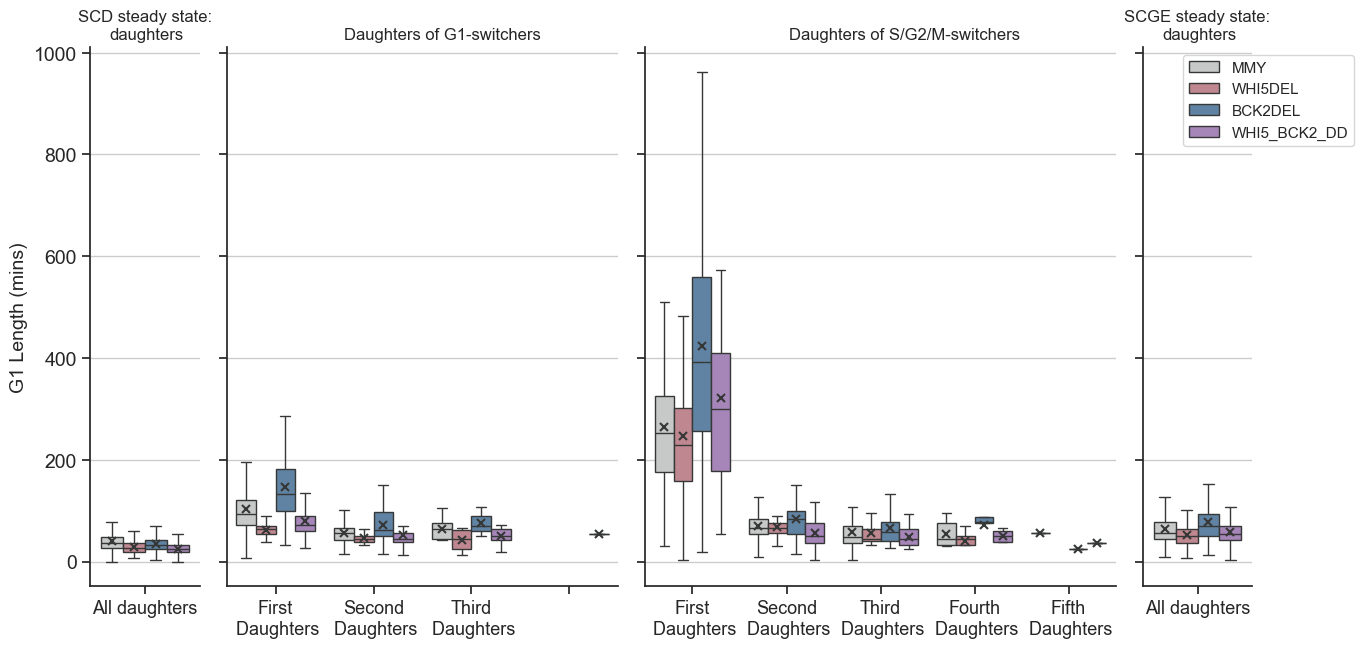

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


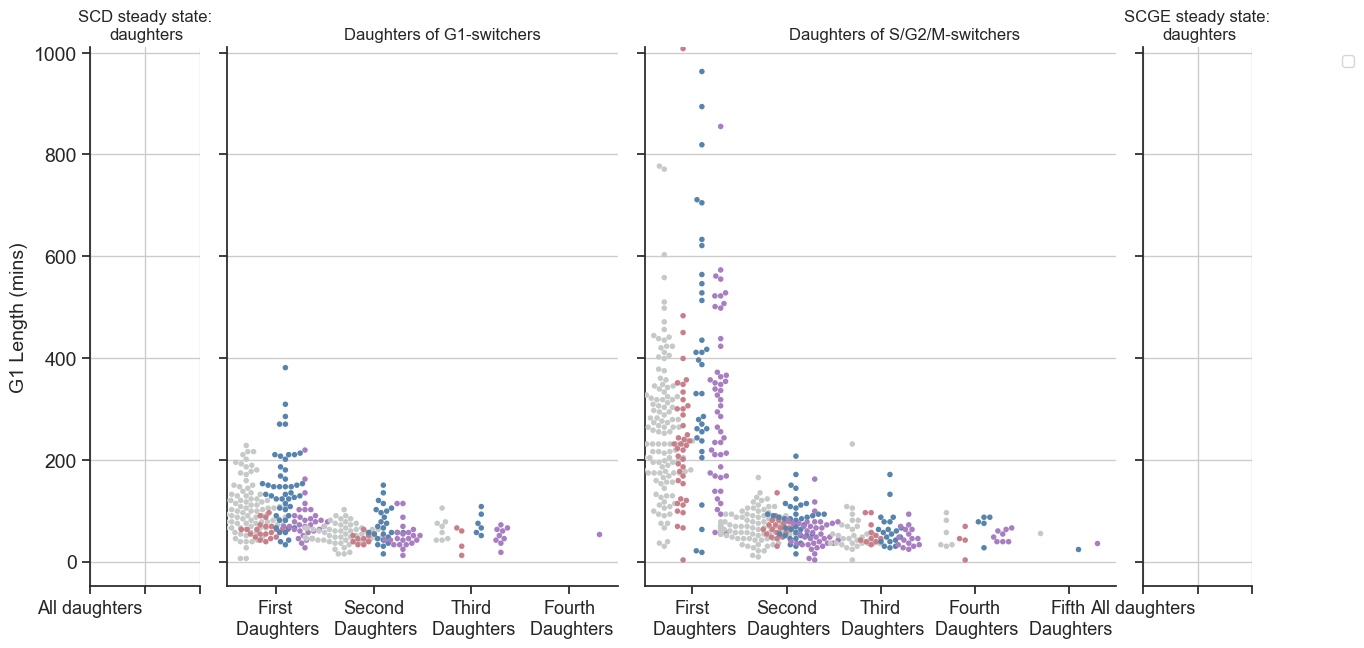

In [59]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
A, ((ax5, ax6, ax7, ax8)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="time_in_stage_mins", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax5.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax5.set_ylabel("G1 Length (mins)", fontsize = 14)

core.run_stats(
      unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      "time_in_stage_mins", group_col=["strain", "cell_cycle_stage"],
      title = "SCD steady state: daughters"
)

S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                #order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="time_in_stage_mins",
                hue = "strain",
                ax = ax4,
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax4.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax4.set_ylabel("")
ax8.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax8.set_ylabel("")

core.run_stats(
      unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      "time_in_stage_mins", group_col=["strain", "cell_cycle_stage"],
      title = "SCGE steady state: daughters"
)
S = sns.boxplot(data=unique_first_G1_frame_df_G1daughters,
                showmeans = True,
                x= "G1_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_G1daughters, 
                       x= "G1_switch_cells_daughter_wave", y="phase_length_mins", ax = ax6, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax2.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("")
ax6.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax6.set_ylabel("")

core.run_stats(
      unique_first_G1_frame_df_G1daughters,
      "phase_length_mins", group_col=["strain", "G1_switch_cells_daughter_wave"],
      title = "Daughters of G1-switchers"
)

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
                       x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax7, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("") 
ax7.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax7.set_ylabel("") 
core.run_stats(
      unique_first_G1_frame_df_Sdaughters,
      "phase_length_mins", group_col=["strain", "S_switch_cells_daughter_wave"],
      title = "Daughters of S/G2/M-switchers"
)


ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
ax5.legend([],[], frameon=False)
ax6.legend([],[], frameon=False)
ax7.legend([],[], frameon=False)
ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))

# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax1.set_xticklabels(['All daughters'], fontsize = 13)
ax4.set_xticklabels(['All daughters'], fontsize = 13)

ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax5.set_xticklabels(['All daughters'], fontsize = 13)
ax8.set_xticklabels(['All daughters'], fontsize = 13)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
ax7.set_xlabel("")
ax8.set_xlabel("")

S.figure.subplots_adjust(wspace = 0.1)
A.figure.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)
sns.despine(ax = ax7)
sns.despine(ax = ax8)

ax5.set_ylim(ax1.get_ylim())


# S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length.svg")
# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length_swarm.svg")
plt.show()

# ***Fig 5B: statistics - selected strains*** 

In [ ]:
from scipy import stats as scipystats
print("S-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "MMY") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_length_mins"]), (whi5del_df["phase_length_mins"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_length_mins"]), (bck2del_df["phase_length_mins"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_length_mins"]), (whi5bck2dd_df["phase_length_mins"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_length_mins"]), (bck2del_df["phase_length_mins"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_length_mins"]), (whi5del_df["phase_length_mins"]), equal_var = False))



S-switchers first daughters stats:
WT n 123
Bck2del n 34
whi5del n 40
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=np.float64(0.6126119958151159), pvalue=np.float64(0.542589387330759), df=np.float64(56.534317931051866))
WT VS BCK2 TtestResult(statistic=np.float64(-3.4539905469509224), pvalue=np.float64(0.0013779423752692654), df=np.float64(37.79023744176679))
WT VS DD TtestResult(statistic=np.float64(-1.9079396342152497), pvalue=np.float64(0.060676494315341306), df=np.float64(67.14208691536041))
DD VS BCK2 TtestResult(statistic=np.float64(-1.9180102379621669), pvalue=np.float64(0.06001374900553122), df=np.float64(58.27916529695645))
DD VS WHI5 TtestResult(statistic=np.float64(1.9832269849571966), pvalue=np.float64(0.05046201980275104), df=np.float64(87.94474407517448))


# ***Fig 5C: Daughters of switchers - Vol at G1 end - selected strains*** 

In [60]:
############################### steady state dataprep ############################################################################
steady_state_df = SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == True) 
                              & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                              & (SS_SCDnSCGE['Daughterhood_binary'] == 1)]

steady_state_plotting_df = steady_state_df[["f_pos_cell_id","time_in_stage_mins", "growthmedium", "strain", "Daughterhood_binary",
                                            "complete_phase", "sys_vol_at_frame_inc_G1_cells", "Birth_or_div_vol_fl", "frame_i", "lenG1_mins", "cell_cycle_stage"]]

# getting only the last frame of G1 for every cell
unique_f_pos_cell_id = []
for fposid in ((steady_state_plotting_df['f_pos_cell_id']).unique()):
    fposid_df = steady_state_plotting_df[steady_state_plotting_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    for phase in (fposid_df['cell_cycle_stage'].unique()):
        phase_df = fposid_df[fposid_df['cell_cycle_stage'] == phase]
        unique_f_pos_cell_id.append(phase_df.iloc[-1:])
unique_steady_state_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)

unique_steady_state_plotting_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df['strain'] == "MMY")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "BCK2DEL")|
                                                                    (unique_steady_state_plotting_df['strain'] == "WHI5_BCK2_DD")
                                                                 ]



############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3

############################### nutrient switch G1 daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]

post_switch_G1daughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_G1daughters = []
for fposid in ((post_switch_G1daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_G1daughters_complete_G1_df[post_switch_G1daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_G1daughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_G1daughters = pd.concat(unique_f_pos_cell_id_G1daughters).reset_index(drop = True)
unique_first_G1_frame_df_G1daughters['phase_length_mins'] = unique_first_G1_frame_df_G1daughters['phase_length']*3


SCD steady state: daughters
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'sys_vol_at_frame_inc_G1_cells'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, G1)",282,58.8,56.9,0.95,4,Shapiro-Wilk,1.224000e-07,False
1,"(BCK2DEL, G1)",214,80.5,78.5,3.13,6,Shapiro-Wilk,0.000000e+00,False
2,"(MMY, G1)",198,60.4,58.3,1.74,5,Shapiro-Wilk,2.000000e-10,False
3,"(WHI5DEL, G1)",232,43.0,42.1,1.77,8,Shapiro-Wilk,0.000000e+00,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', 'G1') vs ('BCK2DEL', 'G1')",198,214,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', 'G1') vs ('WHI5DEL', 'G1')",198,232,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', 'G1') vs ('WHI5_BCK2_DD', 'G1')",198,282,0.1749,0.1642,0.2097,False,False,False,False
3,"('BCK2DEL', 'G1') vs ('WHI5DEL', 'G1')",214,232,0.0000,0.0000,0.0000,True,True,True,False
4,"('BCK2DEL', 'G1') vs ('WHI5_BCK2_DD', 'G1')",214,282,0.0000,0.0000,0.0000,True,True,True,False
5,"('WHI5DEL', 'G1') vs ('WHI5_BCK2_DD', 'G1')",232,282,0.0000,0.0000,0.0000,True,True,True,False



SCGE steady state: daughters
Group: '['strain', 'cell_cycle_stage']'  |  Value: 'sys_vol_at_frame_inc_G1_cells'


,cell_cycle_stage,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5_BCK2_DD, G1)",264,50.7,48.2,1.06,5,Shapiro-Wilk,1.370000e-08,False
1,"(BCK2DEL, G1)",240,78.2,74.4,0.85,6,Shapiro-Wilk,4.227200e-06,False
2,"(MMY, G1)",330,46.2,44.3,1.23,8,Shapiro-Wilk,1.000000e-10,False
3,"(WHI5DEL, G1)",244,37.7,37.4,0.25,1,Shapiro-Wilk,3.068820e-01,True


...


Daughters of S/G2/M-switchers
Group: '['strain', 'S_switch_cells_daughter_wave']'  |  Value: 'phase_volume_at_end'
    Not enough data points (1) for group '('WHI5_BCK2_DD', np.float64(5.0))', skipping.
    Not enough data points (0) for group '('WHI5DEL', np.float64(5.0))', skipping.
    Not enough data points (1) for group '('BCK2DEL', np.float64(5.0))', skipping.
    Not enough data points (1) for group '('MMY', np.float64(5.0))', skipping.


,S_switch_cells_daughter_wave,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(WHI5DEL, 3.0)",11,51.3,50.8,0.91,1,Shapiro-Wilk,3.717995e-01,True
1,"(BCK2DEL, 1.0)",34,215.7,177.6,2.55,3,Shapiro-Wilk,3.196600e-06,False
2,"(MMY, 1.0)",123,83.2,74.8,1.85,6,Shapiro-Wilk,2.100000e-09,False
3,"(BCK2DEL, 4.0)",5,111.0,121.2,-0.99,1,Shapiro-Wilk,2.561597e-01,True
4,"(MMY, 4.0)",6,63.9,64.8,-0.05,0,Shapiro-Wilk,8.630829e-01,True
5,"(WHI5_BCK2_DD, 2.0)",40,96.9,82.8,1.57,4,Shapiro-Wilk,4.663930e-05,False
6,"(WHI5DEL, 2.0)",20,55.0,49.9,1.62,2,Shapiro-Wilk,2.342099e-03,False
7,"(BCK2DEL, 3.0)",20,93.6,90.4,0.58,0,Shapiro-Wilk,1.540866e-01,True
8,"(MMY, 3.0)",31,59.3,56.9,0.59,0,Shapiro-Wilk,3.655930e-01,True
9,"(WHI5_BCK2_DD, 4.0)",8,75.5,73.0,0.31,1,Shapiro-Wilk,8.132043e-01,True


    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('MMY', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('BCK2DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('WHI5DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('WHI5_BCK2_DD', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('MMY', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('BCK2DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('WHI5DEL', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('WHI5_BCK2_DD', np.float64(5.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(3.0))' vs '('MMY', np.fl

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(2.0))",123,104,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(3.0))",123,31,0.0000,0.0015,0.0005,True,True,True,False
2,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(4.0))",123,6,0.0279,0.2449,0.2448,True,False,False,True
3,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(1.0))",123,34,0.0000,0.0000,0.0000,True,True,True,False
4,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(2.0))",123,39,0.0000,0.0012,0.0000,True,True,True,False
5,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(3.0))",123,20,0.0954,0.2660,0.0169,False,False,True,True
6,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(4.0))",123,5,0.0730,0.1302,0.0324,False,False,True,True
7,"('MMY', np.float64(1.0)) vs ('WHI5DEL', np.float64(1.0))",123,40,0.4925,0.4203,0.1361,False,False,False,False
8,"('MMY', np.float64(1.0)) vs ('WHI5DEL', np.float64(2.0))",123,20,0.0000,0.0026,0.0002,True,True,True,False
9,"('MMY', np.float64(1.0)) vs ('WHI5DEL', np.float64(3.0))",123,11,0.0000,0.0099,0.0004,True,True,True,False


c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 38.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\timon\AppData\Local\Temp\ipykernel_43332\1160478443.py:137: UserWarning: No

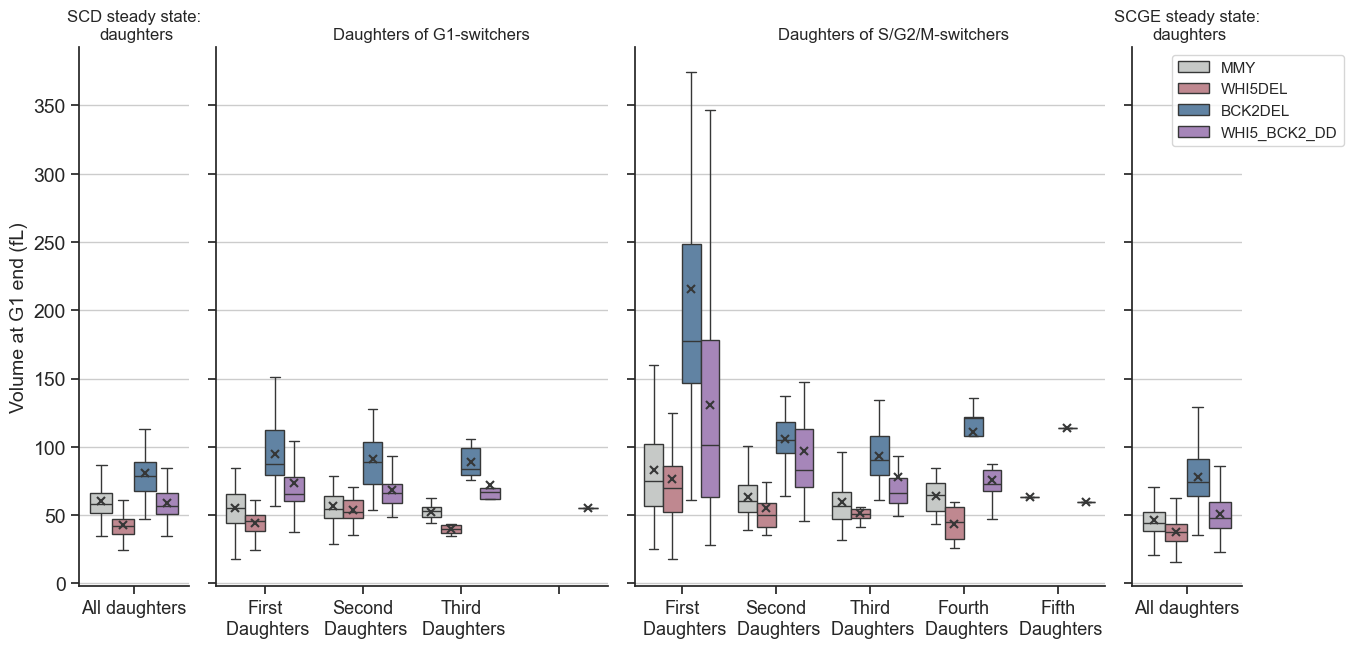

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


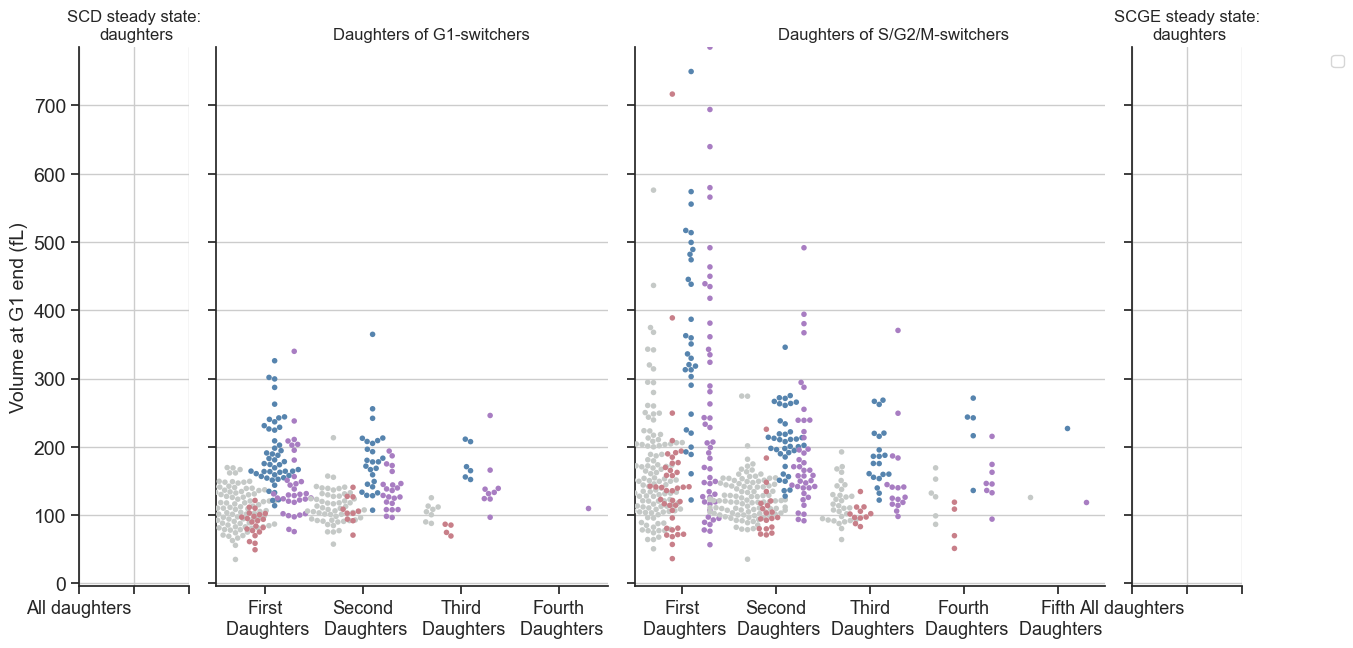

In [63]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2, ax3, ax4)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
A, ((ax5, ax6, ax7, ax8)) = plt.subplots(nrows=1, ncols=4, sharex= False, sharey= True, figsize=(15, 7), gridspec_kw={'width_ratios': [0.7,2.5, 3, 0.7]})
S = sns.boxplot(data=(unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"]), 
                showmeans = True,
                x= "cell_cycle_stage", 
                y="sys_vol_at_frame_inc_G1_cells", 
                hue = "strain", 
                ax = ax1, 
                showfliers = False, 
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax1.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax1.set_ylabel("Volume at G1 end (fL)", fontsize = 14)
ax5.set_title("SCD steady state: \ndaughters", fontsize = 12, x=0.52)
ax5.set_ylabel("Volume at G1 end (fL)", fontsize = 14)
core.run_stats(
      unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCD"],
      "sys_vol_at_frame_inc_G1_cells", group_col=["strain", "cell_cycle_stage"],
      title = "SCD steady state: daughters"
)


S = sns.boxplot(data = (unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"]),
                #order=['G1','S'],
                showmeans = True,
                x= "cell_cycle_stage",
                y="sys_vol_at_frame_inc_G1_cells",
                hue = "strain",
                ax = ax4,
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
ax4.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax4.set_ylabel("")
ax8.set_title("SCGE steady state: \ndaughters", fontsize = 12, x=0.52)
ax8.set_ylabel("")

core.run_stats(
      unique_steady_state_plotting_df[unique_steady_state_plotting_df['growthmedium'] == "SCGE"],
      "sys_vol_at_frame_inc_G1_cells", group_col=["strain", "cell_cycle_stage"],
      title = "SCGE steady state: daughters"
)
S = sns.boxplot(data=unique_first_G1_frame_df_G1daughters,
                showmeans = True,
                x= "G1_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=unique_first_G1_frame_df_G1daughters, 
                       x= "G1_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax6, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
core.run_stats(
      unique_first_G1_frame_df_G1daughters,
      "phase_volume_at_end", group_col=["strain", "G1_switch_cells_daughter_wave"],
      title = "Daughters of G1-switchers"
)

ax2.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("")
ax6.set_title("Daughters of G1-switchers", fontsize = 12, x=0.55)
ax6.set_ylabel("")

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

core.run_stats(
      unique_first_G1_frame_df_Sdaughters,
      "phase_volume_at_end", group_col=["strain", "S_switch_cells_daughter_wave"],
      title = "Daughters of S/G2/M-switchers"
)
A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
                       x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax7, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD"],
                        palette = palette, dodge = True, size = 4)
ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("") 
ax7.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax7.set_ylabel("") 


ax1.legend([],[], frameon=False)
ax2.legend([],[], frameon=False)
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
ax5.legend([],[], frameon=False)
ax6.legend([],[], frameon=False)
ax7.legend([],[], frameon=False)
ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)


ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax1.set_xticklabels(['All daughters'], fontsize = 13)
ax4.set_xticklabels(['All daughters'], fontsize = 13)

ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
ax5.set_xticklabels(['All daughters'], fontsize = 13)
ax8.set_xticklabels(['All daughters'], fontsize = 13)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")
ax4.set_xlabel("")
ax5.set_xlabel("")
ax6.set_xlabel("")
ax7.set_xlabel("")
ax8.set_xlabel("")

S.figure.subplots_adjust(wspace = 0.1)
A.figure.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
sns.despine(ax = ax5)
sns.despine(ax = ax6)
sns.despine(ax = ax7)
sns.despine(ax = ax8)
ax5.set_ylim(ax1.get_ylim())

# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel3_daughtersofswitchers_volatG1end_swarm.svg")
#S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel3_daughtersofswitchers_volatG1end.svg")
plt.show()

# ***Fig 5C: statistics - selected strains*** 

In [40]:
from scipy import stats as scipystats
print("S-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "MMY") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_Sdaughters[(unique_first_G1_frame_df_Sdaughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_Sdaughters["S_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))


print("WT VS WHI5",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (whi5del_df["phase_volume_at_end"]), equal_var = False))
print("WT VS BCK2",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (bck2del_df["phase_volume_at_end"]), equal_var = False))
print("WT VS DD",scipystats.ttest_ind((WT_df["phase_volume_at_end"]), (whi5bck2dd_df["phase_volume_at_end"]), equal_var = False))
print("DD VS BCK2",scipystats.ttest_ind((whi5bck2dd_df["phase_volume_at_end"]), (bck2del_df["phase_volume_at_end"]), equal_var = False))
print("DD VS WHI5",scipystats.ttest_ind((whi5bck2dd_df["phase_volume_at_end"]), (whi5del_df["phase_volume_at_end"]), equal_var = False))

print("G1-switchers first daughters stats:")
WT_df = unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "MMY") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
whi5del_df =  unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
bck2del_df = unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_G1daughters[(unique_first_G1_frame_df_G1daughters["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_G1daughters["G1_switch_cells_daughter_wave"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

print("SCD steady state daughters")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCD")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

print("SCGE steady state daughters")
WT_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "MMY") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
whi5del_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
bck2del_df = unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "BCK2DEL") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]
whi5bck2dd_df =  unique_steady_state_plotting_df[(unique_steady_state_plotting_df["strain"] == "WHI5_BCK2_DD") & (unique_steady_state_plotting_df["growthmedium"] == "SCGE")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

S-switchers first daughters stats:
WT n 123
Bck2del n 34
whi5del n 40
whi5bck2dd n 50
WT VS WHI5 TtestResult(statistic=np.float64(0.6910576377209107), pvalue=np.float64(0.492530441001218), df=np.float64(53.260660352716926))
WT VS BCK2 TtestResult(statistic=np.float64(-5.446889515442022), pvalue=np.float64(4.3126657536661075e-06), df=np.float64(34.5212684009966))
WT VS DD TtestResult(statistic=np.float64(-3.6133283994569703), pvalue=np.float64(0.0006377268721360179), df=np.float64(57.34641029782628))
DD VS BCK2 TtestResult(statistic=np.float64(-3.1348568671599586), pvalue=np.float64(0.0028507471632425478), df=np.float64(51.00633854302823))
DD VS WHI5 TtestResult(statistic=np.float64(3.5192609230044645), pvalue=np.float64(0.0007046094408099213), df=np.float64(83.17048444909689))
G1-switchers first daughters stats:
WT n 103
Bck2del n 48
whi5del n 21
whi5bck2dd n 33
SCD steady state daughters
WT n 198
Bck2del n 214
whi5del n 232
whi5bck2dd n 282
SCGE steady state daughters
WT n 330
Bck2del

# ***Fig S4: Size control in daughters of S/G2/M switchers - selected strains*** 

In [41]:
#  calculating the diTalia metric: alpha*G1length 

In [64]:

######################################### filter for steady state cells with complete cycles only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_cycle'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]

# calculating alpha 
import warnings

with warnings.catch_warnings(record=True):
    for fposid in ((steady_state_completecycles_df['f_pos_cell_id']).unique()):
        selected_cell_df = steady_state_completecycles_df[steady_state_completecycles_df['f_pos_cell_id'] == fposid]
        selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'] = np.log(selected_cell_df['sys_vol_at_frame_inc_G1_cells'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(selected_cell_df['frame_i'],selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'])
        SS_SCDnSCGE.loc[(SS_SCDnSCGE['f_pos_cell_id'] == fposid), 'alpha'] = slope



In [65]:

## filter for nutrient switch first and second daughter wave cells with complete cycles only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
post_switch_daughters_df = selectedstrains_NS_plotting_df[((np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False)|
                                                        (np.isnan(selectedstrains_NS_plotting_df['G1_switch_cells_daughter_wave']) == False))
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_cycle'] == 1)
                                                      ]

# calculating alpha 
import warnings

with warnings.catch_warnings(record=True):
    for fposid in ((post_switch_daughters_df['f_pos_cell_id']).unique()):
        selected_cell_df = post_switch_daughters_df[post_switch_daughters_df['f_pos_cell_id'] == fposid]
        selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'] = np.log(selected_cell_df['combined_mother_bud_volume'])
        slope, intercept, r_value, p_value, std_err = stats.linregress(selected_cell_df['frame_i'],selected_cell_df['ln_sys_vol_at_frame_inc_G1_cells'])
        selectedstrains_NS_plotting_df.loc[(selectedstrains_NS_plotting_df['f_pos_cell_id'] == fposid), 'alpha'] = slope
        
        

In [66]:

# calculate growth-rate standardised G1 length for each cell that has an alpha: (alpha*G1 length (mins)) - steady state

with warnings.catch_warnings(record=True):
    SS_SCDnSCGE['alpha_G1_length_frames'] = SS_SCDnSCGE['alpha']*SS_SCDnSCGE['len_G1']
    SS_SCDnSCGE['ln_birth_or_div_vol'] = np.log(SS_SCDnSCGE['Birth_or_div_vol_fl'])
    
# calculate growth-rate standardised G1 length for each cell that has an alpha: (alpha*G1 length (mins)) - nutrient switch

with warnings.catch_warnings(record=True):
    #selectedstrains_NS_plotting_df['phase_length_mins'] =  selectedstrains_NS_plotting_df['phase_length']*3
    selectedstrains_NS_plotting_df['alpha_phase_length_frames'] = (selectedstrains_NS_plotting_df['alpha'])*(selectedstrains_NS_plotting_df['phase_length'])
    selectedstrains_NS_plotting_df['ln_birth_or_div_vol'] = np.log(selectedstrains_NS_plotting_df['birth_or_div_vol'])
    
#palette ={"MMY": "grey", "WHI5DEL": "teal", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "darkblue"}
   

In [67]:


###############################################  steadystate  #####################################################################

steadystate_completecycles_df = SS_SCDnSCGE[ (SS_SCDnSCGE['complete_phase'] == True) 
                                            & (SS_SCDnSCGE['Daughterhood_binary'] == 1)
                                           & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))]
SCD_steadystate_df = steadystate_completecycles_df[steadystate_completecycles_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steadystate_completecycles_df[steadystate_completecycles_df['growthmedium'] == "SCGE"]

#unique plotting df SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 
SCD_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCD_SS"

#unique plotting df SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)
SCGE_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCGE_SS"
            
##################################################  nutrient switch  ###################################################################

nutrientswitch_complete_wave_cycles_df =  selectedstrains_NS_plotting_df[((np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False))
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                      ]


# unique plotting df nutrient switch 
unique_f_pos_cell_id_3 = []
for fposid in ((nutrientswitch_complete_wave_cycles_df['f_pos_cell_id']).unique()):
    fposid_df = nutrientswitch_complete_wave_cycles_df[nutrientswitch_complete_wave_cycles_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
nutrientswitch_daughterwaves_plotting_df = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
nutrientswitch_daughterwaves_plotting_df['alpha_G1_length_frames'] = nutrientswitch_daughterwaves_plotting_df['alpha_phase_length_frames']

for daughter_wave in nutrientswitch_daughterwaves_plotting_df['S_switch_cells_daughter_wave'].unique():
    nutrientswitch_daughterwaves_plotting_df.loc[(nutrientswitch_daughterwaves_plotting_df['S_switch_cells_daughter_wave'] == daughter_wave), 'plotting_col_ref'] = f'daughter_wave_{daughter_wave}'

figure_plotting_df = pd.concat([SCD_steadystate_daughters_plotting_df, SCGE_steadystate_daughters_plotting_df, nutrientswitch_daughterwaves_plotting_df]).reset_index(drop = True)


inline


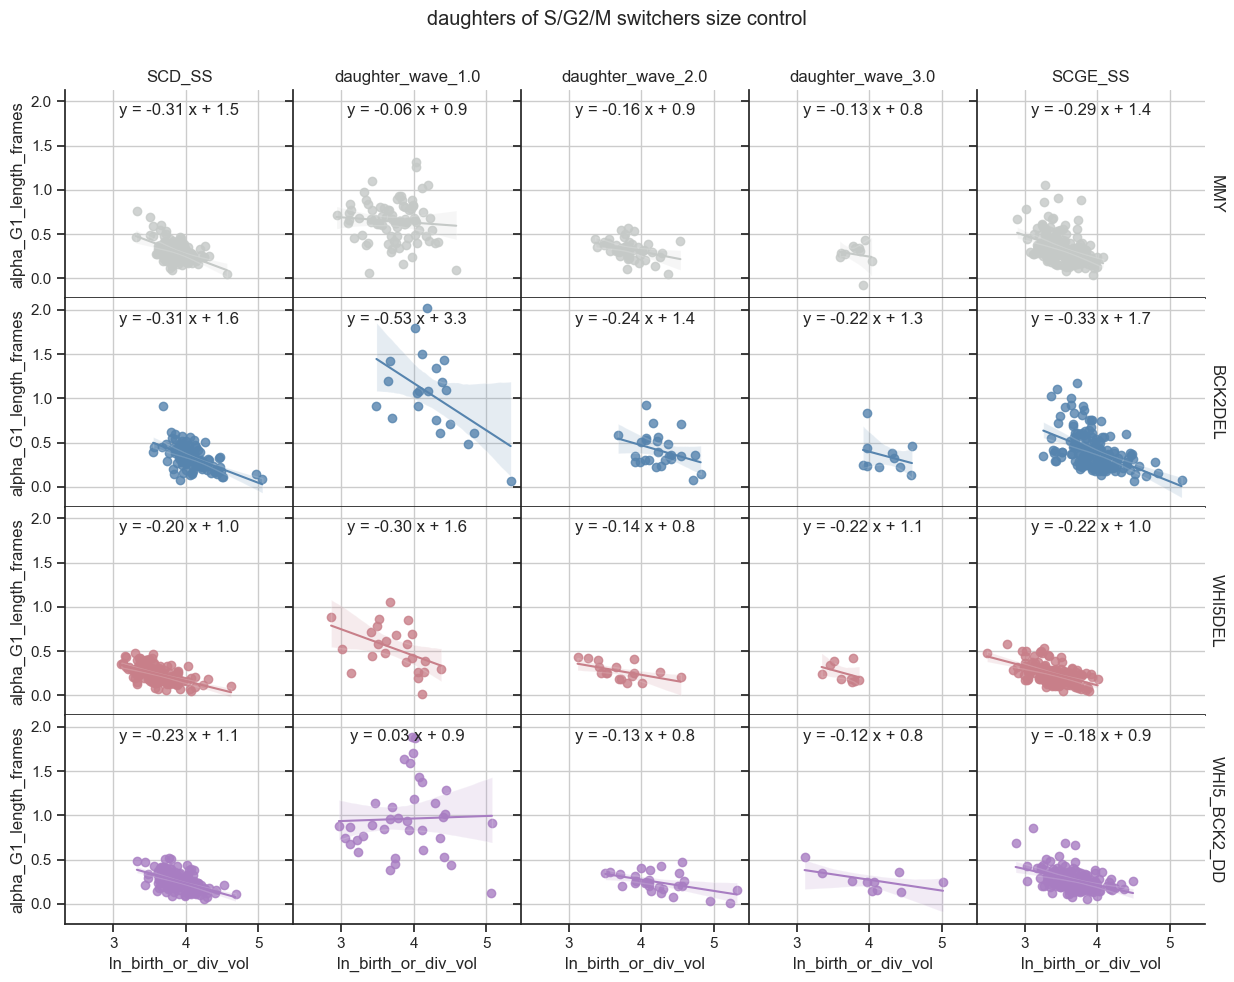

In [73]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

def annotate(data, **kws):
        ax = plt.gca()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
        ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
                horizontalalignment='center',
                verticalalignment='center',
                transform=ax.transAxes)
        #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df[(figure_plotting_df['plotting_col_ref'] != "daughter_wave_4.0") &
                                      (figure_plotting_df['plotting_col_ref'] != "daughter_wave_5.0")], 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'daughter_wave_1.0', 'daughter_wave_2.0', 'daughter_wave_3.0', 'SCGE_SS'],
                  row = "strain", 
                  hue = "strain", 
                  palette = palette,
                  height = 2.5,
                  aspect  =1,
                  margin_titles = True)


b.map_dataframe(sns.regplot, 
      "ln_birth_or_div_vol",
      "alpha_G1_length_frames")


b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
b.fig.suptitle("daughters of S/G2/M switchers size control")
b.figure.subplots_adjust(wspace=0, hspace=0)
b.set()
# ax1.set_title("SCD steady state daughters")
# ax1.set_xlabel("ln(Birth volume)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\supplement\Fig5\panel1.svg", dpi =150)
import matplotlib

%matplotlib inline
print(matplotlib.get_backend())
# plt.show()

# ***Fig 7B and 7C: Daughters of S/G2/M switchers - G1 length and vol at G1 end*** 

In [27]:

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)


############################### pre-switch steady state dataprep ############################################################################

pre_switch_daughters_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD") 
                                                                    & (selectedstrains_NS_plotting_df['generation_num'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
unique_first_G1_frame_df_pre['S_switch_cells_daughter_wave'] = 0

preswitch_plus_postswitch = pd.concat([unique_first_G1_frame_df_Sdaughters, unique_first_G1_frame_df_pre])
preswitch_plus_postswitch['phase_length_mins'] = (preswitch_plus_postswitch['phase_length'])*3





Daughters of S/G2/M-switchers
Group: '['strain', 'S_switch_cells_daughter_wave']'  |  Value: 'phase_length_mins'
    Not enough data points (2) for group '('CLN3DEL', np.float64(3.0))', skipping.
    Not enough data points (1) for group '('CLN3_WHI5_BCK2_TD', np.float64(4.0))', skipping.
    Not enough data points (0) for group '('CLN3_WHI5_DD', np.float64(4.0))', skipping.
    Not enough data points (0) for group '('CLN3DEL', np.float64(4.0))', skipping.


,S_switch_cells_daughter_wave,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(BCK2DEL, 2.0)",39,83.6,84.0,0.95,2,Shapiro-Wilk,0.045050,False
1,"(CLN3_WHI5_BCK2_TD, 2.0)",7,154.7,165.0,-0.02,0,Shapiro-Wilk,0.902889,True
2,"(CLN3DEL, 0.0)",44,22.4,21.0,0.25,3,Shapiro-Wilk,0.767932,True
3,"(MMY, 3.0)",31,57.6,48.0,2.73,1,Shapiro-Wilk,0.000003,False
4,"(MMY, 0.0)",164,25.6,24.0,0.71,4,Shapiro-Wilk,0.000109,False
5,"(WHI5_BCK2_DD, 1.0)",50,321.9,300.0,1.41,2,Shapiro-Wilk,0.000323,False
6,"(WHI5_BCK2_DD, 4.0)",8,51.0,51.0,0.07,0,Shapiro-Wilk,0.142904,True
7,"(WHI5DEL, 3.0)",11,55.9,45.0,0.99,0,Shapiro-Wilk,0.017247,False
8,"(CLN3_WHI5_DD, 2.0)",15,37.6,39.0,-0.99,1,Shapiro-Wilk,0.061953,True
9,"(BCK2DEL, 1.0)",34,423.0,391.5,0.65,1,Shapiro-Wilk,0.121582,True


    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3DEL', np.float64(3.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3DEL', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3_WHI5_DD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3_WHI5_BCK2_TD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3DEL', np.float64(3.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3DEL', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3_WHI5_DD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3_WHI5_BCK2_TD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.floa

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(2.0))",123,104,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(3.0))",123,31,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(4.0))",123,6,0.0000,0.0002,0.0001,True,True,True,False
3,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(0.0))",123,164,0.0000,0.0000,0.0000,True,True,True,False
4,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(1.0))",123,34,0.0014,0.0000,0.0004,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...
460,"('CLN3_WHI5_BCK2_TD', np.float64(1.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(3.0))",11,3,0.0078,0.0728,0.0604,True,False,False,True
461,"('CLN3_WHI5_BCK2_TD', np.float64(1.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(0.0))",11,37,0.0004,0.0000,0.0000,True,True,True,False
462,"('CLN3_WHI5_BCK2_TD', np.float64(2.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(3.0))",7,3,0.1052,0.1206,0.1702,False,False,False,False
463,"('CLN3_WHI5_BCK2_TD', np.float64(2.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(0.0))",7,37,0.0021,0.0000,0.0000,True,True,True,False


c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 36.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWar

...

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 51.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarni

,S_switch_cells_daughter_wave,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(BCK2DEL, 2.0)",39,105.6,105.3,0.44,1,Shapiro-Wilk,1.329710e-01,True
1,"(CLN3_WHI5_BCK2_TD, 2.0)",7,163.1,130.3,0.40,0,Shapiro-Wilk,3.724796e-01,True
2,"(CLN3DEL, 0.0)",44,95.5,95.0,0.48,2,Shapiro-Wilk,2.364652e-01,True
3,"(MMY, 3.0)",31,59.3,56.9,0.59,0,Shapiro-Wilk,3.655930e-01,True
4,"(MMY, 0.0)",164,69.8,70.3,0.53,4,Shapiro-Wilk,9.152734e-04,False
5,"(WHI5_BCK2_DD, 1.0)",50,130.6,101.2,1.13,1,Shapiro-Wilk,8.316180e-05,False
6,"(WHI5_BCK2_DD, 4.0)",8,75.5,73.0,0.31,1,Shapiro-Wilk,8.132043e-01,True
7,"(WHI5DEL, 3.0)",11,51.3,50.8,0.91,1,Shapiro-Wilk,3.717995e-01,True
8,"(CLN3_WHI5_DD, 2.0)",15,68.2,68.1,0.57,0,Shapiro-Wilk,3.951050e-01,True
9,"(BCK2DEL, 1.0)",34,215.7,177.6,2.55,3,Shapiro-Wilk,3.196600e-06,False


    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3DEL', np.float64(3.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3DEL', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3_WHI5_DD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(1.0))' vs '('CLN3_WHI5_BCK2_TD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3DEL', np.float64(3.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3DEL', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3_WHI5_DD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.float64(2.0))' vs '('CLN3_WHI5_BCK2_TD', np.float64(4.0))', skipping.
    Not enough data points for comparison '('MMY', np.floa

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(2.0))",123,104,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(3.0))",123,31,0.0000,0.0015,0.0005,True,True,True,False
2,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(4.0))",123,6,0.0279,0.2449,0.2448,True,False,False,True
3,"('MMY', np.float64(1.0)) vs ('MMY', np.float64(0.0))",123,164,0.0005,0.0001,0.0610,True,True,False,True
4,"('MMY', np.float64(1.0)) vs ('BCK2DEL', np.float64(1.0))",123,34,0.0000,0.0000,0.0000,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...
460,"('CLN3_WHI5_BCK2_TD', np.float64(1.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(3.0))",11,3,0.4199,0.6703,0.2912,False,False,False,False
461,"('CLN3_WHI5_BCK2_TD', np.float64(1.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(0.0))",11,37,0.4058,0.1461,0.2697,False,False,False,False
462,"('CLN3_WHI5_BCK2_TD', np.float64(2.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(3.0))",7,3,0.0431,0.1433,0.1167,True,False,False,True
463,"('CLN3_WHI5_BCK2_TD', np.float64(2.0)) vs ('CLN3_WHI5_BCK2_TD', np.float64(0.0))",7,37,0.0405,0.0001,0.0035,True,True,True,False


C:\Users\timon\AppData\Local\Temp\ipykernel_19760\392795640.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_19760\392795640.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_19760\392795640.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_19760\392795640.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_yticklabels(ax4.get_ytickl

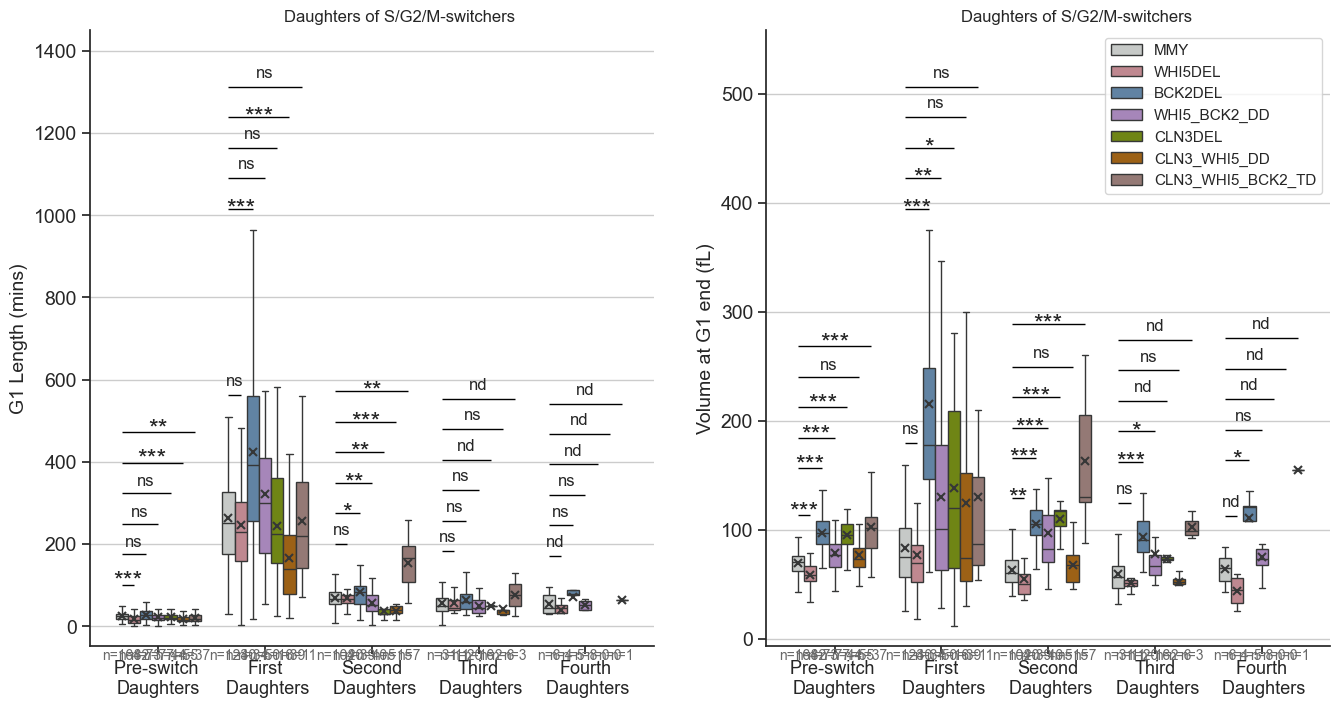

c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 31.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 36.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\timon\venvs\plotting\Lib\site-packages\seaborn\categorical.py:3399: UserWar

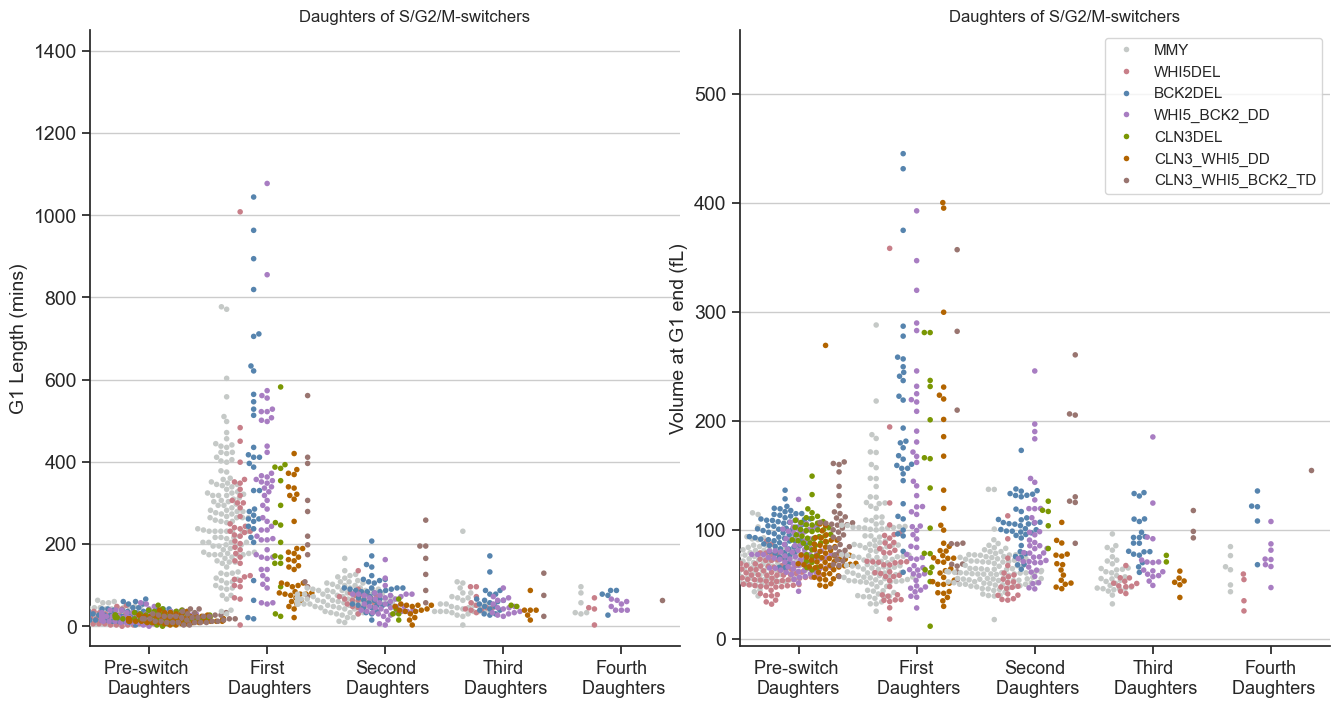

In [37]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", 
          "WHI5_BCK2_DD":"#a87dc2", "CLN3DEL": "#7a9703", "CLN3_WHI5_DD": "#b26400", "CLN3_WHI5_BCK2_TD": "#997570"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(16, 8))
A, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(16, 8))



S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

core.run_stats(
      preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
      "phase_length_mins", group_col=["strain", "S_switch_cells_daughter_wave"],
      title = "Daughters of S/G2/M-switchers"
)
core.annotate_significance_hue_vs_ref(
    ax1, preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
    x_col = "S_switch_cells_daughter_wave", y_col = "phase_length_mins", hue_col = "strain",
    ref_hue = "MMY",
    hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
    test= "mwu", x_order=[0, 1, 2, 3, 4])
A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5], 
                       x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax3, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                        palette = palette, dodge = True, size = 4)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax1.set_ylabel("")
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("")
ax3.set_ylabel("G1 Length (mins)", fontsize = 14)

S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5], 
                       x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax4, hue = "strain", 
                        hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                        palette = palette, dodge = True, size = 4)

core.run_stats(
      preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
      "phase_volume_at_end", group_col=["strain", "S_switch_cells_daughter_wave"],
      title = "Daughters of S/G2/M-switchers"
)
core.annotate_significance_hue_vs_ref(
    ax2, preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] != 5],
    x_col = "S_switch_cells_daughter_wave", y_col = "phase_volume_at_end", hue_col = "strain",
    ref_hue = "MMY",
    hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
    test= "mwu", x_order=[0, 1, 2, 3, 4])
# sns.swarmplot(x = "S_switch_cells_daughter_wave", y="phase_length_mins",
#                 ax = ax1, hue = "strain", data =preswitch_plus_postswitch, 
#               dodge = True, legend = False, edgecolor = "black", linewidth = 0.5, size = 3, color = 'black')
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 
ax4.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax4.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 


ax1.legend([],[], frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax4.set_ylim(ax2.get_ylim())
ax3.set_ylim(ax1.get_ylim())
ax1.set_xlabel("") 
ax2.set_xlabel("") 
ax3.set_xlabel("") 
ax4.set_xlabel("") 
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 14)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 14)
ax4.set_yticklabels(ax4.get_yticklabels(), fontsize = 14)

ax1.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax2.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
ax4.set_xticklabels(['Pre-switch \nDaughters','First\n Daughters','Second\n Daughters',
                   'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)

plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)



#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel2_daughtersofSswitchers_G1_length_and_volatG1end.svg")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel2_daughtersofSswitchers_G1_length_and_volatG1end_swarm.svg")
plt.show()

In [49]:
print("S-switchers first daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers second daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 2)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers third daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 3)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("S-switchers fourth daughters stats:")
cln3del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3DEL") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]
whi5cln3dd_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_DD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]
whi5cln3bck2del_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "CLN3_WHI5_BCK2_TD") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 4)]

print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

S-switchers first daughters stats:
cln3del n 16
whi5cln3dd n 39
whi5cln3bck2del n 11
S-switchers second daughters stats:
cln3del n 5
whi5cln3dd n 15
whi5cln3bck2del n 7
S-switchers third daughters stats:
cln3del n 2
whi5cln3dd n 6
whi5cln3bck2del n 3
S-switchers fourth daughters stats:
cln3del n 0
whi5cln3dd n 0
whi5cln3bck2del n 1


# ***Fig 7A: Birth volume pre-switch steady state cells*** 

In [30]:
############################### pre-switch steady state dataprep ############################################################################

pre_switch_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD")
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_complete_G1_df[pre_switch_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)




Group: '['daughterhood_binary', 'strain']'  |  Value: 'cell_vol_fl'


,strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(0, CLN3_WHI5_BCK2_TD)",34,140.9,119.5,2.07,2,Shapiro-Wilk,2.265050e-05,False
1,"(0, WHI5_BCK2_DD)",95,103.6,97.0,1.01,3,Shapiro-Wilk,6.176745e-04,False
2,"(0, CLN3DEL)",48,146.5,121.8,1.43,5,Shapiro-Wilk,1.168500e-06,False
3,"(1, MMY)",164,58.3,57.7,0.84,3,Shapiro-Wilk,7.485650e-05,False
4,"(1, CLN3_WHI5_DD)",55,69.1,66.4,4.87,1,Shapiro-Wilk,0.000000e+00,False
5,"(0, WHI5DEL)",87,78.5,75.6,0.99,4,Shapiro-Wilk,8.976038e-04,False
6,"(0, BCK2DEL)",95,133.2,124.3,2.05,6,Shapiro-Wilk,2.600000e-09,False
7,"(0, MMY)",209,89.9,85.4,2.46,13,Shapiro-Wilk,0.000000e+00,False
8,"(1, WHI5_BCK2_DD)",77,67.4,65.9,0.58,3,Shapiro-Wilk,2.745401e-02,False
9,"(0, CLN3_WHI5_DD)",61,102.9,93.5,5.73,1,Shapiro-Wilk,0.000000e+00,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"(np.int64(0), 'MMY') vs (np.int64(0), 'BCK2DEL')",209,95,0.0000,0.0000,0.0000,True,True,True,False
1,"(np.int64(0), 'MMY') vs (np.int64(0), 'WHI5DEL')",209,87,0.0001,0.0002,0.0000,True,True,True,False
2,"(np.int64(0), 'MMY') vs (np.int64(0), 'WHI5_BCK2_DD')",209,95,0.0001,0.0000,0.0000,True,True,True,False
3,"(np.int64(0), 'MMY') vs (np.int64(0), 'CLN3DEL')",209,48,0.0000,0.0000,0.0000,True,True,True,False
4,"(np.int64(0), 'MMY') vs (np.int64(0), 'CLN3_WHI5_DD')",209,61,0.0720,0.0089,0.0110,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...
86,"(np.int64(1), 'WHI5_BCK2_DD') vs (np.int64(1), 'CLN3_WHI5_DD')",77,55,0.6862,0.6565,0.9632,False,False,False,False
87,"(np.int64(1), 'WHI5_BCK2_DD') vs (np.int64(1), 'CLN3_WHI5_BCK2_TD')",77,37,0.0001,0.0000,0.0000,True,True,True,False
88,"(np.int64(1), 'CLN3DEL') vs (np.int64(1), 'CLN3_WHI5_DD')",44,55,0.0258,0.0354,0.0001,True,True,True,False
89,"(np.int64(1), 'CLN3DEL') vs (np.int64(1), 'CLN3_WHI5_BCK2_TD')",44,37,0.0954,0.0809,0.2056,False,False,False,False


C:\Users\timon\AppData\Local\Temp\ipykernel_19760\2651659215.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)
C:\Users\timon\AppData\Local\Temp\ipykernel_19760\2651659215.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)


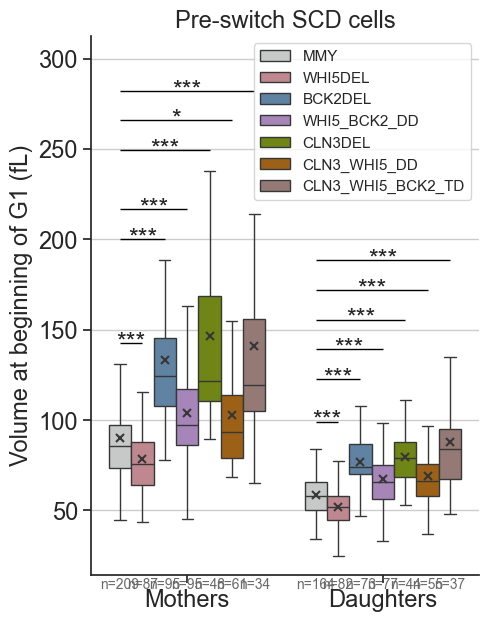

In [35]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", 
          "WHI5_BCK2_DD":"#a87dc2", "CLN3DEL": "#7a9703", "CLN3_WHI5_DD": "#b26400", "CLN3_WHI5_BCK2_TD": "#997570"}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

S, (ax1) = plt.subplots(nrows=1, ncols=1, sharex= False, sharey= True, figsize=(5, 7))


S = sns.boxplot(data=unique_first_G1_frame_df_pre,
                showmeans = True,
                x= "daughterhood_binary",
                y="cell_vol_fl",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
import importlib
import core
importlib.reload(core)
core.annotate_significance_hue_vs_ref(
    ax1, unique_first_G1_frame_df_pre, x_col = "daughterhood_binary", 
    y_col = "cell_vol_fl", hue_col = "strain", ref_hue = "MMY", 
    hue_order = ["MMY", "WHI5DEL", "BCK2DEL",  "WHI5_BCK2_DD", "CLN3DEL", "CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
    test= "mwu", x_order=[0, 1])
core.run_stats(
    plotting_df=unique_first_G1_frame_df_pre, value_cols = "cell_vol_fl",
    group_col = ["daughterhood_binary", "strain"]
)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Pre-switch SCD cells", fontsize = 17)
ax1.set_ylabel("")
ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)
ax1.set_xlabel("")



# plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)



#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel1_preswitchcells_vol_at_birth.svg")
plt.show()

In [52]:
print("pre-switch daughters stats:")
cln3del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5cln3dd_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5cln3bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_BCK2_TD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
WT_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "MMY") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
whi5bck2dd_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))
print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

print("pre-switch mothers stats:")
cln3del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5cln3dd_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5cln3bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "CLN3_WHI5_BCK2_TD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
WT_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "MMY") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "BCK2DEL") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
whi5bck2dd_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "WHI5_BCK2_DD") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))
print("cln3del n", len(cln3del_df))
print("whi5cln3dd n", len(whi5cln3dd_df))
print("whi5cln3bck2del n", len(whi5cln3bck2del_df))

pre-switch daughters stats:
WT n 164
Bck2del n 73
whi5del n 82
whi5bck2dd n 77
cln3del n 44
whi5cln3dd n 55
whi5cln3bck2del n 37
pre-switch mothers stats:
WT n 209
Bck2del n 95
whi5del n 87
whi5bck2dd n 95
cln3del n 48
whi5cln3dd n 61
whi5cln3bck2del n 34


# ***Fig S5: Death Analysis*** 

In [53]:
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")]

In [54]:
# add 'does_cell_die_in_experiment', 'does_cell_die_in_this_cycle' and 'does_cell_die_in_this_phase' to nutrient switch data
import warnings

with warnings.catch_warnings(record=True):
    
    list_for_joining = []
    i=0
    for rep in selectedstrains_NS_plotting_df['rep'].unique():
        rep_df = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    
                    if sum(cell_df['is_cell_dead']) > 0:
                        cell_df['does_cell_die_in_experiment'] = 1
                        if strain == "MMY":
                            i=i+1
                    else:
                        cell_df['does_cell_die_in_experiment'] = 0
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        if sum(cycle_df['is_cell_dead']) > 0:
                            cycle_df['does_cell_die_in_this_cycle'] = 1
                        else:
                            cycle_df['does_cell_die_in_this_cycle'] = 0    
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    plotting_df = pd.concat(list_for_joining)   

In [55]:
# add 'does_cell_die_in_experiment', 'does_cell_die_in_this_cycle' and 'does_cell_die_in_this_phase' to steady state data
import warnings

with warnings.catch_warnings(record=True):
    
    list_for_joining = []
    i=0
    for rep in SS_SCDnSCGE['rep'].unique():
        rep_df = SS_SCDnSCGE[SS_SCDnSCGE['rep'] == rep]
        for medium in rep_df['growthmedium'].unique():
            medium_df = rep_df[rep_df['growthmedium'] == medium]
            for strain in medium_df['strain'].unique():
                strain_df = medium_df[medium_df['strain'] == strain]
                for pos in (strain_df['position']).unique():
                    pos_df = strain_df[strain_df["position"] == pos]
                    pos_max_frame = pos_df['frame_i'].max()
                    pos_min_frame = pos_df['frame_i'].min()
                    for cell in (pos_df['Cell_ID']).unique():
                        cell_df = pos_df[pos_df["Cell_ID"] == cell]

                        if sum(cell_df['is_cell_dead']) > 0:
                            cell_df['does_cell_die_in_experiment'] = 1
                            if strain == "MMY":
                                i=i+1
                        else:
                            cell_df['does_cell_die_in_experiment'] = 0
                        for cycle in (cell_df['generation_num']).unique(): 
                            cycle_df = cell_df[cell_df["generation_num"] == cycle]
                            cycle_df = cycle_df.sort_values(by = 'frame_i')
                            if sum(cycle_df['is_cell_dead']) > 0:
                                cycle_df['does_cell_die_in_this_cycle'] = 1
                            else:
                                cycle_df['does_cell_die_in_this_cycle'] = 0    
                            for phase in (cycle_df['cell_cycle_stage'].unique()):
                                phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                                if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                    phase_df['complete_phase'] = 1
                                    phase_df['does_cell_die_in_this_phase'] = 0
                                if sum(phase_df['is_cell_dead']) > 0:
                                    phase_df['complete_phase'] = 0
                                    phase_df['does_cell_die_in_this_phase'] = 1
                                else:
                                    phase_df['does_cell_die_in_this_phase'] = 0
                                list_for_joining.append(phase_df)
    steady_state_plotting_df = pd.concat(list_for_joining)  

In [56]:
# dataprep  steadystate  
# only keep complete cycles and cycles where cells died (drop cycles that are incomplete not due to dying but due to end or beginning of experiment)
steady_state_complete_plus_dead_cycles_df = steady_state_plotting_df.drop(steady_state_plotting_df[(steady_state_plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)

#select strains and split by media
steadystate_df = steady_state_complete_plus_dead_cycles_df[(steady_state_complete_plus_dead_cycles_df['strain'] == "MMY")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "WHI5DEL")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "BCK2DEL")|
                                            (steady_state_complete_plus_dead_cycles_df['strain'] == "WHI5_BCK2_DD")]
SCD_steadystate_df = steadystate_df[steadystate_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steadystate_df[steadystate_df['growthmedium'] == "SCGE"]

#get only first G1 frame for each cell-cycle SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 


#get only first G1 frame for each cell-cycle SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)


C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1197686347.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  steady_state_complete_plus_dead_cycles_df = steady_state_plotting_df.drop(steady_state_plotting_df[(steady_state_plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)


In [57]:
# dataprep  nutrient switch  
# only keep complete cycles and cycles where cells died (drop cycles that are incomplete not due to dying but due to end or beginning of experiment)

complete_plus_dead_cycles_df = plotting_df.drop(plotting_df[(plotting_df['does_cell_die_in_this_cycle'] == 0) & (plotting_df['complete_cycle'] == 0)].index)

#get only first G1 frame for each cell cycle
first_frame_list = []
for cycle in complete_plus_dead_cycles_df.f_pos_cell_id.unique():
    cycle_df = complete_plus_dead_cycles_df[complete_plus_dead_cycles_df['f_pos_cell_id'] == cycle]
    first_frame_list.append(cycle_df.iloc[:1])
all_first_frame_df = pd.concat(first_frame_list).reset_index(drop = True)

# from nutrient switch data, drop cycles that were completed pre-switch because they do not reflect death in nutrient-switch conditions
first_frame_df = all_first_frame_df.drop(all_first_frame_df[(all_first_frame_df['growthmedium'] == "SCD") & (all_first_frame_df['cycle_saw_switch'] == False)].index)

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1571854544.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1571854544.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1571854544.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1571854544.py:80: UserWarning: set_ticklabels() should only be used with a fixed

Text(0.5, 0, '')

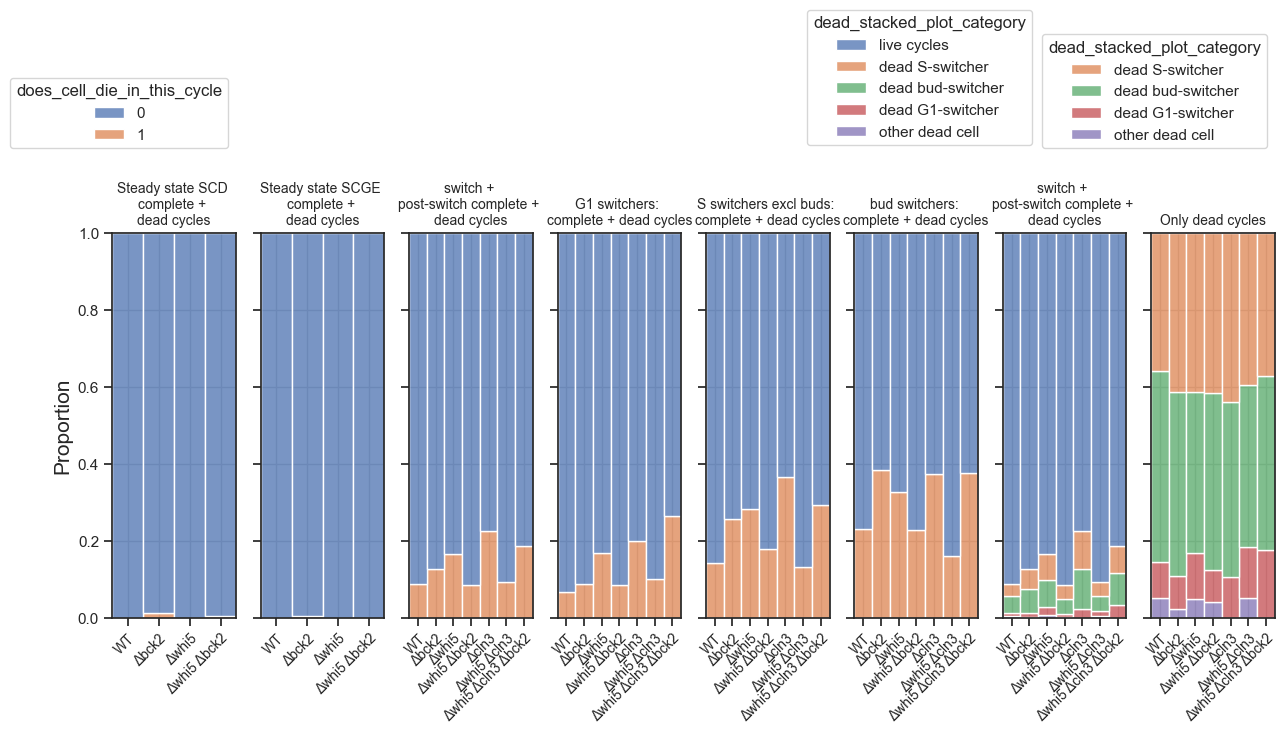

In [58]:
# plot
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

a, (ax1, ax0, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(nrows=1, ncols=8, sharex= False, sharey= True, figsize=(15, 5))

######### complete + dead cycles of steady state SCD cells #######################################################################
a = sns.histplot(data = SCD_steadystate_plotting_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD"],
                 multiple = "fill", 
                 ax=ax1,
                 discrete = True)
sns.move_legend(ax1, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax1.set_title("Steady state SCD \ncomplete + \ndead cycles", fontsize = 10)
ax1.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax1.set_xlabel("")

######### complete + dead cycles of steady state SCGE cells #######################################################################
a = sns.histplot(data = SCGE_steadystate_plotting_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD"],
                 multiple = "fill", 
                 ax=ax0,
                 discrete = True)
#sns.move_legend(ax0, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax0.set_title("Steady state SCGE \ncomplete + \ndead cycles", fontsize = 10)
ax0.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax0.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2"], fontsize = 10)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax0.set_xlabel("")
######### complete + dead cycles of nutrient switch facing ro post-switch cells #######################################################################
a = sns.histplot(data = first_frame_df, 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax2,
                 discrete = True)
#sns.move_legend(ax2, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax2.set_title("switch + \npost-switch complete + \ndead cycles", fontsize = 10)
ax2.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax2.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax2.set_xlabel("")

######### complete + dead cycles of cells that saw switch in G1 #######################################################################
a = sns.histplot(data = first_frame_df[first_frame_df['cell_saw_switch_in_G1'] == True], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax3,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax3.set_title("G1 switchers: \ncomplete + dead cycles", fontsize = 10)
ax3.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax3.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax3.set_xlabel("")

######### complete + dead cycles of cells that saw switch in S excl buds #######################################################################
a = sns.histplot(data = first_frame_df[(first_frame_df['cell_saw_switch_in_S'] == True) & (first_frame_df['cell_saw_switch_as_bud'] == False)], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax4,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax4.set_title("S switchers excl buds: \ncomplete + dead cycles", fontsize = 10)
ax4.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax4.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax4.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax4.set_xlabel("")

######### complete + dead cycles of cells that saw switch as buds #######################################################################
a = sns.histplot(data = first_frame_df[(first_frame_df['cell_saw_switch_in_S'] == True) & (first_frame_df['cell_saw_switch_as_bud'] == True)], 
                 hue = "does_cell_die_in_this_cycle", 
                 x = "strain", 
                 legend = False,
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax5,
                 discrete = True)
#sns.move_legend(ax1, "lower right", bbox_to_anchor=(3, 1))
#display(ax1.get_xticklabels())
ax5.set_title("bud switchers: \ncomplete + dead cycles", fontsize = 10)
ax5.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax5.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax5.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax5.set_xlabel("")
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1), 'dead_stacked_plot_category'] = "other dead cell"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_S'] == True) & 
                   (first_frame_df['cell_saw_switch_as_bud'] == True), 'dead_stacked_plot_category'] = "dead bud-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_S'] == True) & 
                   (first_frame_df['cell_saw_switch_as_bud'] == False), 'dead_stacked_plot_category'] = "dead S-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == 1) & 
                   (first_frame_df['cell_saw_switch_in_G1'] == True), 'dead_stacked_plot_category'] = "dead G1-switcher"
first_frame_df.loc[(first_frame_df['does_cell_die_in_this_cycle'] == False), 'dead_stacked_plot_category'] = "live cycles"

######### complete + dead cycles of ALL CELLS #######################################################################


a = sns.histplot(data = first_frame_df, 
                 hue = "dead_stacked_plot_category", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax6,
                 discrete = True)
sns.move_legend(ax6, "upper right", bbox_to_anchor=(0.3, 1.6))
#display(ax1.get_xticklabels())
ax6.set_title("switch + \npost-switch complete + \ndead cycles", fontsize = 10)
ax6.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax6.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax6.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax6.set_xlabel("")

######### dead cycles of ALL CELLS #######################################################################
palette = ['#dd8452','#55a868', '#c44e52', '#8172b3']
a = sns.histplot(data = first_frame_df[first_frame_df['does_cell_die_in_this_cycle'] == 1], 
                 hue = "dead_stacked_plot_category", 
                 x = "strain", 
                 #x_order = ["MMY", "BCK2DEL", "WHI5DEL", "WHI5_BCK2_DD","CLN3DEL","CLN3_WHI5_DD", "CLN3_WHI5_BCK2_TD"],
                 multiple = "fill", 
                 ax=ax7,
                 palette=palette,
                 discrete = True)
sns.move_legend(ax7, "lower right", bbox_to_anchor=(1, 1.2))
#display(ax1.get_xticklabels())
ax7.set_title("Only dead cycles", fontsize = 10)
ax7.set_ylabel("Proportion", fontsize = 15)
# ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax7.set_xticklabels(["WT", "Δbck2", "Δwhi5",  "Δwhi5 Δbck2", "Δcln3", "Δwhi5 Δcln3", "Δwhi5 Δcln3 Δbck2"], fontsize = 10)
plt.setp(ax7.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 15)
ax7.set_xlabel("")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig7\Panel3_death_analysis_updated_150724.svg", bbox_inches = 'tight')

In [59]:
# colours and labels were edited further in inkscape

# ***Fig 3A: Calculating total number of complete cycles for paper*** 

In [38]:
#nutrient-switch data (selected strains only)
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_DD")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "CLN3_WHI5_BCK2_TD")
                                                                    ]
complete_cycles = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['complete_cycle'] == 1]
pos_len= 0
complete_cycle_length =len(complete_cycles.f_pos_cell_id.unique())
for rep in ((complete_cycles['rep']).unique()):
    rep_df = complete_cycles[complete_cycles['rep'] == rep]
    for strain in ((rep_df['strain']).unique()):
        strain_df = rep_df[rep_df['strain'] == strain]
        pos_len =pos_len + len(strain_df.position.unique())

display("number of complete cycles (nutrient switch data only):", complete_cycle_length)
display("number of positions (nutrient switch data only):", pos_len)

#for selected strains in steady-state, add no of positions and complete cell cycles to what was calculated for nutrient switch above
complete_cycles = SS_SCDnSCGE[SS_SCDnSCGE['complete_cycle'] == 1]
for rep in ((complete_cycles['rep']).unique()):
    rep_df = complete_cycles[complete_cycles['rep'] == rep]
    for medium in ((rep_df['growthmedium']).unique()):
        medium_df = rep_df[rep_df['growthmedium'] == medium]
        for strain in ((medium_df['strain']).unique()):
            strain_df = medium_df[medium_df['strain'] == strain]
            if ((strain == "CCR4DEL") | 
                (strain == "WHI5_CCR4_DD")) & (medium == "SCGE"):
                pass
            else:
                pos_len =pos_len + len(strain_df.position.unique())
                complete_cycle_length =complete_cycle_length + len(strain_df.f_pos_cell_id.unique())
display("total positions", pos_len)
display("total complete cycles", complete_cycle_length)


'number of complete cycles (nutrient switch data only):'

6226

'number of positions (nutrient switch data only):'

149

'total positions'

269

'total complete cycles'

9219

In [61]:
# add to this the complete cycles and position numbers from cell cycle marker experiment for the number shown in Fig 3A

# ***Revision1: Bootstrapping permutations of positions and calculating frame-specific CVs for every permutation.*** 
# ***including all positions*** 

In [62]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
# display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))
chosen_strains_df = select_strains_df[(select_strains_df["is_cell_dead"] == 0) & (select_strains_df["relationship"] == "mother")]
chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)
# chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
#                          (chosen_strains_df['position'] == "Position_38") & 
#                          (chosen_strains_df['rep'] == 2)
#                          ].index)
# chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
#                          (chosen_strains_df['position'] == "Position_5") & 
#                          (chosen_strains_df['rep'] == 2)
#                          ].index)
#display(chosen_strains_df.head(30))

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3434976119.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)


In [63]:
# STRATEGY:
# bootstrap position names within strains (10000 iterations)
# calculate frame-specific CVs with new position combination for every frame for every iteration
# plot frame-specific CVs as a lineplot
# check for significance using CI of differences between bootstrapped CVs of strains as per:
# https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.



In [64]:
# pip install statsmodels

In [65]:
import numpy as np
import pandas as pd
from tqdm import tqdm

seed = 42
n_iterations = 1000
all_records = []

for strain in chosen_strains_df.strain.unique():
    strain_df = chosen_strains_df[chosen_strains_df['strain'] == strain]
    pos_list = strain_df.unique_pos_rep_id.unique()
    n_pos = len(pos_list)
    display(strain, n_pos)

    # Extract columns to numpy once
    vol_arr   = strain_df['combined_mother_bud_volume'].to_numpy(dtype=np.float64)
    frame_arr = strain_df['frame_i'].to_numpy()

    # Encode object cell IDs to integers once (bijection, safe for counting)
    _, cell_arr = np.unique(strain_df['f_pos_cell_id'].to_numpy(), return_inverse=True)

    # Build pos -> local row indices lookup once
    pos_arr = strain_df['unique_pos_rep_id'].to_numpy()
    pos_to_rows = {pos: np.where(pos_arr == pos)[0] for pos in pos_list}

    # Pre-generate all bootstrap pos indices: shape (n_iterations, n_pos)
    rng = np.random.default_rng(seed)
    all_boot_idx = rng.integers(0, n_pos, size=(n_iterations, n_pos))

    pbar = tqdm(total=n_iterations, desc=f'{strain} bootstrapping', leave=True)
    for i in range(n_iterations):
        boot_pos_idx  = all_boot_idx[i]
        resampled_pos = pos_list[boot_pos_idx]
        row_idx       = np.concatenate([pos_to_rows[p] for p in resampled_pos])

        boot_vol   = vol_arr[row_idx]
        boot_frame = frame_arr[row_idx]
        boot_cell  = cell_arr[row_idx]

        # Vectorized per-frame stats
        frames, inv, frame_counts = np.unique(boot_frame, return_inverse=True, return_counts=True)
        n_frames = len(frames)

        sum_v  = np.bincount(inv, weights=boot_vol,      minlength=n_frames)
        sum_sq = np.bincount(inv, weights=boot_vol ** 2, minlength=n_frames)
        mean_v = sum_v / frame_counts
        std_v  = np.sqrt(np.maximum(sum_sq / frame_counts - mean_v ** 2, 0.0))
        cv_v   = std_v / mean_v

        # Unique cell count per frame via integer pair trick
        pairs          = np.stack([inv, boot_cell], axis=1)
        uniq_pairs     = np.unique(pairs, axis=0)
        n_unique_cells = np.bincount(uniq_pairs[:, 0], minlength=n_frames)

        all_records.append(pd.DataFrame({
            'strain':              np.full(n_frames, strain),
            'iteration':           np.full(n_frames, i, dtype=np.intp),
            'pos_list':            [resampled_pos] * n_frames,
            'frame_i':             frames,
            'bs_mean_vol_frame':   mean_v,
            'bs_stdev_vol_frame':  std_v,
            'bs_CV_sys_vol_frame': cv_v,
            'n_cells_frame':       n_unique_cells,
        }))

        pbar.update(1)
    pbar.close()


bootstrapped_cv_df = pd.concat(all_records, ignore_index=True)
bootstrapped_cv_df.sort_values(by=['strain', 'iteration', 'frame_i'], inplace=True)
display(bootstrapped_cv_df.head(10))

'MMY'

39

MMY bootstrapping: 100%|██████████| 1000/1000 [02:20<00:00,  7.12it/s]


'WHI5_BCK2_DD'

29

WHI5_BCK2_DD bootstrapping: 100%|██████████| 1000/1000 [01:03<00:00, 15.70it/s]


,strain,iteration,pos_list,frame_i,bs_mean_vol_frame,bs_stdev_vol_frame,bs_CV_sys_vol_frame,n_cells_frame
0,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_8_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_1_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_9_Rep_2, Position_2_Rep_3, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_7_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_9_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4, Position_2_Rep_2]",0,106.689849,36.711857,0.344099,81
1,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_8_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_1_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_9_Rep_2, Position_2_Rep_3, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_7_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_9_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4, Position_2_Rep_2]",1,101.352424,36.725627,0.362356,86
2,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_8_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_1_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_9_Rep_2, Position_2_Rep_3, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_7_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_9_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4, Position_2_Rep_2]",2,103.999186,39.486697,0.379683,87
3,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_8_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_1_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_9_Rep_2, Position_2_Rep_3, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_7_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_9_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4, Position_2_Rep_2]",3,103.259509,38.355484,0.371447,89
4,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_8_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_1_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_9_Rep_2, Position_2_Rep_3, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_7_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_9_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4, Position_2_Rep_2]",4,103.003266,38.379204,0.372602,91
5,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_8_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, 

In [66]:
bootstrapped_cv_df['frame_rel_to_nutrient_switch'] = bootstrapped_cv_df['frame_i'] - 50
bootstrapped_cv_df['time_rel_to_nutrient_switch_hours'] = (bootstrapped_cv_df['frame_rel_to_nutrient_switch']*3)/60

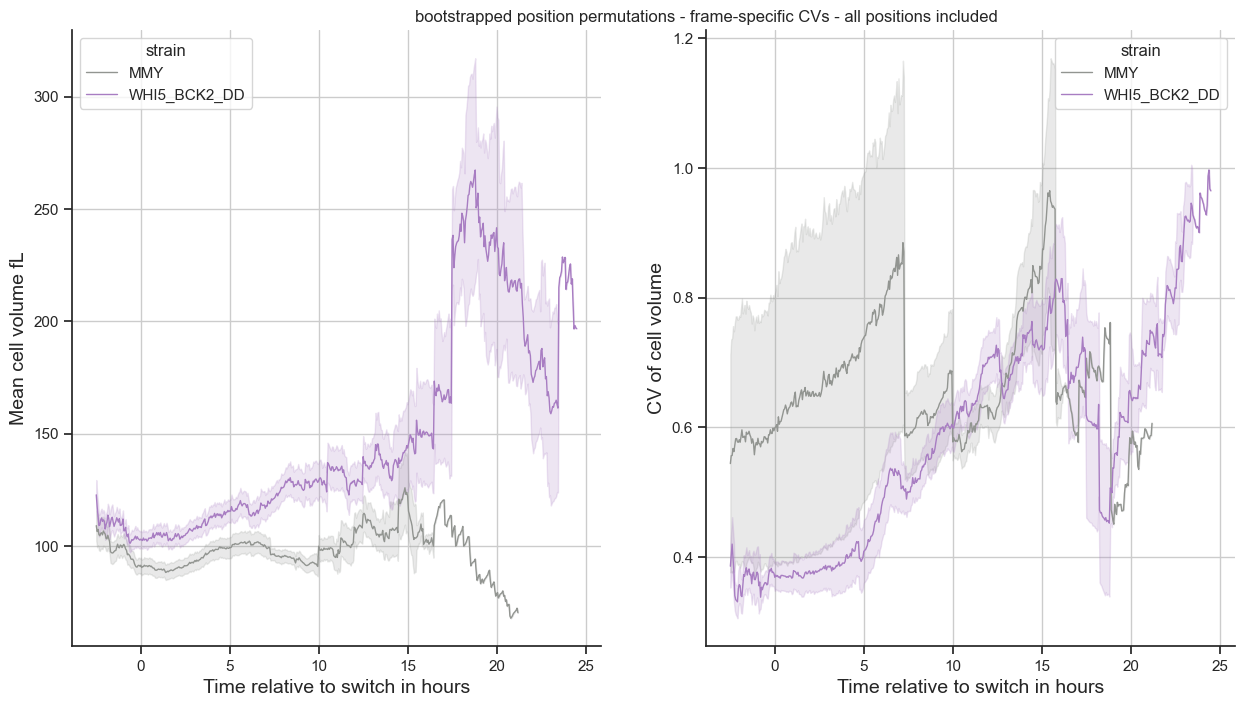

In [67]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 

sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(15, 8) )
S = sns.lineplot(data = bootstrapped_cv_df,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="bs_mean_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="bs_CV_sys_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )

S.set_title("bootstrapped position permutations - frame-specific CVs - all positions included", fontsize = 12, x= 0)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
sns.despine(ax = ax1)
sns.despine(ax = ax2)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\bs_post_switch_CVs_allpos_microscopy.svg')

In [68]:
# plot sd instead of ci
#save dataframes for further analysis to save computation time in future
bootstrapped_cv_df.to_csv(r'bootstrapped_cv_df_2.csv', index = False)

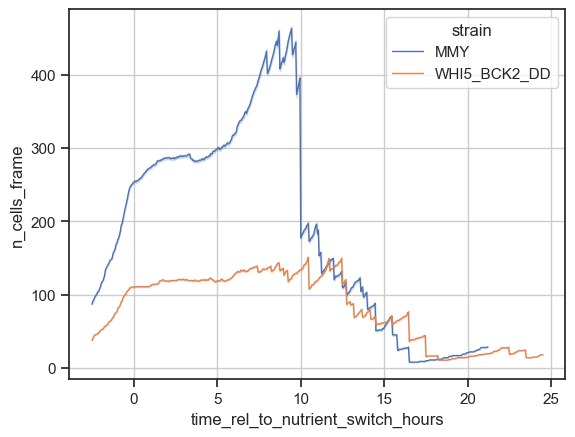

In [69]:
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                #ax = ax3,
                y="n_cells_frame", 
                # style = 'rep',
                hue = "strain", 
                   )

# ***Revision1: Bootstrapping permutations of positions and calculating frame-specific CVs for every permutation.*** 
# ***excluding one outlier position*** 

In [70]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
# display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))
chosen_strains_df = select_strains_df[(select_strains_df["is_cell_dead"] == 0) & (select_strains_df["relationship"] == "mother")]
chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)
# chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
#                          (chosen_strains_df['position'] == "Position_3") & 
#                          (chosen_strains_df['rep'] == 4)
#                          ].index)
chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
                         (chosen_strains_df['position'] == "Position_5") & 
                         (chosen_strains_df['rep'] == 2)
                         ].index)
#display(chosen_strains_df.head(30))

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1626603651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)


In [71]:
# STRATEGY:
# bootstrap position names within strains (10000 iterations)
# calculate frame-specific CVs with new position combination for every frame for every iteration
# plot frame-specific CVs as a lineplot
# check for significance using CI of differences between bootstrapped CVs of strains as per:
# https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.



In [72]:
# pip install statsmodels

In [73]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

seed = 42
n_iterations = 1000
all_records = []

for strain in chosen_strains_df.strain.unique():
    strain_df = chosen_strains_df[chosen_strains_df['strain'] == strain]
    pos_list = strain_df.unique_pos_rep_id.unique()
    n_pos = len(pos_list)
    display(strain, n_pos)

    # Extract columns to numpy once
    vol_arr   = strain_df['combined_mother_bud_volume'].to_numpy(dtype=np.float64)
    frame_arr = strain_df['frame_i'].to_numpy()

    # Encode object cell IDs to integers once
    _, cell_arr = np.unique(strain_df['f_pos_cell_id'].to_numpy(), return_inverse=True)

    # Build pos -> local row indices lookup once
    pos_arr = strain_df['unique_pos_rep_id'].to_numpy()
    pos_to_rows = {pos: np.where(pos_arr == pos)[0] for pos in pos_list}

    for i in tqdm(range(n_iterations), desc=str(strain), leave=True):
        # Replicate sklearn.resample(replace=True, random_state=seed+i)
        rng = np.random.default_rng(seed + i)
        boot_pos_idx  = rng.integers(0, n_pos, size=n_pos)
        resampled_pos = pos_list[boot_pos_idx]

        if i == 1:
            display(resampled_pos)
            display(len(resampled_pos))

        row_idx    = np.concatenate([pos_to_rows[p] for p in resampled_pos])
        boot_vol   = vol_arr[row_idx]
        boot_frame = frame_arr[row_idx]
        boot_cell  = cell_arr[row_idx]

        # Vectorized per-frame stats
        frames, inv, frame_counts = np.unique(boot_frame, return_inverse=True, return_counts=True)
        n_frames = len(frames)

        sum_v  = np.bincount(inv, weights=boot_vol,      minlength=n_frames)
        sum_sq = np.bincount(inv, weights=boot_vol ** 2, minlength=n_frames)
        mean_v = sum_v / frame_counts
        std_v  = np.sqrt(np.maximum(sum_sq / frame_counts - mean_v ** 2, 0.0))
        cv_v   = std_v / mean_v

        # Unique cell count per frame
        pairs          = np.stack([inv, boot_cell], axis=1)
        uniq_pairs     = np.unique(pairs, axis=0)
        n_unique_cells = np.bincount(uniq_pairs[:, 0], minlength=n_frames)

        all_records.append(pd.DataFrame({
            'strain':              np.full(n_frames, strain),
            'iteration':           np.full(n_frames, i, dtype=np.intp),
            'pos_list':            [resampled_pos] * n_frames,
            'frame_i':             frames,
            'bs_mean_vol_frame':   mean_v,
            'bs_stdev_vol_frame':  std_v,
            'bs_CV_sys_vol_frame': cv_v,
            'n_cells_frame':       n_unique_cells,
        }))

bootstrapped_cv_df = pd.concat(all_records, ignore_index=True)
bootstrapped_cv_df.sort_values(by=['strain', 'iteration', 'frame_i'], inplace=True)
display(bootstrapped_cv_df.head(10))



c:\Users\timon\venvs\yagya_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'MMY'

38

MMY:   0%|          | 1/1000 [00:00<01:59,  8.39it/s]

array(['Position_4_Rep_3', 'Position_9_Rep_3', 'Position_8_Rep_2',
       'Position_2_Rep_1', 'Position_6_Rep_3', 'Position_1_Rep_1',
       'Position_2_Rep_2', 'Position_6_Rep_4', 'Position_1_Rep_3',
       'Position_7_Rep_3', 'Position_5_Rep_5', 'Position_9_Rep_1',
       'Position_1_Rep_5', 'Position_3_Rep_4', 'Position_7_Rep_2',
       'Position_2_Rep_2', 'Position_2_Rep_2', 'Position_8_Rep_2',
       'Position_9_Rep_3', 'Position_1_Rep_3', 'Position_6_Rep_1',
       'Position_5_Rep_5', 'Position_7_Rep_2', 'Position_2_Rep_5',
       'Position_8_Rep_1', 'Position_2_Rep_2', 'Position_4_Rep_4',
       'Position_2_Rep_2', 'Position_3_Rep_5', 'Position_9_Rep_2',
       'Position_1_Rep_3', 'Position_1_Rep_1', 'Position_9_Rep_2',
       'Position_3_Rep_2', 'Position_5_Rep_3', 'Position_5_Rep_5',
       'Position_1_Rep_1', 'Position_6_Rep_4'], dtype=object)

...

WHI5_BCK2_DD:   0%|          | 0/1000 [00:00<?, ?it/s]

array(['Position_32_Rep_2', 'Position_37_Rep_2', 'Position_40_Rep_1',
       'Position_30_Rep_1', 'Position_34_Rep_2', 'Position_29_Rep_1',
       'Position_37_Rep_1', 'Position_36_Rep_3', 'Position_31_Rep_2',
       'Position_36_Rep_2', 'Position_39_Rep_3', 'Position_35_Rep_1',
       'Position_36_Rep_3', 'Position_33_Rep_3', 'Position_40_Rep_1',
       'Position_36_Rep_1', 'Position_36_Rep_1', 'Position_30_Rep_2',
       'Position_37_Rep_2', 'Position_31_Rep_2', 'Position_33_Rep_1',
       'Position_39_Rep_3', 'Position_40_Rep_1', 'Position_37_Rep_3',
       'Position_34_Rep_1', 'Position_37_Rep_1', 'Position_34_Rep_3',
       'Position_37_Rep_1', 'Position_37_Rep_3'], dtype=object)

29

WHI5_BCK2_DD: 100%|██████████| 1000/1000 [01:05<00:00, 15.18it/s]


,strain,iteration,pos_list,frame_i,bs_mean_vol_frame,bs_stdev_vol_frame,bs_CV_sys_vol_frame,n_cells_frame
0,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",0,108.562103,36.556450,0.336733,75
1,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",1,103.512788,36.413080,0.351774,80
2,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",2,105.947697,39.290798,0.370851,81
3,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",3,104.538781,37.905237,0.362595,83
4,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",4,104.090409,38.260442,0.367569,85
5,MMY,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, 

In [74]:
bootstrapped_cv_df['frame_rel_to_nutrient_switch'] = bootstrapped_cv_df['frame_i'] - 50
bootstrapped_cv_df['time_rel_to_nutrient_switch_hours'] = (bootstrapped_cv_df['frame_rel_to_nutrient_switch']*3)/60

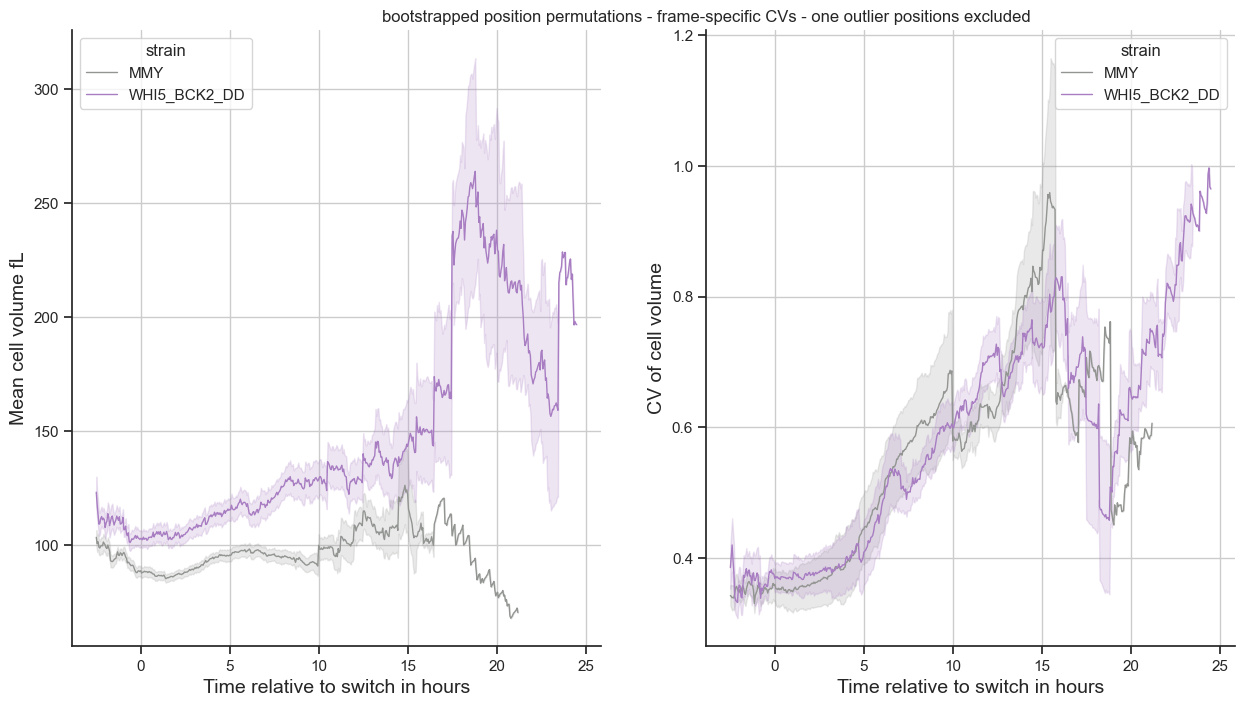

In [75]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 

sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(15, 8) )
S = sns.lineplot(data = bootstrapped_cv_df,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="bs_mean_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="bs_CV_sys_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )

S.set_title("bootstrapped position permutations - frame-specific CVs - one outlier positions excluded", fontsize = 12, x= 0)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
sns.despine(ax = ax1)
sns.despine(ax = ax2)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\bs_post_switch_CVs_excludingrep2pos5.svg')

# ***Revision1: For every frame, bootstrapping permutations of positions and calculating frame-specific CVs.*** 

In [76]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

seed = 42
n_iterations = 100
all_records = []

for strain in tqdm(chosen_strains_df.strain.unique(), desc='strains'):
    strain_df = chosen_strains_df[chosen_strains_df['strain'] == strain]

    for frame in tqdm(strain_df.frame_i.unique(), desc=f'{strain} frames', leave=False):
        frame_df = strain_df[strain_df['frame_i'] == frame]
        pos_list = frame_df.unique_pos_rep_id.unique()
        n_pos    = len(pos_list)

        # Extract volume to numpy once
        vol_arr = frame_df['combined_mother_bud_volume'].to_numpy(dtype=np.float64)
        pos_arr = frame_df['unique_pos_rep_id'].to_numpy()

        # Build pos -> local row indices lookup once
        pos_to_rows = {pos: np.where(pos_arr == pos)[0] for pos in pos_list}

        for i in range(n_iterations):
            rng           = np.random.default_rng(seed + i)
            boot_pos_idx  = rng.integers(0, n_pos, size=n_pos)
            resampled_pos = pos_list[boot_pos_idx]

            row_idx  = np.concatenate([pos_to_rows[p] for p in resampled_pos])
            boot_vol = vol_arr[row_idx]

            mean_v = boot_vol.mean()
            std_v  = boot_vol.std()
            cv_v   = std_v / mean_v

            all_records.append({
                'strain':              strain,
                'frame_i':             frame,
                'iteration':           i,
                'pos_list':            resampled_pos,
                'bs_mean_vol_frame':   mean_v,
                'bs_stdev_vol_frame':  std_v,
                'bs_CV_sys_vol_frame': cv_v,
            })

bootstrapped_cv_df = pd.DataFrame(all_records)
bootstrapped_cv_df.sort_values(by=['strain', 'iteration', 'frame_i'], inplace=True)
display(bootstrapped_cv_df.head(10))

strains: 100%|██████████| 2/2 [00:10<00:00,  5.07s/it]


,strain,frame_i,iteration,pos_list,bs_mean_vol_frame,bs_stdev_vol_frame,bs_CV_sys_vol_frame
0,MMY,0,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",108.562103,36.556450,0.336733
100,MMY,1,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",103.512788,36.413080,0.351774
200,MMY,2,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",105.947697,39.290798,0.370851
300,MMY,3,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",104.538781,37.905237,0.362595
400,MMY,4,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4, Position_2_Rep_4, Position_4_Rep_4, Position_4_Rep_3, Position_5_Rep_1, Position_6_Rep_4, Position_1_Rep_3, Position_4_Rep_3, Position_7_Rep_2, Position_7_Rep_1, Position_4_Rep_5, Position_4_Rep_4, Position_9_Rep_3, Position_8_Rep_2, Position_6_Rep_4, Position_5_Rep_3, Position_9_Rep_2, Position_1_Rep_3, Position_9_Rep_1, Position_4_Rep_1, Position_6_Rep_3, Position_2_Rep_5, Position_3_Rep_1, Position_1_Rep_5, Position_6_Rep_4]",104.090409,38.260442,0.367569
500,MMY,5,0,"[Position_4_Rep_1, Position_4_Rep_4, Position_9_Rep_3, Position_9_Rep_2, Position_9_Rep_2, Position_1_Rep_5, Position_4_Rep_1, Position_1_Rep_4, Position_8_Rep_1, Position_4_Rep_1, Position_5_Rep_3, Position_6_Rep_5, Position_2_Rep_4, Position_3_Rep_4,

In [77]:
bootstrapped_cv_df['frame_rel_to_nutrient_switch'] = bootstrapped_cv_df['frame_i'] - 50
bootstrapped_cv_df['time_rel_to_nutrient_switch_hours'] = (bootstrapped_cv_df['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'CV of cell volume')

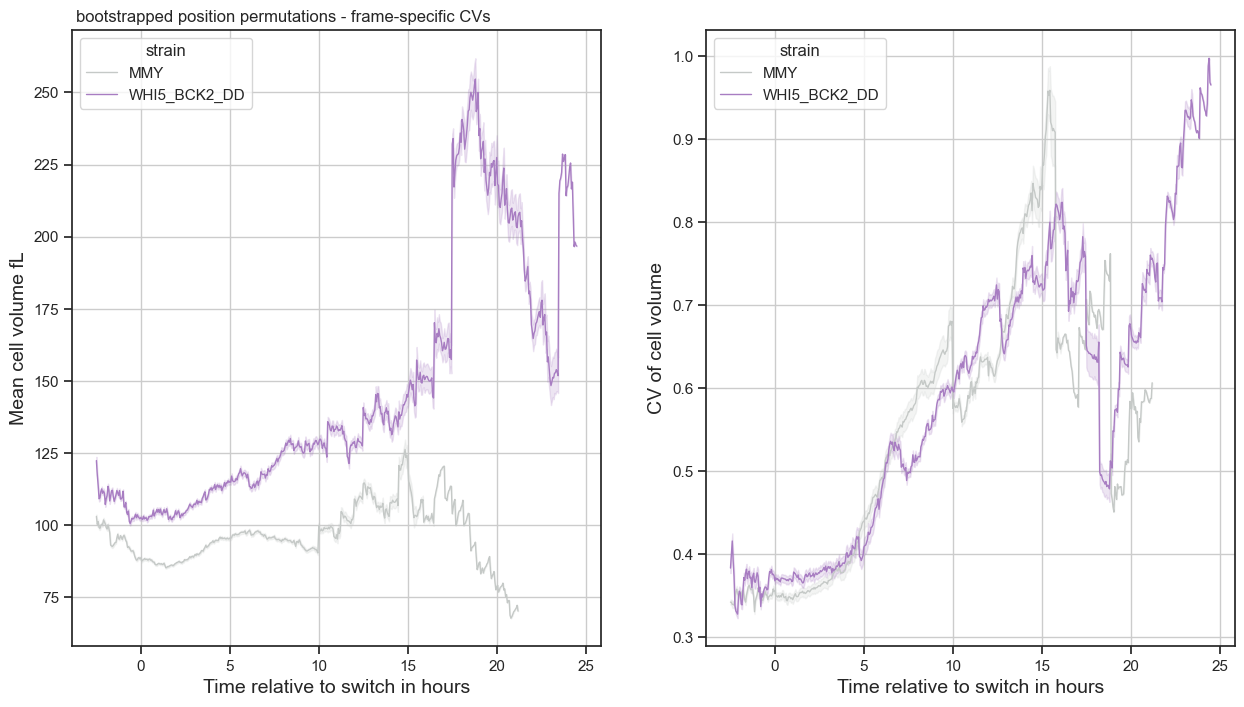

In [78]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(15, 8) )
S = sns.lineplot(data = bootstrapped_cv_df,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="bs_mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="bs_CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )

S.set_title("bootstrapped position permutations - frame-specific CVs", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)

#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\bs_post_switch_CVs_microscopy')

# ***Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions for every frame with all positions*** 

In [79]:
display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))

['Unnamed: 0',
 'frame_i',
 'time_seconds',
 'Cell_ID',
 'is_cell_dead',
 'is_cell_excluded',
 'x_centroid',
 'y_centroid',
 'was_manually_edited',
 'cell_cycle_stage',
 'generation_num',
 'relative_ID',
 'relationship',
 'emerg_frame_i',
 'division_frame_i',
 'is_history_known',
 'corrected_assignment',
 'cell_area_pxl',
 'cell_area_um2',
 'cell_vol_vox',
 'cell_vol_fl',
 'cell_vol_vox_downstream',
 'cell_vol_fl_downstream',
 '2d_label_count',
 'min_t',
 'max_t',
 'lifespan',
 'age',
 'frames_till_gone',
 'elongation',
 'Dia_Ph3_corrected_mean',
 'Dia_Ph3_raw_sum',
 'Dia_Ph3_corrected_amount',
 'Dia_Ph3_corrected_concentration',
 'max_frame_pos',
 'file',
 'selection_subset',
 'position',
 'directory',
 'time_seconds_rel',
 'Cell_ID_rel',
 'is_cell_dead_rel',
 'is_cell_excluded_rel',
 'x_centroid_rel',
 'y_centroid_rel',
 'was_manually_edited_rel',
 'cell_cycle_stage_rel',
 'generation_num_rel',
 'relative_ID_rel',
 'relationship_rel',
 'emerg_frame_i_rel',
 'division_frame_i_rel',
 '

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,cell_vol_fl_rel,combined_mother_bud_volume,f_pos_cell_id
0,0,1,0,S,135.471216,72.948291,208.419507,MMY_Position_1_Cell_1_Gen_2_Rep_1
1,1,1,0,S,131.569655,73.392645,204.962300,MMY_Position_1_Cell_1_Gen_2_Rep_1
2,2,1,0,G1,135.354415,76.026385,135.354415,MMY_Position_1_Cell_1_Gen_3_Rep_1
3,3,1,0,G1,136.988988,77.240173,136.988988,MMY_Position_1_Cell_1_Gen_3_Rep_1
4,4,1,0,G1,131.651731,76.639812,131.651731,MMY_Position_1_Cell_1_Gen_3_Rep_1
5,5,1,0,G1,131.117833,78.965256,131.117833,MMY_Position_1_Cell_1_Gen_3_Rep_1
6,6,1,0,G1,131.318354,82.143631,131.318354,MMY_Position_1_Cell_1_Gen_3_Rep_1
7,7,1,0,S,133.295539,0.881806,134.177345,MMY_Position_1_Cell_1_Gen_3_Rep_1
8,8,1,0,S,130.114343,2.567045,132.681388,MMY_Position_1_Cell_1_Gen_3_Rep_1
9,9,1,0,S,130.534535,3.559139,134.093674,MMY_Position_1_Cell_1_Gen_3_Rep_1


In [80]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
# nobud_df = nobud_df.drop(nobud_df[
#                          (nobud_df['position'] == "Position_3") & 
#                          (nobud_df['rep'] == 4)
#                          ].index)
# nobud_df = nobud_df.drop(nobud_df[
#                          (nobud_df['position'] == "Position_5") & 
#                          (nobud_df['rep'] == 2)
#                          ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [81]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            #& (select_strains_df['cell_cycle_stage'] == "G1")
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.8125,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.652,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,NaN,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,100.058842,61.854682,0.618183,269
500,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.1875,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.530,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,NaN,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,111.872760,42.725300,0.381910,121


np.float64(100.05884162686417)

In [82]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

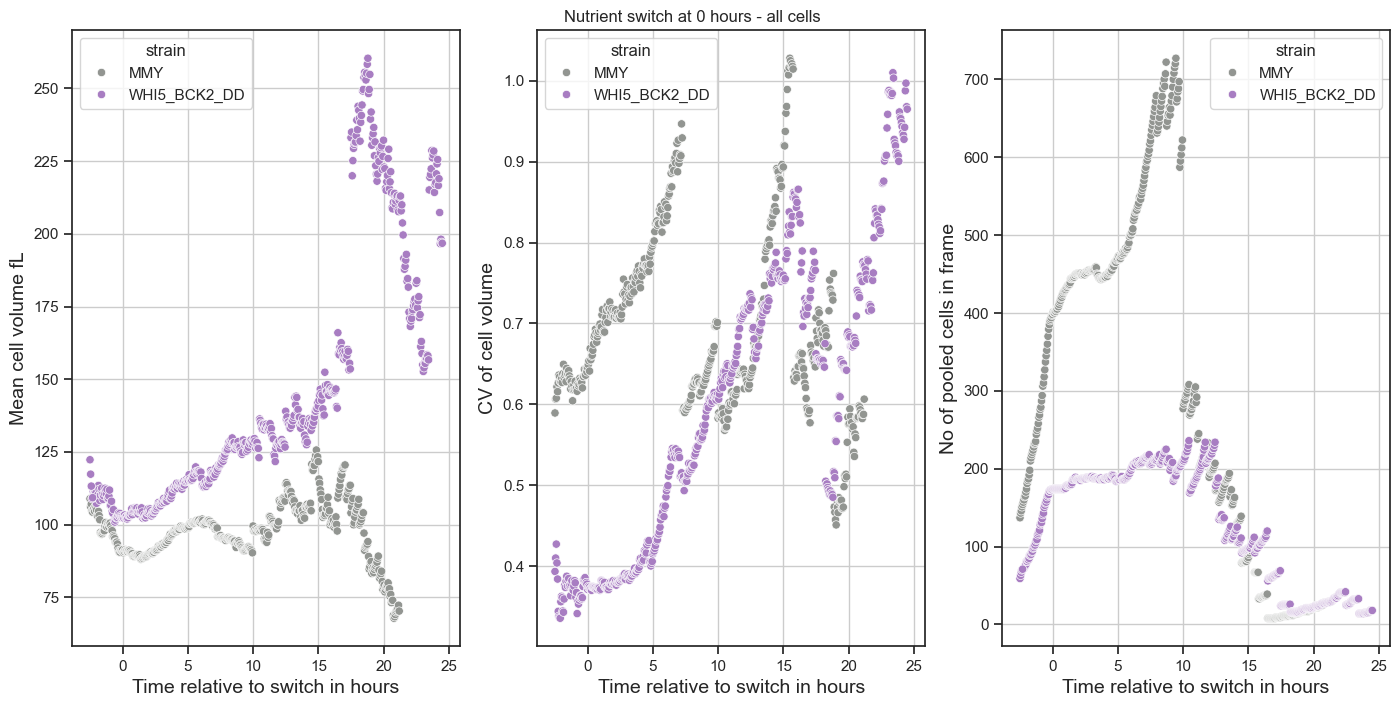

In [83]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

Text(0, 0.5, 'No of pooled cells in frame')

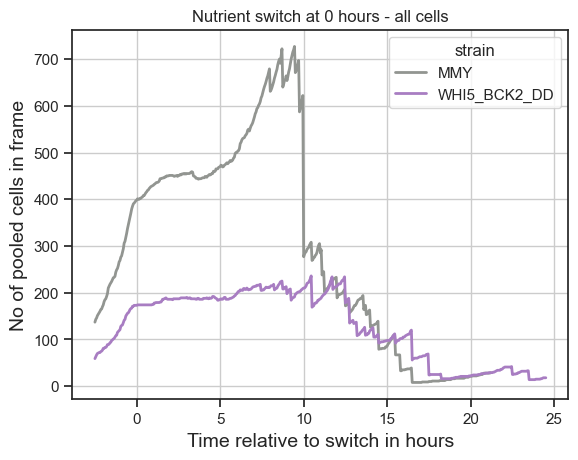

In [84]:
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours',
                y= "n_cells_in_frame_pooled", 
                hue = "strain", 
                linewidth = 2,
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells", fontsize = 12)
S.set_xlabel("Time relative to switch in hours", fontsize = 14)
S.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_pooled_cell_no_per_frame_all_pos.svg')

In [85]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1) & (select_strains_df["cell_cycle_stage"] == "G1")]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [86]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

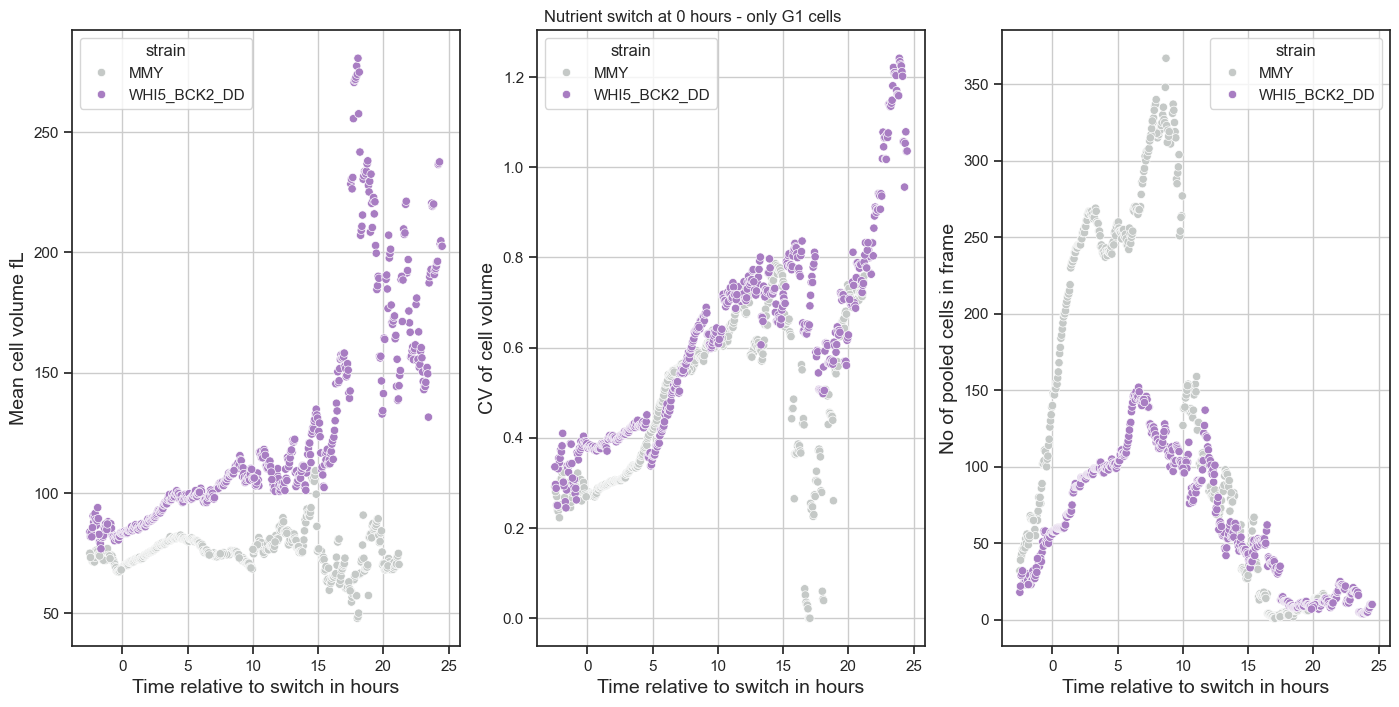

In [87]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - only G1 cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_onlyG1cells')

In [88]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1) & (select_strains_df["cell_cycle_stage"] != "G1")]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [89]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

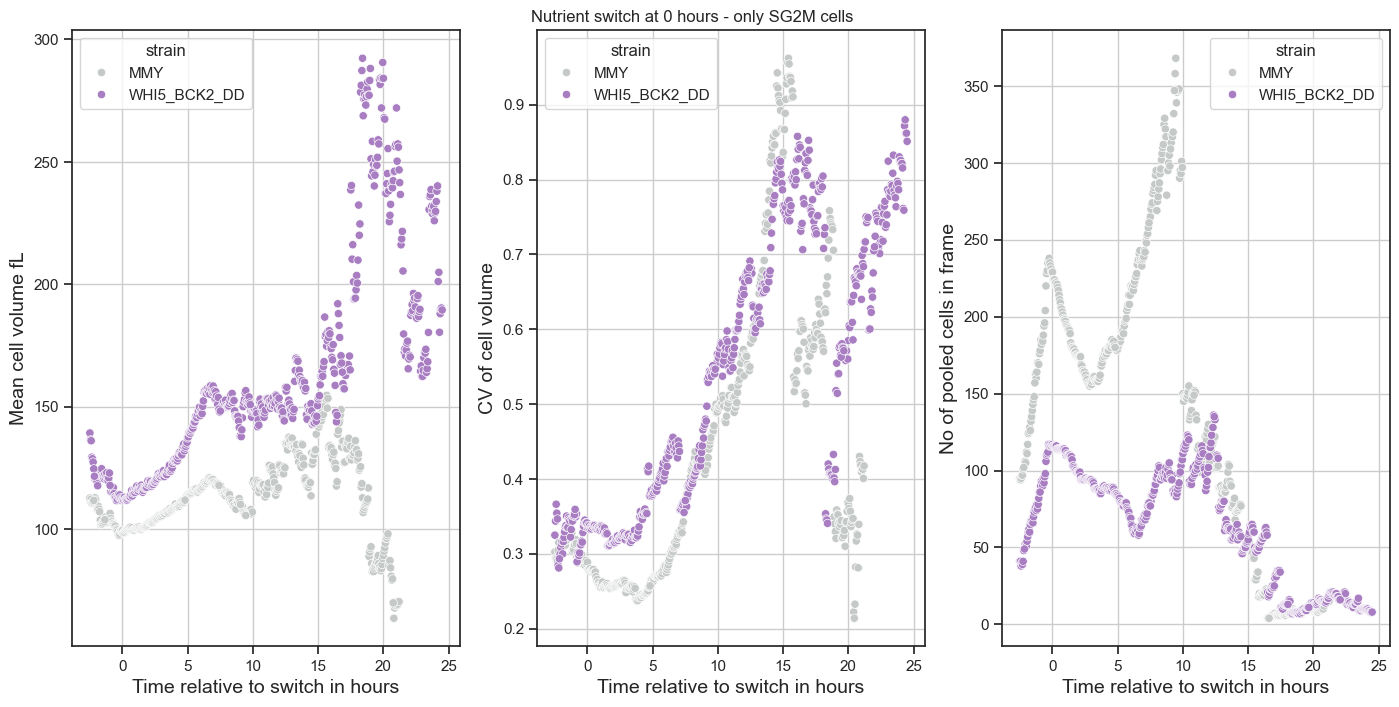

In [90]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - only SG2M cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_onlySG2Mcells')

# ***Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions OF A REP for every frame - REP 2 is an outlier*** 

In [91]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,cell_vol_fl_rel,combined_mother_bud_volume,f_pos_cell_id
0,0,1,0,S,135.471216,72.948291,208.419507,MMY_Position_1_Cell_1_Gen_2_Rep_1
1,1,1,0,S,131.569655,73.392645,204.962300,MMY_Position_1_Cell_1_Gen_2_Rep_1
2,2,1,0,G1,135.354415,76.026385,135.354415,MMY_Position_1_Cell_1_Gen_3_Rep_1
3,3,1,0,G1,136.988988,77.240173,136.988988,MMY_Position_1_Cell_1_Gen_3_Rep_1
4,4,1,0,G1,131.651731,76.639812,131.651731,MMY_Position_1_Cell_1_Gen_3_Rep_1
5,5,1,0,G1,131.117833,78.965256,131.117833,MMY_Position_1_Cell_1_Gen_3_Rep_1
6,6,1,0,G1,131.318354,82.143631,131.318354,MMY_Position_1_Cell_1_Gen_3_Rep_1
7,7,1,0,S,133.295539,0.881806,134.177345,MMY_Position_1_Cell_1_Gen_3_Rep_1
8,8,1,0,S,130.114343,2.567045,132.681388,MMY_Position_1_Cell_1_Gen_3_Rep_1
9,9,1,0,S,130.534535,3.559139,134.093674,MMY_Position_1_Cell_1_Gen_3_Rep_1


In [92]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []

import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [93]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.6520,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,NaN,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,99.707260,38.147552,0.382596,57
315,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.187500,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.5300,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,NaN,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,126.476970,50.986826,0.403131,42
685,155831,30,5400.0,1,0,0,409,261,0,S,1.0,10.0,mother,-1.0,15.0,0.0,0.0,3158.0,23.683610,123953.367188

np.float64(99.70726047490743)

In [94]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

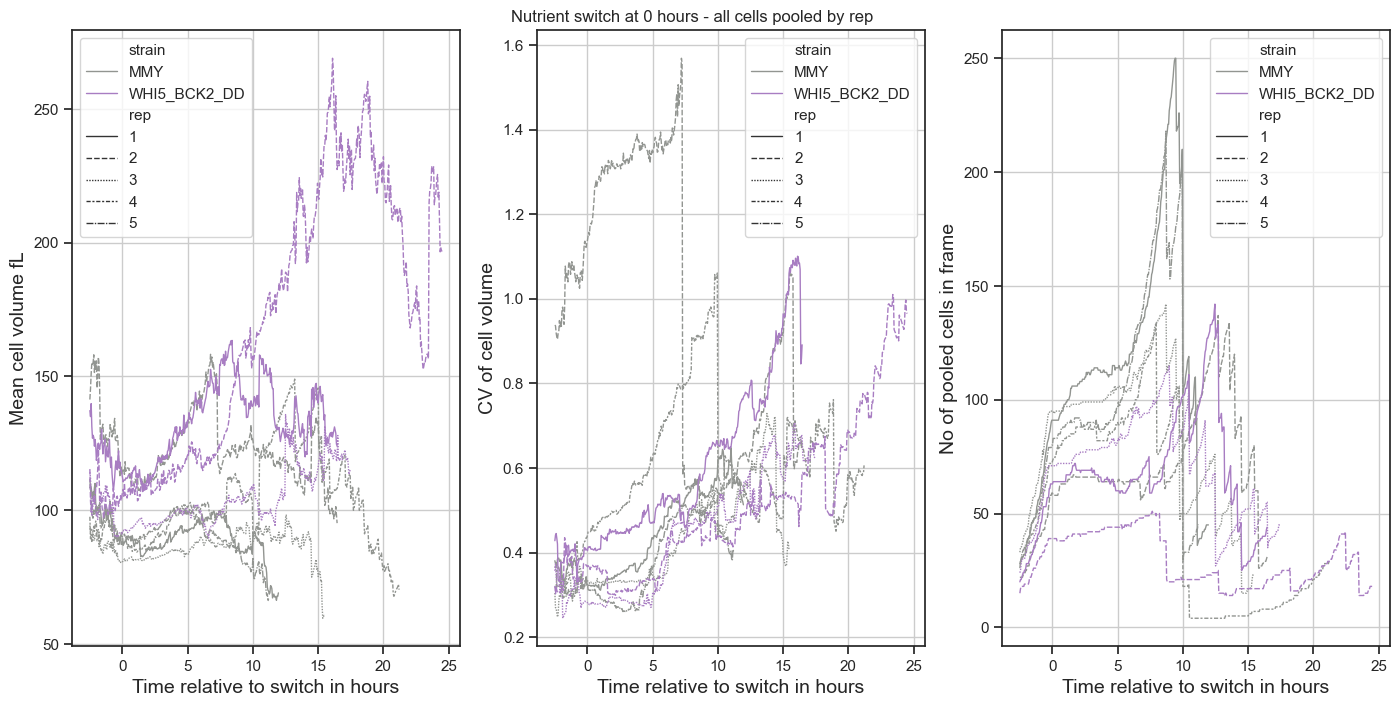

In [95]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                style = 'rep',
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                 style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                 style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

# ***Revision1: plotting frame-specific CVs after the nutrient switch by of each position of each rep - why is rep 2 an outlier*** 

In [96]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
# nobud_df = nobud_df.drop(nobud_df[(nobud_df['rep'] == 2)].index)
import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for pos in strain_df['position'].unique():
                pos_df  = strain_df[strain_df['position'] == pos]
                for frame in pos_df['frame_i'].unique():
                    frame_df = pos_df[pos_df['frame_i'] == frame]
                    frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                    frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                    frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                    frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                    # only append first row from frame_df to have only one row per frame in resulting df
                    j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [97]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['position'] == "Position_1")
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.810,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.65200,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,1.359988e+05,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,NaN,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,112.684863,36.158300,0.320880,3
284,3329,30,5400.0,1,0,0,508,135,0,S,1.0,22.0,mother,-1.0,16.0,0.0,0.0,2574.0,19.303867,85314.734375,55.408669,85314.734,55.408669,1.0,0.0,279.0,280.0,31.0,249.0,1.319704,945.668998,8050620.0,2434152.0,43930.887307,244,20220908,0,Position_2,Y:/Analysed Live cell microscopy data/20220908\Position_2\Images,5400.0,22.0,0.0,0.0,486.0,159.0,0.0,S,0.0,1.0,bud,30.0,-1.0,1.0,0.0,64.0,0.479972,241.865768,0.157083,241.86577,0.157083,1.0,30.0,279.0,250.0,1.0,249.0,2.470045,3236.125000,346760.0,207112.0,1.318491e+06,2641264.0,8397380.0,55.565752,0.419975,1.418714,19.303867,55.408669,56.827383,14.346658,38.736567,40,30.0,70.0,95.721033,1,1,1.0,15,MMY,SCD,switch_gen,True,True,True,False,False,True,1.418714,NaN,1,14.0,16.0,40.503925,30.0,55.565752,70.0,95.721033,NaN,1,MMY_Position_2_Cell_1_Gen_1_Rep_1,-0.016993,-0.000306,0,nutrient_switch,84.182376,21.814078,0.259129,8
539,9485,30,5400.0,1,0,0,517,259,0,S,1.0,13.0,mother,-1.0,6.0,0.0,0.0,3152.0,23.638613,128655.953125,83.557139,128655.950,83.557139,1.0,0.0,251.0,252.

np.float64(112.68486332712853)

In [98]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

c:\Users\timon\venvs\yagya_analysis\Lib\site-packages\seaborn\relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


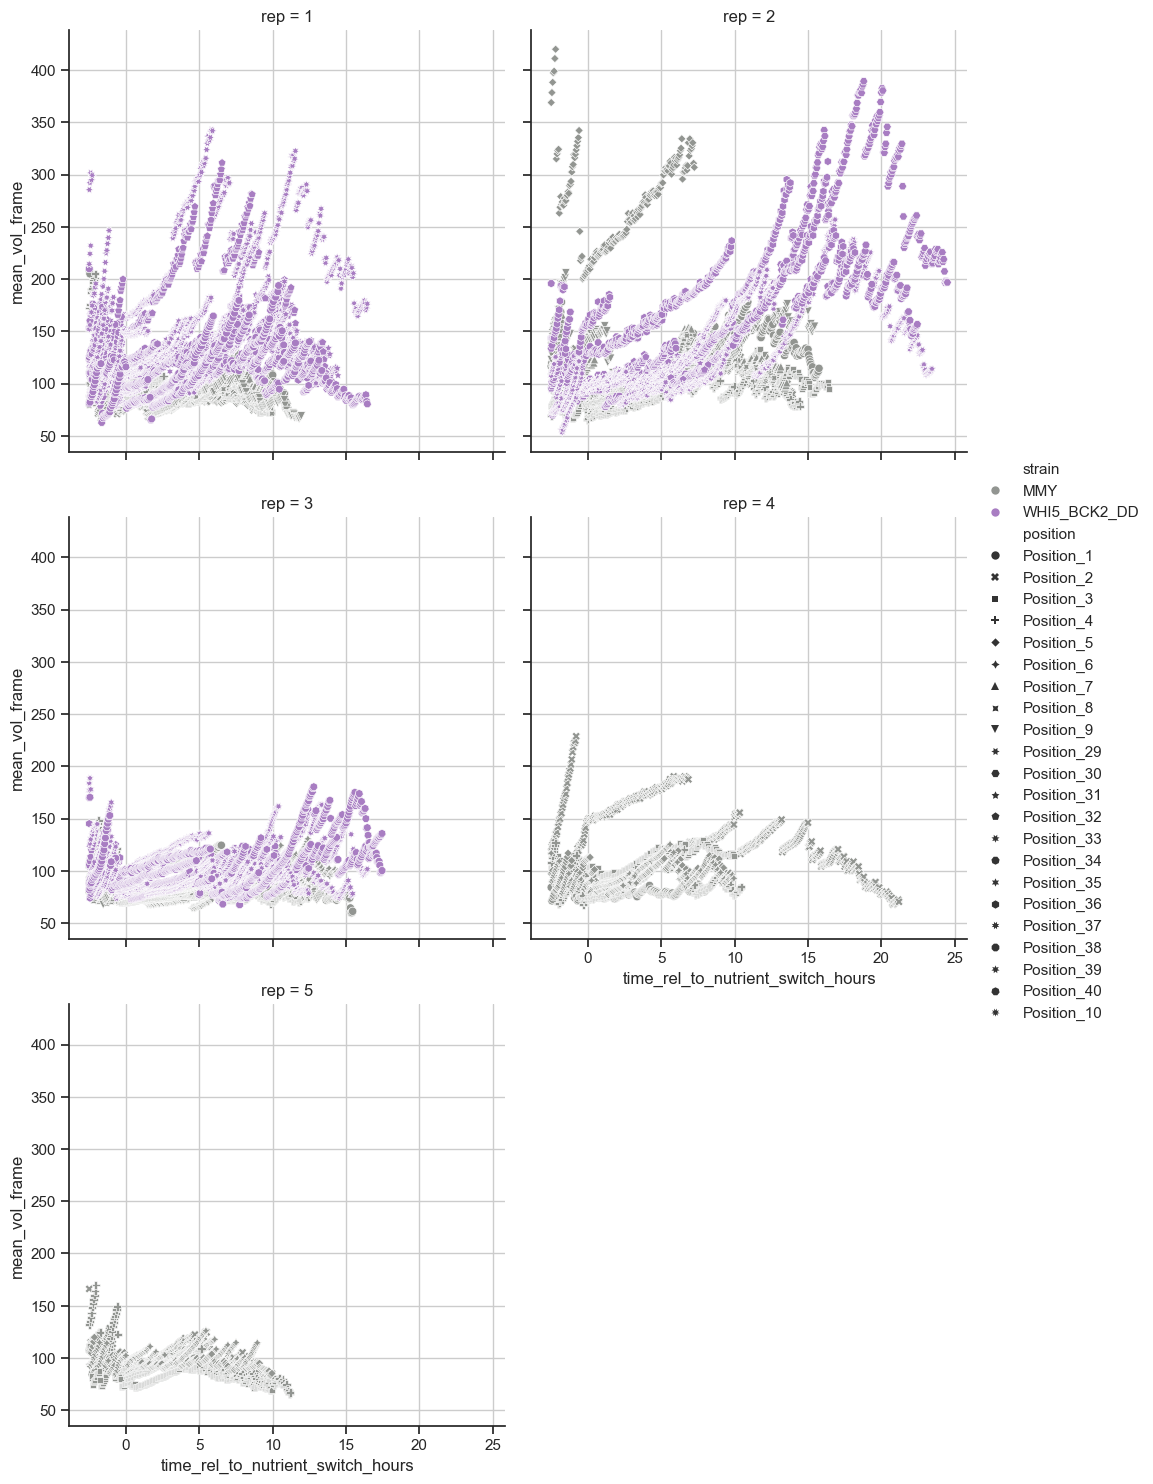

In [99]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
# S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x='time_rel_to_nutrient_switch_hours', 
#                 ax = ax1,
#                 y="mean_vol_frame", 
#                 hue = "strain", 
#                 style = 'pos',
#                 palette = palette
#                    )
S = sns.relplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="mean_vol_frame",
                style = 'position',
                col = 'rep',
                col_wrap = 2,
                hue = "strain", 
                palette = palette
                   )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x= 'time_rel_to_nutrient_switch_hours', 
#                 ax = ax3,
#                 y="n_cells_in_frame_pooled", 
#                 # style = 'rep',
#                 hue = "strain", 
#                 palette = palette
#                    )
# S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
# ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
# ax2.set_ylabel("CV of cell volume", fontsize = 14)
# ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

c:\Users\timon\venvs\yagya_analysis\Lib\site-packages\seaborn\relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


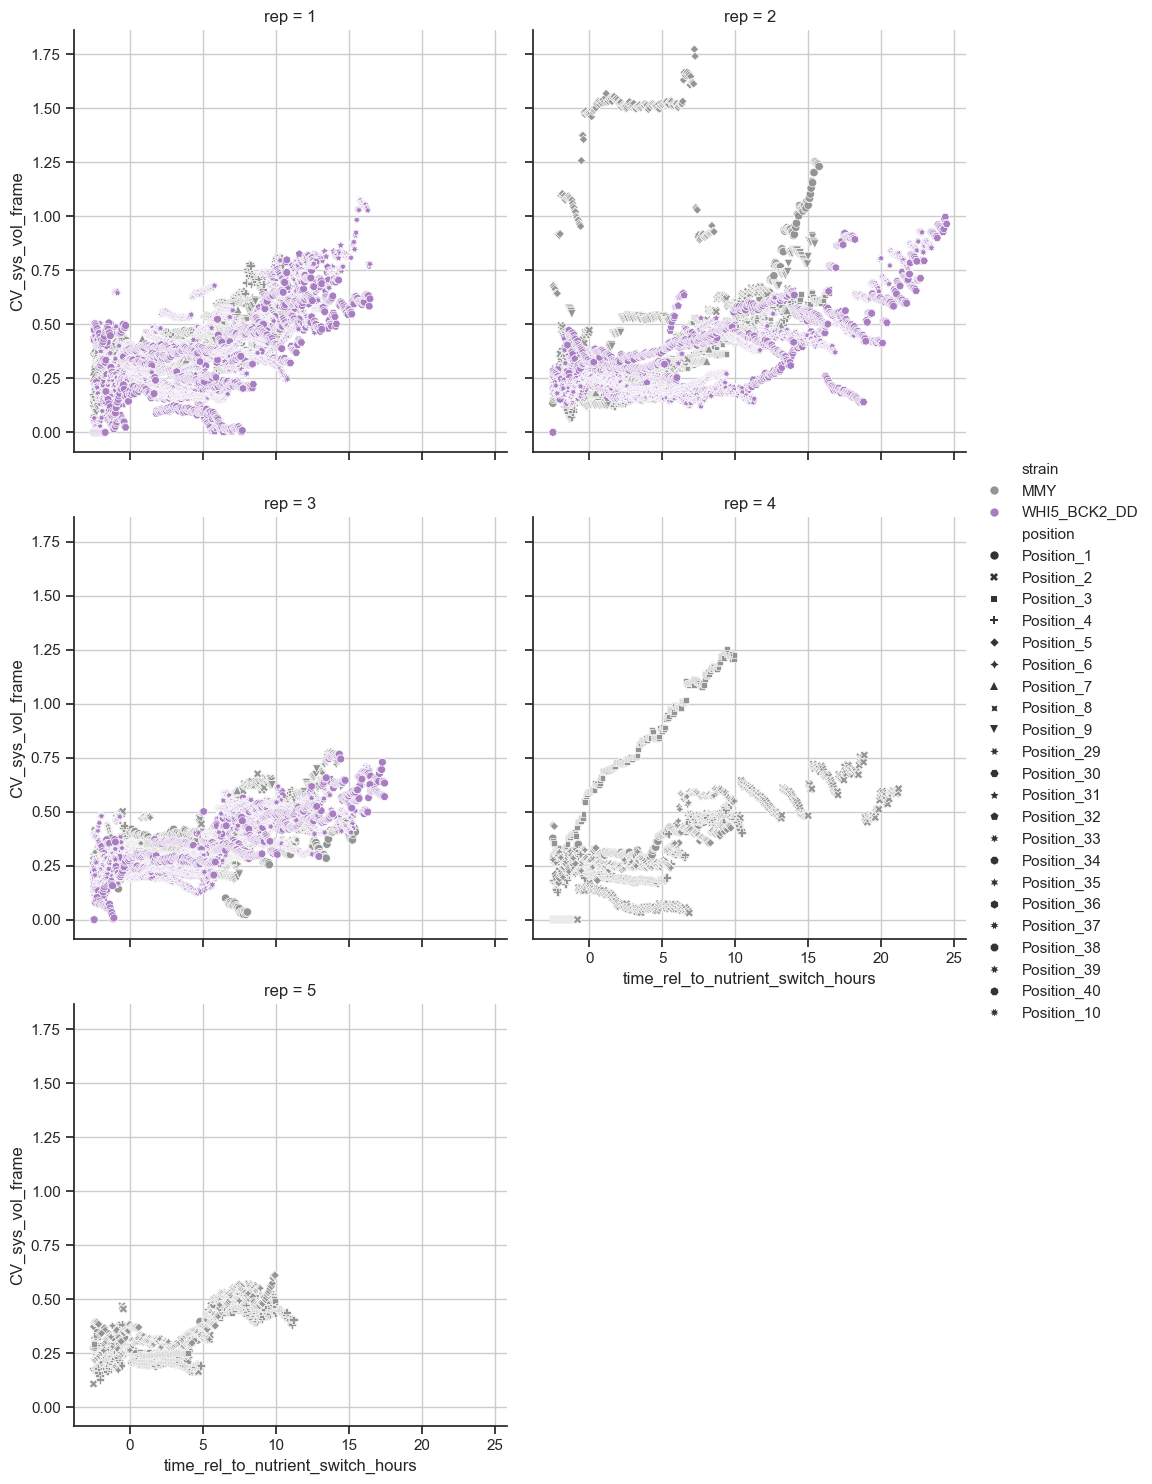

In [100]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
# S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x='time_rel_to_nutrient_switch_hours', 
#                 ax = ax1,
#                 y="mean_vol_frame", 
#                 hue = "strain", 
#                 style = 'pos',
#                 palette = palette
#                    )
S = sns.relplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                style = 'position',
                col = 'rep',
                col_wrap = 2,
                hue = "strain", 
                palette = palette
                   )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x= 'time_rel_to_nutrient_switch_hours', 
#                 ax = ax3,
#                 y="n_cells_in_frame_pooled", 
#                 # style = 'rep',
#                 hue = "strain", 
#                 palette = palette
#                    )
# S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
# ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
# ax2.set_ylabel("CV of cell volume", fontsize = 14)
# ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

In [101]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', None)
display(new_nobud_df_with_frame_specific_CVs[(new_nobud_df_with_frame_specific_CVs['rep'] == 4) &
                                            (new_nobud_df_with_frame_specific_CVs['position'] == "Position_3")])

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled,frame_rel_to_nutrient_switch,time_rel_to_nutrient_switch_hours
18024,15189,0,0.0,1,0,0,606,53,0,S,2.0,2.0,mother,-1.0,-1.0,0.0,0.0,3849.0,28.865806,159440.156250,103.550306,159440.16,103.550306,1.0,0.0,299.0,300.0,1.0,299.0,1.265807,1529.531826,14455042.0,5887168.0,56853.216735,249,20230406,0,Position_3,Y:/Analysed Live cell microscopy data/20230406\Position_3\Images,0.0,2.0,0.0,0.0,618.0,106.0,0.0,S,0.0,1.0,bud,-1.0,-1.0,0.0,0.0,1743.0,13.071733,51090.953125,33.181627,51090.953,33.181627,1.0,0.0,299.0,300.0,1.0,299.0,1.166921,1979.825014,7330753.0,3450835.0,103998.365432,9338003.0,21785795.0,136.731933,0.817452,4.391093,28.865806,103.550306,107.941399,7.822041,36.473039,10,0.0,10.0,177.596066,0,0,1.0,1,MMY,SCD,NaN,False,False,True,False,False,True,4.391093,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,MMY_Position_3_Cell_1_Gen_2_Rep_4,NaN,NaN,0,nutrient_switch,102.776747,37.404495,0.363939,7,-50,-2.50
18025,15190,1,180.0,1,0,0,607,53,0,S,2.0,2.0,mother,-1.0,-1.0,0.0,0.0,3865.0,28.985799,160164.500000,104.020740,160164.50,104.020740,1.0,0.0,299.0,300.0,2.0,298.0,1.269563,1314.667012,12961923.0,5081188.0,48847.835612,249,20230406,0,Position_3,Y:/Analysed Live cell microscopy data/20230406\Position_3\Images,180.0,2.0,0.0,0.0,619.0,108.0,0.0,S,0.0,1.0,bud,-1.0,-1.0,0.0,0.0,1894.0,14.204167,57782.652344,37.527631,57782.652,37.527631,1.0,0.0,299.0,300.0,2.0,298.0,1.170883,1757.498944,7190569.0,3328703.0,88700.056891,8409891.0,20152492.0,141.548371,0.817452,4.391093,28.865806,103.550306,107.941399,7.822041,36.473039,10,0.0,10.0,177.596066,0,0,2.0,2,MMY,SCD,NaN,False,False,True,False,False,True,4.391093,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,MMY_Position_3_Cell_1_Gen_2_Rep_4,4.816437,0.034027,0,nutrient_switch,105.023600,36.910589,0.351450,7,-49,-2.45
18026,15191,2,360.0,1,0,0,606,53,0,S,2.0,2.0,mother,-1.0,-1.0,0.0,0.0,3823.0,28.670818,157569.500000,102.335386,157569

# ***Revision1: we found two strong outlier positions in terms of CV of cell volume from previous cell: rep4 pos3 and rep2 pos5. The outlier behaviour comes from very large (8-10 micron) cells in these positions, so the large CV is real. Also, cell number is low.*** 

# ***Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions OF A REP for every frame - without the two outlier positions*** 

In [102]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [103]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.6520,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,NaN,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,99.707260,38.147552,0.382596,57
315,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.187500,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.5300,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,NaN,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,126.476970,50.986826,0.403131,42
685,155831,30,5400.0,1,0,0,409,261,0,S,1.0,10.0,mother,-1.0,15.0,0.0,0.0,3158.0,23.683610,123953.367188

np.float64(99.70726047490743)

In [104]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

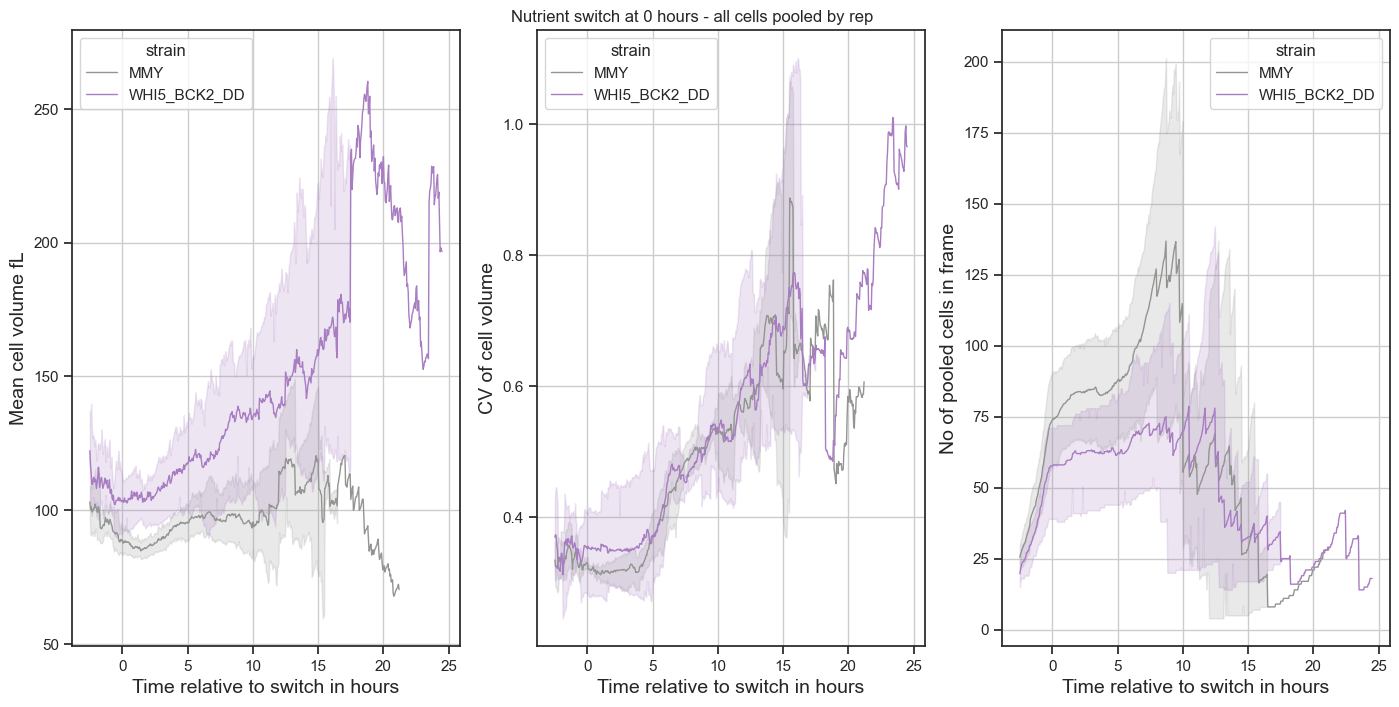

In [105]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                #style = 'rep',
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                # style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                # style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_repwiseCVs_microscopy_allcells_outlierPosRemoved')

# ***Revision1: calculating and plotting steady state frame-specific cell vol CVs for both media*** 

In [106]:
#calculating and plotting steady state frame-specific cell vol CVs for both media

In [107]:
display(SS_SCDnSCGE.columns.tolist())
select_strains_df = SS_SCDnSCGE[(SS_SCDnSCGE['strain'] == "MMY")|
                                (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'rel_vol_atframe', 'sys_vol_atframe','sys_vol_at_frame_inc_G1_cells', 'f_pos_cell_id', 'relationship', 'generation_num']].head(30))

['Unnamed: 0.2',
 'Unnamed: 0.1',
 'Unnamed: 0',
 'generation_num',
 'position',
 'Cell_ID',
 'growthmedium',
 'frame_i',
 'cell_cycle_stage',
 'relative_ID',
 'relationship',
 'cell_vol_fl',
 'emerg_frame_i',
 'division_frame_i',
 'len_G1',
 'rep',
 'strain',
 'Birth frame',
 'Birth vol fl',
 'last_G1_frame',
 'size_G1_end',
 'vol_added_G1',
 'Div frame',
 'Div vol fl',
 'len_S',
 'mother_size_emerg',
 'mother_size_div',
 'vol_added_S_mother',
 'bud_size_emerg',
 'bud_size_div',
 'vol_added_S_bud',
 'sys_size_emerg',
 'sys_size_div',
 'vol_added_S_tot',
 'total vol added',
 'time_seconds',
 'is_cell_dead',
 'complete_phase',
 'lenG1_mins',
 'G1_growthrate_flpermin',
 'delta_vol_fl',
 'delta_time_mins',
 'abs_growth_rate',
 'Birth_or_div_vol_fl',
 'rel_vol_atframe',
 'sys_vol_atframe',
 'delta_vol_sincePhaseStart_mother',
 'delta_vol_sincePhaseStart_sys',
 'norm_delta_vol_sincePhaseStart_mother',
 'norm_delta_vol_sincePhaseStart_sys',
 'bud_vol_atframe/mother_vol_atframe',
 'delta_vol_

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,rel_vol_atframe,sys_vol_atframe,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,relationship,generation_num
0,0,1.0,0,S,58.256695,92.927348,151.184043,151.184043,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
1,1,1.0,0,S,60.404339,93.706004,154.110342,154.110342,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
2,2,1.0,0,S,61.139191,94.112864,155.252054,155.252054,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
3,3,1.0,0,S,62.500215,95.679685,158.179900,158.179900,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
4,4,1.0,0,S,63.211776,97.265445,160.477221,160.477221,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
5,5,1.0,0,S,63.341337,99.942398,163.283735,163.283735,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
6,6,1.0,0,S,64.975784,102.084921,167.060705,167.060705,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
7,7,1.0,0,G1,67.499547,NaN,NaN,67.499547,SCD_MMY_Position_1_Cell_1.0_Gen_1_Date_20012021,mother,1.0
8,8,1.0,0,G1,67.411987,NaN,NaN,67.411987,SCD_MMY_Position_1_Cell_1.0_Gen_1_Date_20012021,mother,1.0
9,9,1.0,0,G1,68.835553,NaN,NaN,68.835553,SCD_MMY_Position_1_Cell_1.0_Gen_1_Date_20012021,mother,1.0


In [108]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []

import warnings
with warnings.catch_warnings(record=True):
    for medium in nobud_df['growthmedium'].unique():
        medium_df  = nobud_df[nobud_df['growthmedium'] == medium]
        for strain in medium_df['strain'].unique():
            strain_df  = medium_df[medium_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["sys_vol_at_frame_inc_G1_cells"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["sys_vol_at_frame_inc_G1_cells"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [109]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 1])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['growthmedium'] == "SCD")
                            & (select_strains_df['frame_i'] == 1)]
display(test_df.sys_vol_at_frame_inc_G1_cells.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,generation_num,position,Cell_ID,growthmedium,frame_i,cell_cycle_stage,relative_ID,relationship,cell_vol_fl,emerg_frame_i,division_frame_i,len_G1,rep,strain,Birth frame,Birth vol fl,last_G1_frame,size_G1_end,vol_added_G1,Div frame,Div vol fl,len_S,mother_size_emerg,mother_size_div,vol_added_S_mother,bud_size_emerg,bud_size_div,vol_added_S_bud,sys_size_emerg,sys_size_div,vol_added_S_tot,total vol added,time_seconds,is_cell_dead,complete_phase,lenG1_mins,G1_growthrate_flpermin,delta_vol_fl,delta_time_mins,abs_growth_rate,Birth_or_div_vol_fl,rel_vol_atframe,sys_vol_atframe,delta_vol_sincePhaseStart_mother,delta_vol_sincePhaseStart_sys,norm_delta_vol_sincePhaseStart_mother,norm_delta_vol_sincePhaseStart_sys,bud_vol_atframe/mother_vol_atframe,delta_vol_sinceG1Start,norm_delta_vol_sinceG1Start,Daughterhood_binary,time_in_stage_mins,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,complete_cycle,frames_since_cycle_start,vol_added_since_last_frame,delta_vol_norm_cellvol,experiment_type,alpha,alpha_G1_length_frames,ln_birth_or_div_vol,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
87,271,271,271.0,2.0,Position_1,4.0,SCD,1,S,1.0,mother,93.706004,-1.0,-1.0,NaN,20012021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,60.404339,154.110342,NaN,NaN,NaN,NaN,0.644615,NaN,NaN,0,3.0,154.110342,SCD_MMY_Position_1_Cell_4.0_Gen_2_Date_20012021,0.0,1.0,2.926300,0.018988,steady state,NaN,NaN,NaN,82.616140,33.454366,0.404937,64
181,25699,25699,25699.0,2.0,Position_20,2.0,SCD,1,S,5.0,mother,131.495677,-1.0,-1.0,NaN,20012021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,57.152393,188.648071,NaN,NaN,NaN,NaN,0.434633,NaN,NaN,0,3.0,188.648071,SCD_WHI5_BCK2_DD_Position_20_Cell_2.0_Gen_2_Date_20012021,0.0,1.0,3.013392,0.015974,steady state,NaN,NaN,NaN,96.968070,37.899369,0.390844,70
213,121010,121010,121010.0,2.0,Position_1,1.0,SCGE,1,G1,-1.0,mother,56.028432,-1.0,-1.0,NaN,23092021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,56.028432,SCGE_MMY_Position_1_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,0.152537,0.002722,steady state,NaN,NaN,NaN,66.320359,32.439308,0.489130,47
513,189839,189839,189839.0,2.0,Position_29,1.0,SCGE,1,S,6.0,mother,117.399729,-1.0,-1.0,NaN,23092021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,11.244754,128.644483,NaN,NaN,NaN,NaN,0.095782,NaN,NaN,0,3.0,128.644483,SCGE_WHI5_BCK2_DD_Position_29_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,-0.523383,-0.004068,steady state,NaN,NaN,NaN,87.733620,47.059441,0.536390,41


np.float64(82.61613960086679)

In [110]:
new_nobud_df_with_frame_specific_CVs['time_in_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_i']*3)/60
new_nobud_df_with_frame_specific_CVs.sort_values(by = 'frame_i', inplace = True)
display(new_nobud_df_with_frame_specific_CVs.head(20))

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,generation_num,position,Cell_ID,growthmedium,frame_i,cell_cycle_stage,relative_ID,relationship,cell_vol_fl,emerg_frame_i,division_frame_i,len_G1,rep,strain,Birth frame,Birth vol fl,last_G1_frame,size_G1_end,vol_added_G1,Div frame,Div vol fl,len_S,mother_size_emerg,mother_size_div,vol_added_S_mother,bud_size_emerg,bud_size_div,vol_added_S_bud,sys_size_emerg,sys_size_div,vol_added_S_tot,total vol added,time_seconds,is_cell_dead,complete_phase,lenG1_mins,G1_growthrate_flpermin,delta_vol_fl,delta_time_mins,abs_growth_rate,Birth_or_div_vol_fl,rel_vol_atframe,sys_vol_atframe,delta_vol_sincePhaseStart_mother,delta_vol_sincePhaseStart_sys,norm_delta_vol_sincePhaseStart_mother,norm_delta_vol_sincePhaseStart_sys,bud_vol_atframe/mother_vol_atframe,delta_vol_sinceG1Start,norm_delta_vol_sinceG1Start,Daughterhood_binary,time_in_stage_mins,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,complete_cycle,frames_since_cycle_start,vol_added_since_last_frame,delta_vol_norm_cellvol,experiment_type,alpha,alpha_G1_length_frames,ln_birth_or_div_vol,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled,time_in_hours
86,270,270,270.0,2.0,Position_1,4.0,SCD,0,S,1.0,mother,92.927348,-1.0,-1.0,NaN,20012021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,58.256695,151.184043,NaN,NaN,NaN,NaN,0.626906,NaN,NaN,0,0.0,151.184043,SCD_MMY_Position_1_Cell_4.0_Gen_2_Date_20012021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,83.377499,32.550240,0.390396,61,0.00
512,189838,189838,189838.0,2.0,Position_29,1.0,SCGE,0,S,6.0,mother,118.315411,-1.0,-1.0,NaN,23092021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,10.852455,129.167866,NaN,NaN,NaN,NaN,0.091725,NaN,NaN,0,0.0,129.167866,SCGE_WHI5_BCK2_DD_Position_29_Cell_1.0_Gen_2_Date_23092021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,91.507627,50.812218,0.555279,39,0.00
212,121009,121009,121009.0,2.0,Position_1,1.0,SCGE,0,G1,-1.0,mother,55.875895,-1.0,-1.0,NaN,23092021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,55.875895,SCGE_MMY_Position_1_Cell_1.0_Gen_2_Date_23092021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,73.937696,35.026017,0.473723,42,0.00
180,25698,25698,25698.0,2.0,Position_20,2.0,SCD,0,S,5.0,mother,131.888886,-1.0,-1.0,NaN,20012021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,53.745793,185.634679,NaN,NaN,NaN,NaN,0.407508,NaN,NaN,0,0.0,185.634679,SCD_WHI5_BCK2_DD_Position_20_Cell_2.0_Gen_2_Date_20012021,0.0,0.0,NaN,NaN,steady state,NaN,NaN,NaN,98.457389,37.422897,0.380092,67,0.00
513,189839,189839,189839.0,2.0,Position_29,1.0,SCGE,1,S,6.0,mother,117.399729,-1.0,-1.0,NaN,23092021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,11.244754,128.644483,NaN,NaN,NaN,NaN,0.095782,NaN,NaN,0,3.0,128.644483,SCGE_WHI5_BCK2_DD_Position_29_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,-0.523383,-0.004068,steady state,NaN,NaN,NaN,87.733620,47.059441,0.536390,41,0.05
213,121010,121010,121010.0,2.0,Position_1,1.0,SCGE,1,G1,-1.0,mother,56.028432,-1.0,-1.0,NaN,23092021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,56.028432,SCGE_MMY_Position_1_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,0.152537,0.002722,steady state,NaN,NaN,NaN,66.320359,32.439308,0.489130,47,0.05
181,25699,25699,25699.0,2.0,Position_20,2.0,SCD,1,S,5.0,mother,131.495677,-1.0,-1.0,NaN,20012021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,57.152393,188.648071,NaN,NaN,NaN,NaN,0.434

Text(0, 0.5, 'No of pooled cells in frame')

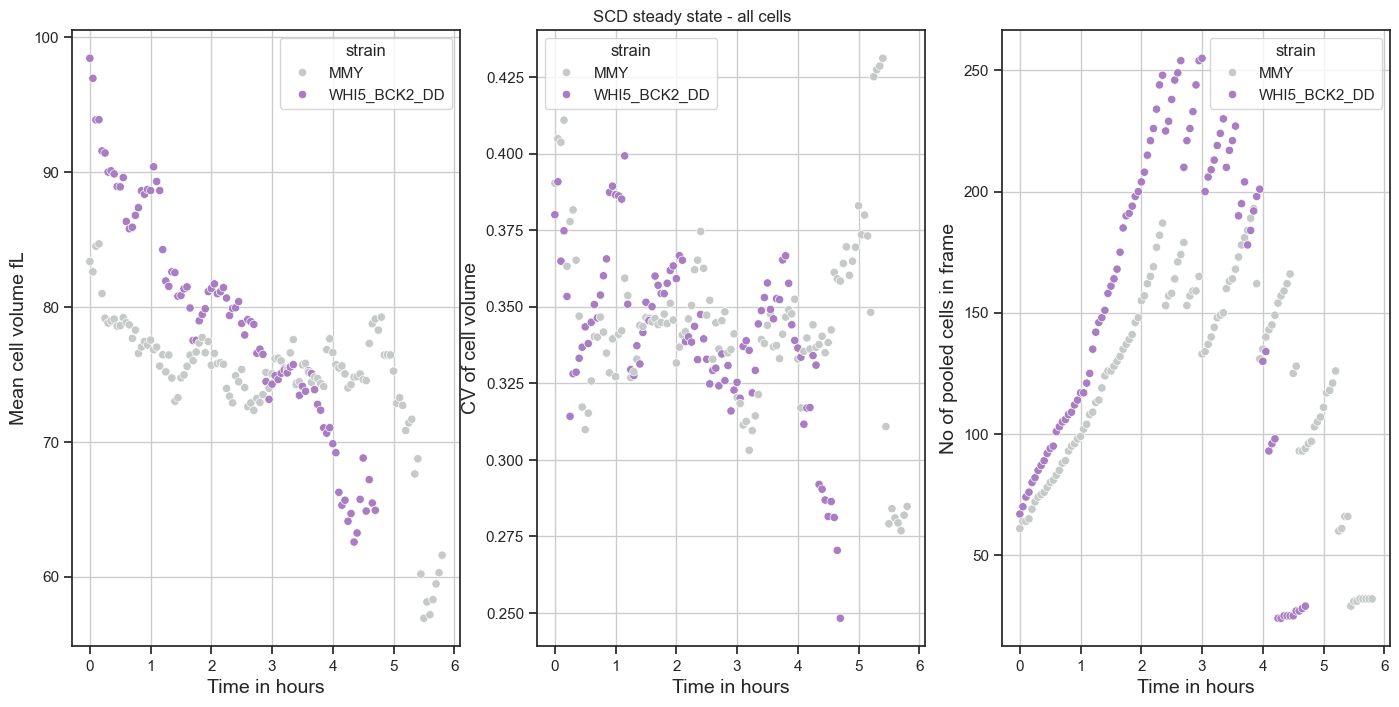

In [111]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x='time_in_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x= 'time_in_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x= 'time_in_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("SCD steady state - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time in hours", fontsize = 14)
ax2.set_xlabel("Time in hours", fontsize = 14)
ax3.set_xlabel("Time in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

Text(0, 0.5, 'No of pooled cells in frame')

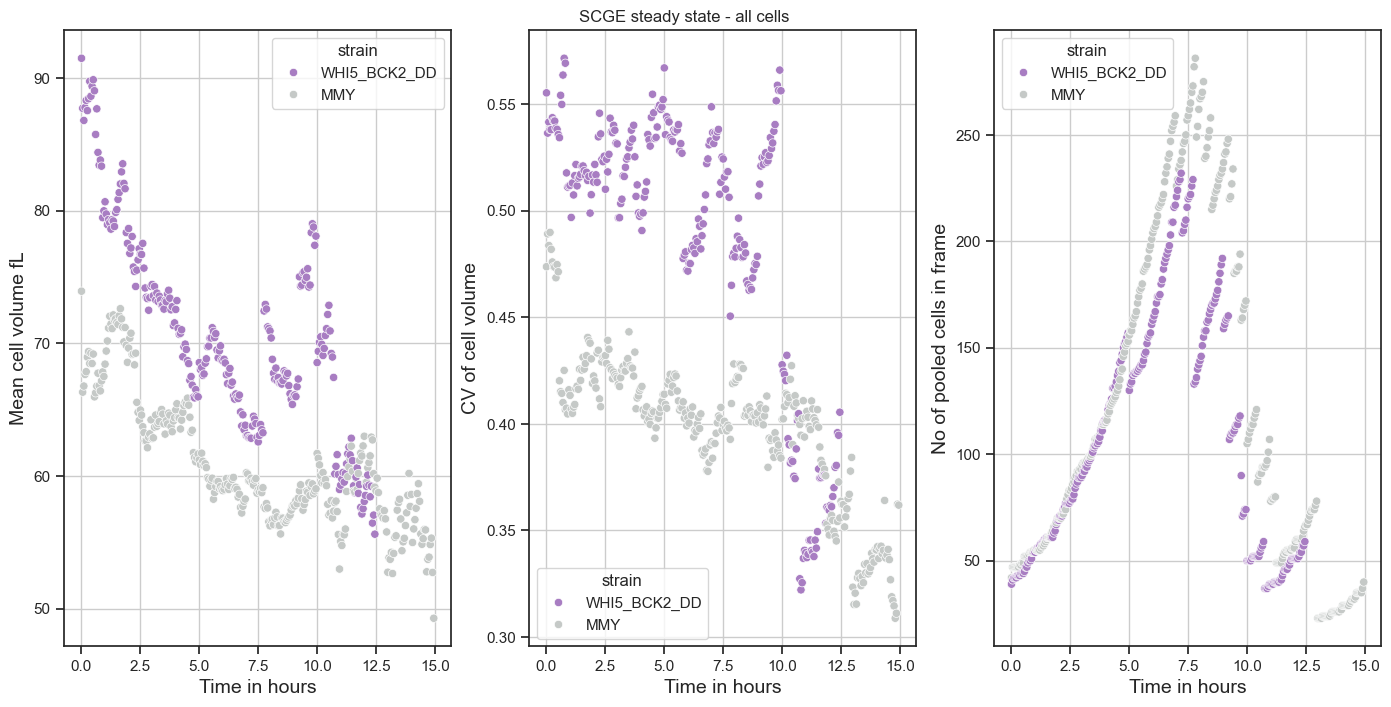

In [112]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x='time_in_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x= 'time_in_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x= 'time_in_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("SCGE steady state - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time in hours", fontsize = 14)
ax2.set_xlabel("Time in hours", fontsize = 14)
ax3.set_xlabel("Time in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

# ***Revision1: Size control plots for switchers and first daughters of S/G2/M switchers - WT and DD*** 

In [113]:

######################################### filter for steady state cells with complete G1s only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]

In [114]:
# display(overall_df_with_rel_and_switch_info.S_switch_cells_daughter_wave.dtype)

In [115]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                      ]    
        

In [116]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]
        

In [117]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]
        

In [118]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth

In [119]:


###############################################  steadystate  #####################################################################

SCD_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCGE"]

#unique plotting df SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 
SCD_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCD_SS"
SCD_steadystate_daughters_plotting_df.rename(columns={"Birth_or_div_vol_fl": "birth_or_div_vol", "vol_added_G1": "phase_volume_growth"}, inplace = True)

#unique plotting df SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)
SCGE_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCGE_SS"
SCGE_steadystate_daughters_plotting_df.rename(columns={"Birth_or_div_vol_fl": "birth_or_div_vol", "vol_added_G1": "phase_volume_growth"}, inplace = True)

##################################################  nutrient switch  ###################################################################

# unique plotting df nutrient switch firstSG2M_daughters
unique_f_pos_cell_id_3 = []
for fposid in ((firstSG2M_daughters_df['f_pos_cell_id']).unique()):
    fposid_df = firstSG2M_daughters_df[firstSG2M_daughters_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
firstSG2M_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
firstSG2M_daughters_plotting_df['plotting_col_ref'] = "firstSG2M_daughters"

# unique plotting df nutrient switch G1_switchers
unique_f_pos_cell_id_4 = []
for fposid in ((G1_switchers_switchcycle_df['f_pos_cell_id']).unique()):
    fposid_df = G1_switchers_switchcycle_df[G1_switchers_switchcycle_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_4.append(fposid_df.iloc[:1])
G1_switchers_switchcycle_plotting_df = pd.concat(unique_f_pos_cell_id_4).reset_index(drop = True)
G1_switchers_switchcycle_plotting_df['plotting_col_ref'] = "G1_switchers"

# unique plotting df nutrient switch SG2M_switchers
unique_f_pos_cell_id_6 = []
for fposid in ((SG2M_switchers_switchcycle_df['f_pos_cell_id']).unique()):
    fposid_df = SG2M_switchers_switchcycle_df[SG2M_switchers_switchcycle_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_6.append(fposid_df.iloc[:1])
SG2M_switchers_switchcycle_plotting_df = pd.concat(unique_f_pos_cell_id_6).reset_index(drop = True)
SG2M_switchers_switchcycle_plotting_df['plotting_col_ref'] = "SG2M_switchers"


figure_plotting_df = pd.concat([SCD_steadystate_daughters_plotting_df, SCGE_steadystate_daughters_plotting_df, firstSG2M_daughters_plotting_df, G1_switchers_switchcycle_plotting_df, SG2M_switchers_switchcycle_plotting_df]).reset_index(drop = True)


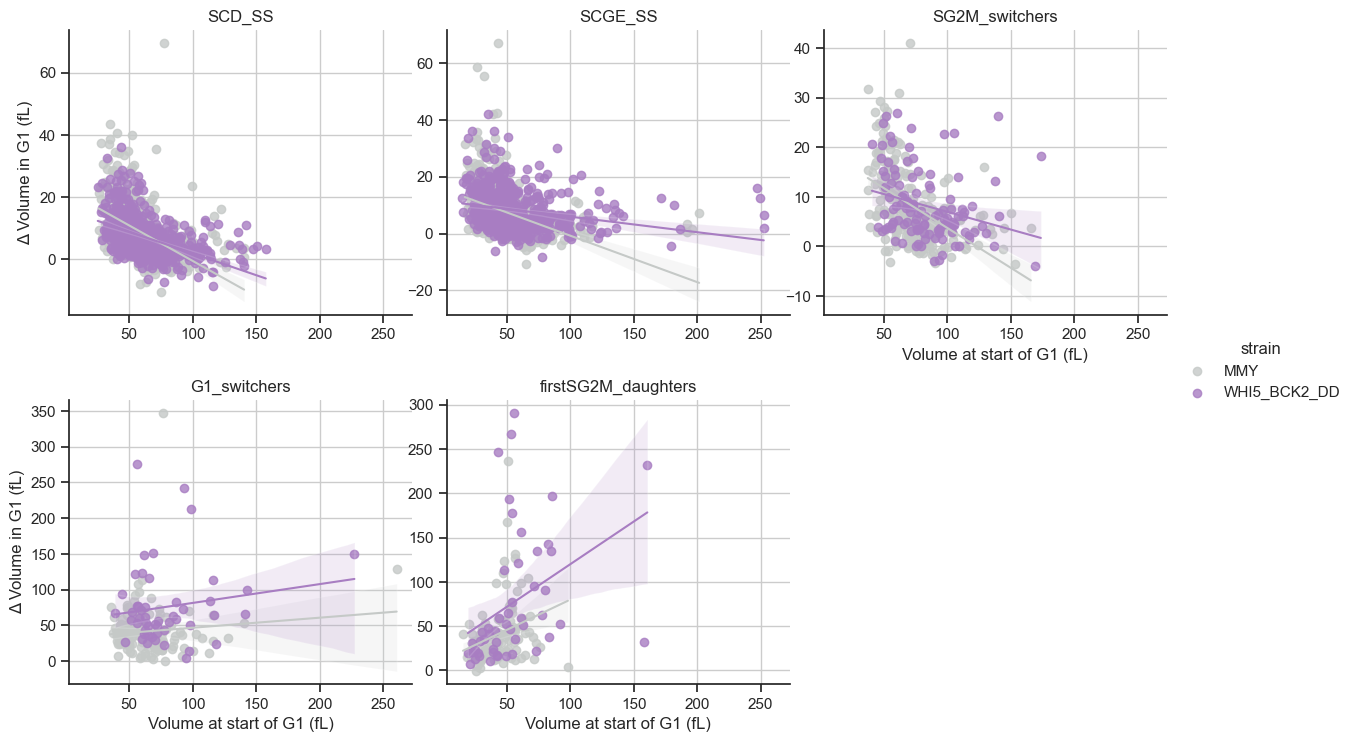

In [120]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df, 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 3,
                  sharey =False,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.regplot, 
      "birth_or_div_vol",
      "phase_volume_growth")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set()
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Volume at start of G1 (fL)", "Δ Volume in G1 (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_sizecontrol_categoryspecific.svg')





plt.show()

In [121]:
bins = np.linspace(0, figure_plotting_df.birth_or_div_vol.max(), 10)
figure_plotting_df['birth_vol_bin'] = np.digitize(np.array(figure_plotting_df.birth_or_div_vol), bins)
display(bins)
bin_labels = []

for lowerlimit in bins:
    bin_center = lowerlimit + 14.470755217969167
    bin_labels.append(bin_center)

# display(bin_labels)
# display((figure_plotting_df["birth_vol_bin"].unique()))
for bin_num in (figure_plotting_df["birth_vol_bin"].unique()):
    bin_center = bin_labels[bin_num-1]
    figure_plotting_df.loc[(figure_plotting_df["birth_vol_bin"] == bin_num), "bin_center"] = bin_center.round()
# display(figure_plotting_df[["birth_vol_bin", "bin_center"]].head(20))


array([  0.        ,  28.94151044,  57.88302087,  86.82453131,
       115.76604174, 144.70755218, 173.64906262, 202.59057305,
       231.53208349, 260.47359392])

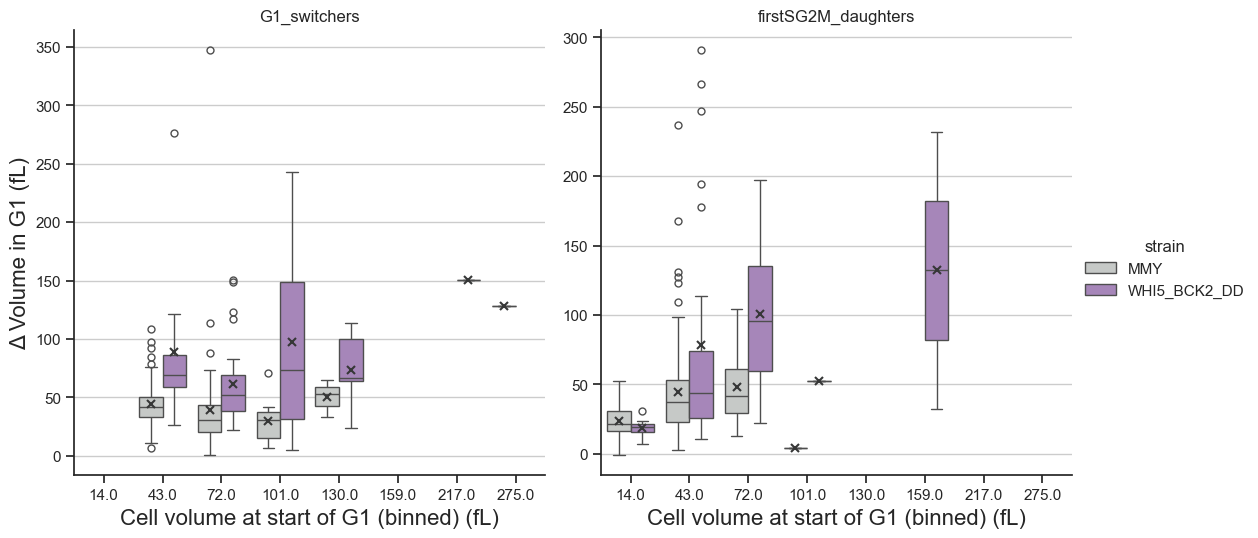

In [122]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.catplot(figure_plotting_df[(figure_plotting_df["plotting_col_ref"] == "G1_switchers") | 
                                    (figure_plotting_df["plotting_col_ref"] == "firstSG2M_daughters")], 
                kind = "box",
                x =  "bin_center",
                y = "phase_volume_growth",
                  col = "plotting_col_ref", 
                  col_order =[ 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 5.5,
                  col_wrap = 2,
                  sharey =False,
                  sharex = True,
                showmeans = True,
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                  # aspect  =1,
                  # margin_titles = True
                 )

# b.map_dataframe(sns.swarmplot,
#                 x =  "birth_vol_bin",
#                 y = "phase_volume_growth",
#                 hue = "strain",
#                   dodge = True,
#                   size = 1,
#                 palette = palette
#                   # margin_titles = True
#                  )



# b.map_dataframe(sns.barplot, 
#                 "birth_vol_bin",
#                 "phase_volume_growth", alpha = 0.5)
        



# # b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}")
# b.fig.subplots_adjust(top=0.9)
# # b.fig.suptitle("size control")
# b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
# b.set()
# b.add_legend()
# # ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Cell volume at start of G1 (binned) (fL)", "Δ Volume in G1 (fL)", fontsize = 16)
# # ax1.set_ylabel("G1 Length*Growth Rate")
# # ax1.set_ylim(-0.5,4)
# # ax1.set_xlim(2,6)
# #ax2.set_xscale("log")
# b.tick_params(axis='x', labelbottom=True)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_sizecontrol_binned_categoryspecific.png')





plt.show()

# ***Revision 2: Fig. R2 - size control plots***

In [165]:
# display((overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['cell_saw_switch_as_bud'] == False) & (overall_df_with_rel_and_switch_info['cell_saw_switch'] == True)]['post_switch_gen']).unique())


In [39]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                      ]    


In [40]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]
        

In [41]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_cycleafterswitchcycle_df  = selectedstrains_NS_plotting_df[((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]


In [42]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth


In [43]:


##################################################  nutrient switch  ###################################################################

# unique plotting df nutrient switch firstSG2M_daughters
unique_f_pos_cell_id_3 = []
for fposid in ((firstSG2M_daughters_df['f_pos_cell_id']).unique()):
    fposid_df = firstSG2M_daughters_df[firstSG2M_daughters_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
firstSG2M_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
firstSG2M_daughters_plotting_df['plotting_col_ref'] = "firstSG2M_daughters_cycleafterswitchcycle"

# unique plotting df nutrient switch G1_switchers
unique_f_pos_cell_id_4 = []
for fposid in ((G1_switchers_switchcycle_df['f_pos_cell_id']).unique()):
    fposid_df = G1_switchers_switchcycle_df[G1_switchers_switchcycle_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_4.append(fposid_df.iloc[:1])
G1_switchers_switchcycle_plotting_df = pd.concat(unique_f_pos_cell_id_4).reset_index(drop = True)
G1_switchers_switchcycle_plotting_df['plotting_col_ref'] = "G1_switchers_switchcycle"

# unique plotting df nutrient switch SG2M_switchers
unique_f_pos_cell_id_6 = []
for fposid in ((SG2M_switchers_cycleafterswitchcycle_df['f_pos_cell_id']).unique()):
    fposid_df = SG2M_switchers_cycleafterswitchcycle_df[SG2M_switchers_cycleafterswitchcycle_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_6.append(fposid_df.iloc[:1])
SG2M_switchers_cycleafterswitchcycle_plotting_df = pd.concat(unique_f_pos_cell_id_6).reset_index(drop = True)
SG2M_switchers_cycleafterswitchcycle_plotting_df['plotting_col_ref'] = "SG2M_switchers_cycleafterswitchcycle"


figure_plotting_df = pd.concat([firstSG2M_daughters_plotting_df, G1_switchers_switchcycle_plotting_df, SG2M_switchers_cycleafterswitchcycle_plotting_df]).reset_index(drop = True)


In [44]:
import numpy as np
import pandas as pd

# figure_plotting_df = pd.read_csv(r"figure_plotting_df_1.csv")
figure_plotting_df = figure_plotting_df[np.isin(figure_plotting_df['strain'], ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD"])].copy()

# Step 1: suggest bins per plotting_col_ref (no assignments here)
n_bins = 4
suggested_bin_edges_by_col = {}
suggested_bin_labels_by_col = {}

for col_ref, idx in figure_plotting_df.groupby('plotting_col_ref').groups.items():
    vals = figure_plotting_df.loc[idx, 'birth_or_div_vol'].dropna().to_numpy()
    if len(vals) == 0:
        print(f"{col_ref}: no valid birth_or_div_vol values, skipping.")
        continue

    # Percentile-based edges from this column's own distribution
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(vals, quantiles)

    # Ensure strictly increasing edges to avoid pd.cut issues
    edges = np.array(edges, dtype=float)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-6

    labels = [f"{edges[i]:.1f}-{edges[i+1]:.1f}" for i in range(len(edges)-1)]

    suggested_bin_edges_by_col[col_ref] = edges
    suggested_bin_labels_by_col[col_ref] = labels

    print(f"\n{col_ref}")
    print("Suggested edges:", np.round(edges, 3))
    print("Suggested labels:", labels)

# Step 2: assign bin labels per row using each row's plotting_col_ref
figure_plotting_df['bin_info'] = np.nan

for col_ref, idx in figure_plotting_df.groupby('plotting_col_ref').groups.items():
    if col_ref not in suggested_bin_edges_by_col:
        continue
    edges = suggested_bin_edges_by_col[col_ref]
    labels = suggested_bin_labels_by_col[col_ref]

    figure_plotting_df.loc[idx, 'bin_info'] = pd.cut(
        figure_plotting_df.loc[idx, 'birth_or_div_vol'],
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=True
    ).astype(str)

# Quick check
for col_ref in figure_plotting_df['plotting_col_ref'].dropna().unique():
    print(f"\n{col_ref} bin counts:")
    print(figure_plotting_df.loc[figure_plotting_df['plotting_col_ref'] == col_ref, 'bin_info'].value_counts(dropna=False))

#save
figure_plotting_df.to_csv(r"figure_plotting_df_1.csv", index = False)



G1_switchers_switchcycle
Suggested edges: [ 26.438  52.288  63.05   77.066 260.474]
Suggested labels: ['26.4-52.3', '52.3-63.0', '63.0-77.1', '77.1-260.5']

SG2M_switchers_cycleafterswitchcycle
Suggested edges: [ 39.208  80.28   93.812 117.156 426.133]
Suggested labels: ['39.2-80.3', '80.3-93.8', '93.8-117.2', '117.2-426.1']

firstSG2M_daughters_cycleafterswitchcycle
Suggested edges: [ 15.66   32.67   44.819  58.042 207.873]
Suggested labels: ['15.7-32.7', '32.7-44.8', '44.8-58.0', '58.0-207.9']

firstSG2M_daughters_cycleafterswitchcycle bin counts:
bin_info
32.7-44.8     62
15.7-32.7     62
58.0-207.9    62
44.8-58.0     61
Name: count, dtype: int64

G1_switchers_switchcycle bin counts:
bin_info
77.1-260.5    80
63.0-77.1     80
26.4-52.3     80
52.3-63.0     80
Name: count, dtype: int64

SG2M_switchers_cycleafterswitchcycle bin counts:
bin_info
80.3-93.8      81
39.2-80.3      81
117.2-426.1    81
93.8-117.2     80
Name: count, dtype: int64


C:\Users\timon\AppData\Local\Temp\ipykernel_19760\4242923426.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['77.1-260.5' '63.0-77.1' '63.0-77.1' '63.0-77.1' '26.4-52.3' '26.4-52.3'
 '52.3-63.0' '63.0-77.1' '26.4-52.3' '52.3-63.0' '63.0-77.1' '26.4-52.3'
 '52.3-63.0' '52.3-63.0' '63.0-77.1' '63.0-77.1' '63.0-77.1' '63.0-77.1'
 '26.4-52.3' '63.0-77.1' '52.3-63.0' '77.1-260.5' '63.0-77.1' '77.1-260.5'
 '52.3-63.0' '26.4-52.3' '26.4-52.3' '52.3-63.0' '52.3-63.0' '63.0-77.1'
 '26.4-52.3' '52.3-63.0' '77.1-260.5' '63.0-77.1' '26.4-52.3' '77.1-260.5'
 '63.0-77.1' '63.0-77.1' '63.0-77.1' '77.1-260.5' '77.1-260.5' '52.3-63.0'
 '77.1-260.5' '77.1-260.5' '77.1-260.5' '63.0-77.1' '77.1-260.5'
 '63.0-77.1' '52.3-63.0' '63.0-77.1' '26.4-52.3' '26.4-52.3' '52.3-63.0'
 '63.0-77.1' '63.0-77.1' '77.1-260.5' '63.0-77.1' '26.4-52.3' '52.3-63.0'
 '26.4-52.3' '63.0-77.1' '26.4-52.3' '77.1-260.5' '77.1-260.5'
 '77.1-260

In [45]:
# Step 2: set manual bins, then assign bins/labels
# Starts from suggestions; edit values below as needed.
manual_bin_edges_by_col = {
    col_ref: edges.copy()
    for col_ref, edges in suggested_bin_edges_by_col.items()
}
def bin_edges_from_stepsize(step, n_bins, max_val):
    edges = np.arange(0, step * (n_bins + 1), step)
    if edges[-1] < max_val * 1.001:
        edges[-1] = max_val * 1.001
    return edges

manual_bin_edges_by_col['G1_switchers_switchcycle'] = bin_edges_from_stepsize(45, n_bins, figure_plotting_df[figure_plotting_df['plotting_col_ref'] == 'G1_switchers_switchcycle']['birth_or_div_vol'].max())
manual_bin_edges_by_col['SG2M_switchers_cycleafterswitchcycle'] = bin_edges_from_stepsize(60, n_bins, figure_plotting_df[figure_plotting_df['plotting_col_ref'] == 'SG2M_switchers_cycleafterswitchcycle']['birth_or_div_vol'].max())
manual_bin_edges_by_col['firstSG2M_daughters_cycleafterswitchcycle'] = bin_edges_from_stepsize(25, n_bins, figure_plotting_df[figure_plotting_df['plotting_col_ref'] == 'firstSG2M_daughters_cycleafterswitchcycle']['birth_or_div_vol'].max())

figure_plotting_df['birth_vol_bin'] = pd.Series(index=figure_plotting_df.index, dtype='Int64')
figure_plotting_df['bin_center'] = pd.Series(index=figure_plotting_df.index, dtype='Int64')
figure_plotting_df['bin_info'] = pd.Series(index=figure_plotting_df.index, dtype='object')

bin_edges_by_col = {}
bin_labels_by_col = {}

for col_ref, idx in figure_plotting_df.groupby('plotting_col_ref').groups.items():
    if col_ref not in manual_bin_edges_by_col:
        print(f"{col_ref}: missing manual bins, skipping.")
        continue

    bins = np.asarray(manual_bin_edges_by_col[col_ref], dtype=float)
    if len(bins) != (n_bins + 1):
        raise ValueError(f"{col_ref}: expected {n_bins + 1} edges, got {len(bins)}")
    if not np.all(np.diff(bins) > 0):
        raise ValueError(f"{col_ref}: bin edges must be strictly increasing")

    col_vals = figure_plotting_df.loc[idx, 'birth_or_div_vol'].fillna(0).to_numpy()
    bin_indices = np.digitize(col_vals, bins).clip(1, n_bins)

    bin_centers = np.round((bins[:-1] + bins[1:]) / 2).astype(int)
    bin_labels = [f"{int(bins[i])}-{int(bins[i+1])} fL" for i in range(n_bins)]

    figure_plotting_df.loc[idx, 'birth_vol_bin'] = bin_indices
    figure_plotting_df.loc[idx, 'bin_center'] = np.array(bin_centers)[bin_indices - 1]
    figure_plotting_df.loc[idx, 'bin_info'] = np.array(bin_labels)[bin_indices - 1]

    bin_edges_by_col[col_ref] = bins
    bin_labels_by_col[col_ref] = bin_labels

    print(f"Applied manual bins for {col_ref}: {np.round(bins, 2)}")
    counts = figure_plotting_df.loc[idx].groupby('bin_info').size()
    
    display(counts.reindex(bin_labels, fill_value=0))


display(figure_plotting_df[["plotting_col_ref", "birth_or_div_vol", "birth_vol_bin", "bin_info"]].head(20))

figure_plotting_df.to_csv(r"figure_plotting_df_1.csv", index=False)

Applied manual bins for G1_switchers_switchcycle: [  0.  45.  90. 135. 260.]


bin_info
0-45 fL        37
45-90 fL      230
90-135 fL      43
135-260 fL     10
dtype: int64

Applied manual bins for SG2M_switchers_cycleafterswitchcycle: [  0.  60. 120. 180. 426.]


bin_info
0-60 fL        14
60-120 fL     241
120-180 fL     53
180-426 fL     15
dtype: int64

Applied manual bins for firstSG2M_daughters_cycleafterswitchcycle: [  0.  25.  50.  75. 208.]


bin_info
0-25 fL       26
25-50 fL     121
50-75 fL      73
75-208 fL     27
dtype: int64

,plotting_col_ref,birth_or_div_vol,birth_vol_bin,bin_info
0,firstSG2M_daughters_cycleafterswitchcycle,50.877556,3,50-75 fL
1,firstSG2M_daughters_cycleafterswitchcycle,32.905565,2,25-50 fL
2,firstSG2M_daughters_cycleafterswitchcycle,45.517258,2,25-50 fL
3,firstSG2M_daughters_cycleafterswitchcycle,39.052423,2,25-50 fL
4,firstSG2M_daughters_cycleafterswitchcycle,37.471841,2,25-50 fL
5,firstSG2M_daughters_cycleafterswitchcycle,35.555304,2,25-50 fL
6,firstSG2M_daughters_cycleafterswitchcycle,46.805090,2,25-50 fL
7,firstSG2M_daughters_cycleafterswitchcycle,45.041639,2,25-50 fL
8,firstSG2M_daughters_cycleafterswitchcycle,41.602540,2,25-50 fL
9,firstSG2M_daughters_cycleafterswitchcycle,35.106338,2,25-50 fL


In [46]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
import importlib
import core
importlib.reload(core)

col_order = [
    'G1_switchers_switchcycle',
    'SG2M_switchers_cycleafterswitchcycle',
    'firstSG2M_daughters_cycleafterswitchcycle',
]

for col_ref in col_order:
    col_df = figure_plotting_df[figure_plotting_df["plotting_col_ref"] == col_ref]
    col_bin_labels = sorted(
        col_df["bin_info"].dropna().unique(),
        key=lambda s: float(str(s).split("-")[0])
    )

    for bin_label in col_bin_labels:
        sub_df = col_df[col_df["bin_info"] == bin_label]
        if len(sub_df) < 2:
            print(f"    Not enough data points ({len(sub_df)}) for stats, skipping.")
            continue
        print(f"    Running stats on {col_ref} | {bin_label} with {len(sub_df)} cells...")
        core.run_stats(
            sub_df,
            value_cols=["phase_volume_growth"],
            comparisons=[("MMY", "WHI5_BCK2_DD")],
            group_col="strain",
            title=f"{col_ref} - {bin_label}",
        )

    Running stats on G1_switchers_switchcycle | 0-45 fL with 37 cells...

G1_switchers_switchcycle - 0-45 fL
Group: '['strain']'  |  Value: 'phase_volume_growth'
    Not enough data points (2) for group 'WHI5_BCK2_DD', skipping.


,strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,19,40.6,38.9,0.11,1,Shapiro-Wilk,0.985832,True


    Not enough data points for comparison 'MMY' vs 'WHI5_BCK2_DD', skipping.


""


    Running stats on G1_switchers_switchcycle | 45-90 fL with 230 cells...

G1_switchers_switchcycle - 45-90 fL
Group: '['strain']'  |  Value: 'phase_volume_growth'


...

,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,WT vs DD,34,16,0.0331,0.0078,0.024,True,True,True,False


    Running stats on firstSG2M_daughters_cycleafterswitchcycle | 75-208 fL with 27 cells...

firstSG2M_daughters_cycleafterswitchcycle - 75-208 fL
Group: '['strain']'  |  Value: 'phase_volume_growth'
    Not enough data points (2) for group 'MMY', skipping.


,strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,DD,9,109.2,90.9,0.53,0,Shapiro-Wilk,0.317242,True


    Not enough data points for comparison 'MMY' vs 'WHI5_BCK2_DD', skipping.


""


NameError: name 'figure_plotting_df' is not defined

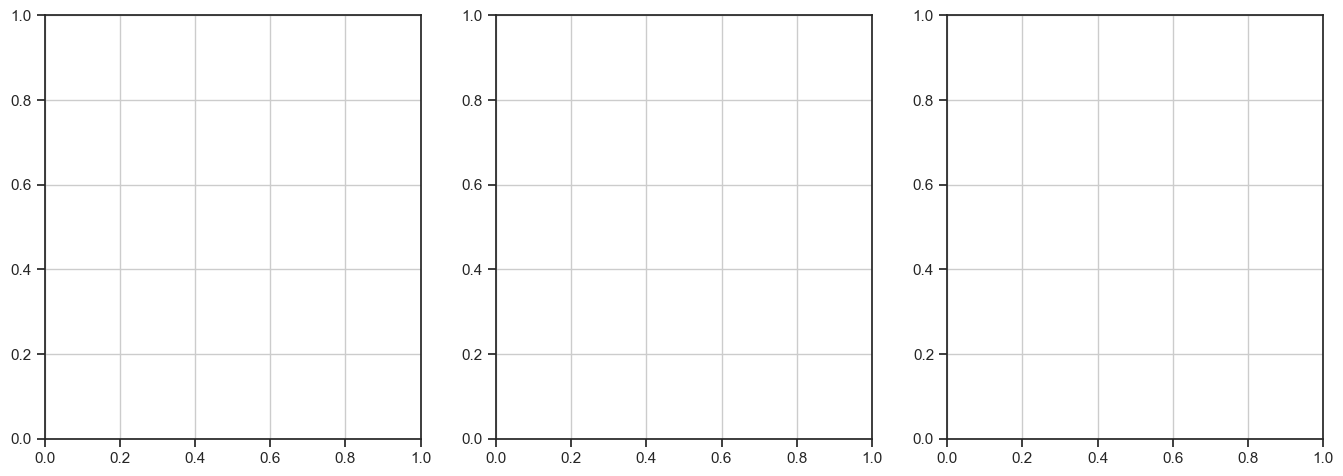

In [31]:
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
importlib.reload(core)

sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks", {'axes.grid': True})

strain_rename = {
    "MMY": "WT",
    "WHI5_BCK2_DD": r"whi5$\Delta$ bck2$\Delta$",
    "WHI5DEL": r"WHI5$\Delta$",
    "BCK2DEL": r"BCK2$\Delta$",
}

palette = {
    "WT": "#c5c9c7",
    r"WHI5$\Delta$": "#c87f89",
    r"BCK2$\Delta$": "#5684ae",
    r"whi5$\Delta$ bck2$\Delta$": "#a87dc2",
}

col_title = {
    'G1_switchers_switchcycle': "G1-switchers",
    'SG2M_switchers_cycleafterswitchcycle': "S/G2/M-switchers",
    'firstSG2M_daughters_cycleafterswitchcycle': "First daughters of S/G2/M-switchers",
}

col_order = [
    'G1_switchers_switchcycle',
    'SG2M_switchers_cycleafterswitchcycle',
    'firstSG2M_daughters_cycleafterswitchcycle',
]
PROPS = {
        'flierprops':{'marker':'D', 'markerfacecolor':'black', 'markeredgecolor':'black', 'markersize': 2}
}
hue_order = ["WT", r"WHI5$\Delta$", r"BCK2$\Delta$", r"whi5$\Delta$ bck2$\Delta$"]

fig, axes = plt.subplots(1, len(col_order), figsize=(16.5, 5.5), sharey=False)
if len(col_order) == 1:
    axes = [axes]


print(figure_plotting_df['strain'].unique())
for i, col_ref in enumerate(col_order):
    ax = axes[i]
    sub = figure_plotting_df[figure_plotting_df["plotting_col_ref"] == col_ref].copy()
    sub["strain_label"] = sub["strain"].map(strain_rename).fillna(sub["strain"])

    print(sub["strain_label"].value_counts())
    order = sorted(
        sub["bin_info"].dropna().unique(),
        key=lambda s: float(str(s).split("-")[0])
    )

    sns.boxplot(
        data=sub,
        x="bin_info",
        y="phase_volume_growth",
        hue="strain_label",
        order=order,
        hue_order=hue_order,
        palette=palette,
        showmeans=True,
        showfliers=True,
        meanprops={
            "marker": "x",
            "markerfacecolor": None,
            "markeredgecolor": "#363737",
            "markersize": "6",
            "markeredgewidth": 1.5,
        },
        ax=ax,
        **PROPS
    )
    
    core.annotate_significance_hue_vs_ref(
        ax=ax,
        df=sub,
        x_col="bin_info",
        y_col="phase_volume_growth",
        hue_col="strain_label",
        x_order=order,
        hue_order=hue_order,
        ref_hue="WT",
        test="mwu",
        min_n=5,
        show_n=True,
    )

    ax.set_title(col_title.get(col_ref, col_ref), fontstyle='italic')
    ax.set_xlabel("Cell volume at start of G1 (binned)", fontsize=12)
    ax.set_ylabel("Δ Volume during G1 (fL)", fontsize=12)
    ax.tick_params(axis='x', rotation=25)
    for bin_info in order:
        sub_stat = sub[sub["bin_info"] == bin_info]
        core.run_stats(
            sub_stat,
            value_cols=["phase_volume_growth"],
            group_col="strain_label"
        )
    

# Guard in case figure has extra axes from layout changes.
for ax in fig.axes[len(col_order):]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

fig.tight_layout(rect=(0, 0, 1, 0.92))
# save
plt.savefig(r'C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\R2.svg')

plt.show()


# ***Revision1: mean cell vol vs frame_i for switchers and first daughters of S/G2/M switchers - WT and DD*** 

In [133]:

######################################### filter for steady state cells with complete G1s only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]
steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


C:\Users\timon\AppData\Local\Temp\ipykernel_23760\2796781830.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


In [134]:
# display(overall_df_with_rel_and_switch_info.S_switch_cells_daughter_wave.dtype)

In [135]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      ]    
firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"
        

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\130744973.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"


In [136]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            ]
G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"        

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3528487262.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"


In [137]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            ]
SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"    

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3006354795.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"


In [138]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth

In [139]:


###############################################  steadystate  #####################################################################

SCD_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCD"]
SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
SCGE_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCGE"]
SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"

figure_plotting_df = pd.concat([SCD_steadystate_df, SCGE_steadystate_df, firstSG2M_daughters_df, G1_switchers_switchcycle_df, SG2M_switchers_switchcycle_df]).reset_index(drop = True)

figure_plotting_df['frame_rel_to_nutrient_switch'] = figure_plotting_df['frame_i'] - 50
figure_plotting_df['time_rel_to_nutrient_switch_hours'] = (figure_plotting_df['frame_rel_to_nutrient_switch']*3)/60

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\464224647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\464224647.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"


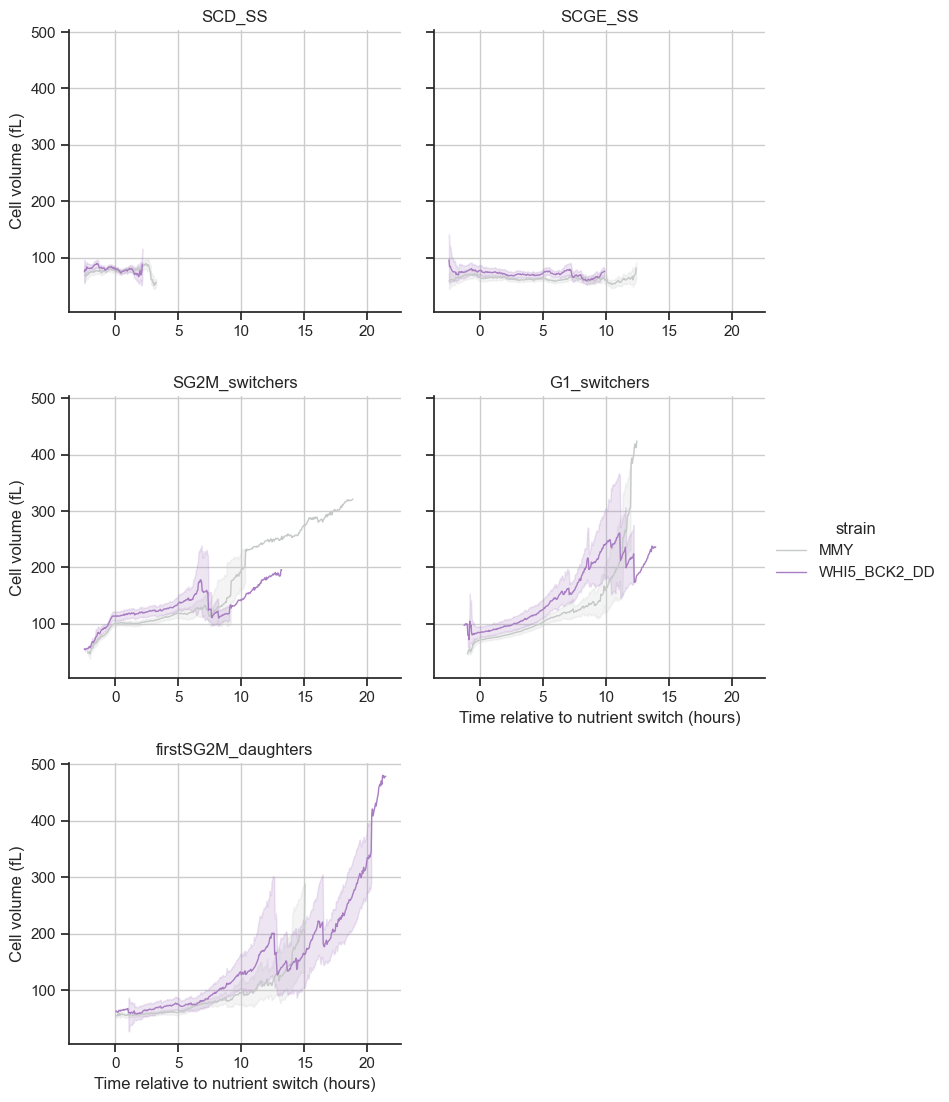

In [140]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df, 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "combined_mother_bud_volume")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set()
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Cell volume (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_mean_cell_vol_vs_time_categoryspecific.png')





plt.show()

# ***Revision1: delta vol since last frame normalised to cell vol at last frame vs frame_i for switchers and first daughters of S/G2/M switchers - WT, WHI5DEL, BCK2DEL and DD*** 

In [141]:
# old delta_vol_norm_cellvol column uses vol at current frame to normalise on. Recalculate by normalising on vol at prev frame. 

# display(overall_df_with_rel_and_switch_info.columns.tolist())
# display(overall_df_with_rel_and_switch_info[["f_pos_cell_id", "cell_cycle_stage", "frame_i", "cell_vol_fl", "cell_vol_fl_rel", "combined_mother_bud_volume", "vol_added_since_prev_frame_fl", "delta_vol_norm_cellvol"]].head(20))

overall_df_with_rel_and_switch_info['delta_vol_norm_cellvol'] = (overall_df_with_rel_and_switch_info['vol_added_since_prev_frame_fl'])/((overall_df_with_rel_and_switch_info['combined_mother_bud_volume']) - (overall_df_with_rel_and_switch_info['vol_added_since_prev_frame_fl']))
# overall_df_with_rel_and_switch_info.drop(columns = ["delta_vol_norm_cellvol_new"], inplace =True)
# display(overall_df_with_rel_and_switch_info[["f_pos_cell_id", "cell_cycle_stage", "frame_i", "cell_vol_fl", "cell_vol_fl_rel", "combined_mother_bud_volume", "vol_added_since_prev_frame_fl", "delta_vol_norm_cellvol"]].head(20))

In [142]:
# old delta_vol_norm_cellvol column uses vol at current frame to normalise on. Recalculate by normalising on vol at prev frame. 
# display(SS_SCDnSCGE.columns.tolist())
SS_SCDnSCGE['delta_vol_norm_cellvol'] = (SS_SCDnSCGE['vol_added_since_last_frame'])/((SS_SCDnSCGE['sys_vol_at_frame_inc_G1_cells']) - (SS_SCDnSCGE['vol_added_since_last_frame']))
# display(SS_SCDnSCGE[["f_pos_cell_id", "frame_i", "cell_vol_fl", "cell_cycle_stage", "rel_vol_atframe", "sys_vol_at_frame_inc_G1_cells", "vol_added_since_last_frame", "delta_vol_norm_cellvol"]].head(20))


In [143]:

######################################### filter for steady state cells with complete G1s only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5DEL")|
                                            (SS_SCDnSCGE['strain'] == "BCK2DEL")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]
steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


C:\Users\timon\AppData\Local\Temp\ipykernel_23760\709235394.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


In [144]:
# display(overall_df_with_rel_and_switch_info.S_switch_cells_daughter_wave.dtype)

In [145]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "BCK2DEL")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      ]    
firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"
        

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\777822905.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"


In [146]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            ]
G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"        

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3528487262.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"


In [147]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            ]
SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"    

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3006354795.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"


In [148]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth

In [149]:


###############################################  steadystate  #####################################################################

SCD_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCD"]
SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
SCGE_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCGE"]
SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"

figure_plotting_df = pd.concat([SCD_steadystate_df, SCGE_steadystate_df, firstSG2M_daughters_df, G1_switchers_switchcycle_df, SG2M_switchers_switchcycle_df]).reset_index(drop = True)

figure_plotting_df['frame_rel_to_nutrient_switch'] = figure_plotting_df['frame_i'] - 50
figure_plotting_df['time_rel_to_nutrient_switch_hours'] = (figure_plotting_df['frame_rel_to_nutrient_switch']*3)/60

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\464224647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\464224647.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"


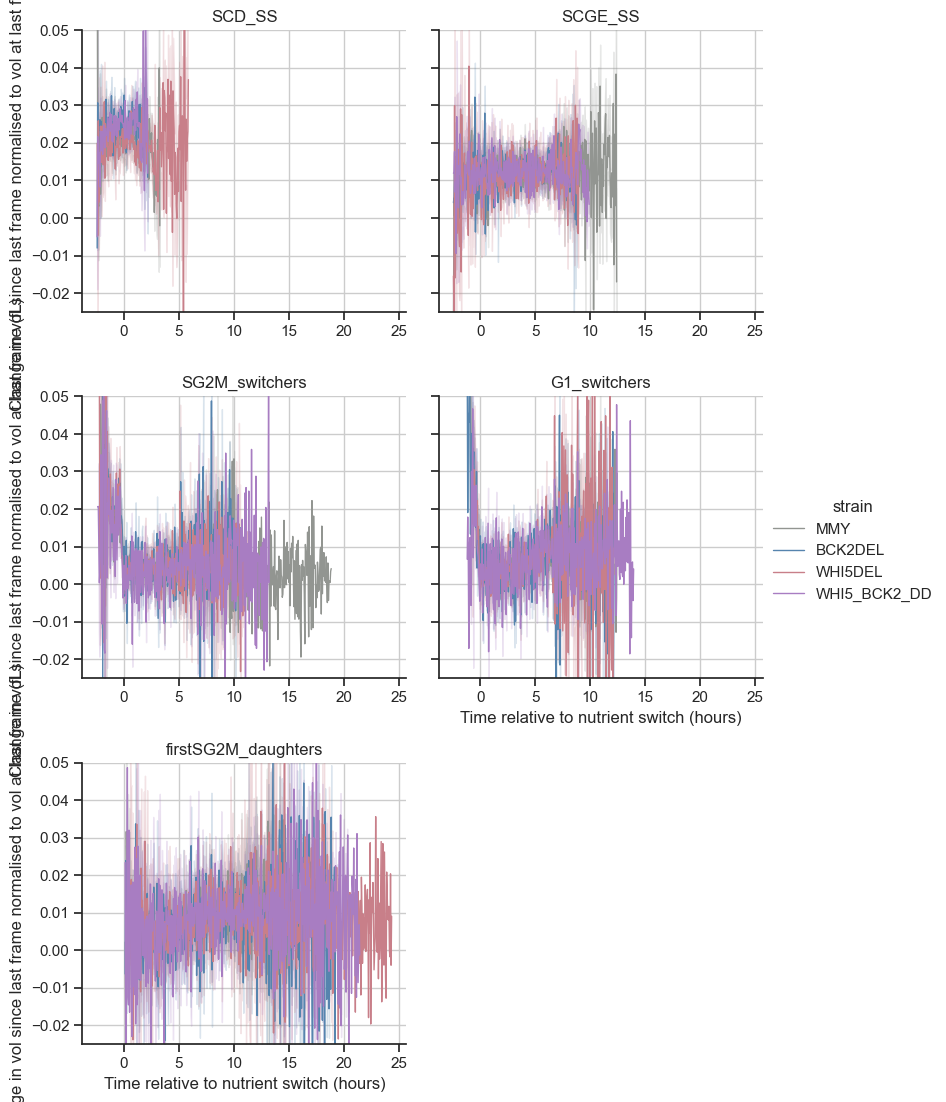

In [150]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df, 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 2,
                  # sharey =False,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.025,0.05))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Change in vol since last frame normalised to vol at last frame (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
# plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_categoryspecific.png')





plt.show()

In [151]:
# display(selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['delta_vol_norm_cellvol'] > 0.05) & (selectedstrains_NS_plotting_df['frame_i'] == 255)][['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'combined_mother_bud_volume', 'f_pos_cell_id', 'directory','delta_vol_norm_cellvol']])

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1674295064.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selectedstrains_NS_plotting_df['frame_rel_to_nutrient_switch'] = selectedstrains_NS_plotting_df['frame_i'] - 50
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1674295064.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selectedstrains_NS_plotting_df['time_rel_to_nutrient_switch_hours'] = (selectedstrains_NS_plotting_df['frame_rel_to_nutrient_switch']*3)/60


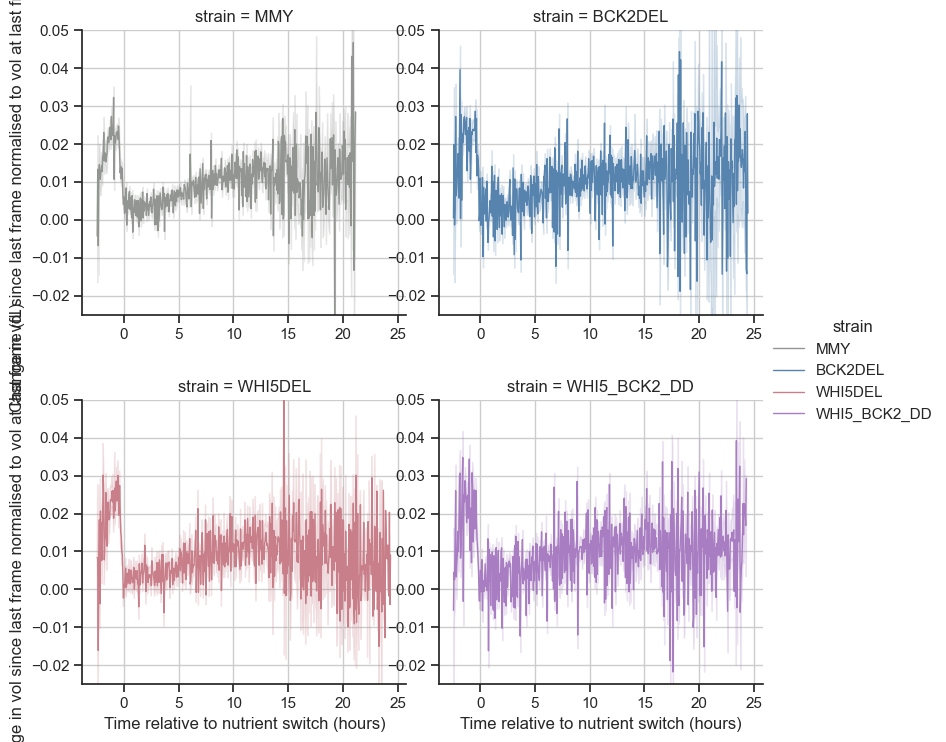

In [152]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)
selectedstrains_NS_plotting_df['frame_rel_to_nutrient_switch'] = selectedstrains_NS_plotting_df['frame_i'] - 50
selectedstrains_NS_plotting_df['time_rel_to_nutrient_switch_hours'] = (selectedstrains_NS_plotting_df['frame_rel_to_nutrient_switch']*3)/60
selectedstrains_NS_plotting_df = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['complete_phase'] == 1]

b = sns.FacetGrid(selectedstrains_NS_plotting_df, 
                  # col = "plotting_col_ref", 
                  # col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  col = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 2,
                  sharey =False,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
# b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.025,0.05))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Change in vol since last frame normalised to vol at last frame (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
# plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_categoryspecific.png')





plt.show()

In [153]:
categories_pooled_appending_list = []

for strain in selectedstrains_NS_plotting_df['strain'].unique():
    strain_df = selectedstrains_NS_plotting_df[selectedstrains_NS_plotting_df['strain'] == strain]
    strain_df.sort_values(by = "frame_i", inplace=True)
    for frame in strain_df['frame_i'].unique():
        frame_df = strain_df[strain_df['frame_i'] == frame]
        if len(frame_df['position'].unique()) > 1:
            time_rel_to_nutrient_switch_hours = frame_df['time_rel_to_nutrient_switch_hours'].iloc[0]
            frame_avg_deltavol_norm = frame_df['delta_vol_norm_cellvol'].mean()
            info = { 
                    'strain': strain,
                    'frame_i': frame,
                    'time_rel_to_nutrient_switch_hours': time_rel_to_nutrient_switch_hours,
                    'frame_avg_deltavol_norm': frame_avg_deltavol_norm
                    }
            categories_pooled_appending_list.append(info)
                
categories_pooled_with_ma = pd.DataFrame.from_dict(categories_pooled_appending_list)  

display(categories_pooled_with_ma.head(20))


C:\Users\timon\AppData\Local\Temp\ipykernel_23760\325048140.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df.sort_values(by = "frame_i", inplace=True)


,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm
0,MMY,1,-2.45,-0.004260
1,MMY,2,-2.40,0.013308
2,MMY,3,-2.35,-0.006845
3,MMY,4,-2.30,0.012193
4,MMY,5,-2.25,0.014543
5,MMY,6,-2.20,0.011460
6,MMY,7,-2.15,0.010651
7,MMY,8,-2.10,0.012939
8,MMY,9,-2.05,0.014280
9,MMY,10,-2.00,0.012681


In [154]:
display(categories_pooled_with_ma[categories_pooled_with_ma['frame_avg_deltavol_norm'] > 0.05])

,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm


In [155]:
appending_list = []

for strain in categories_pooled_with_ma['strain'].unique():
    strain_df = categories_pooled_with_ma[categories_pooled_with_ma['strain'] == strain]
    strain_df.sort_values(by = "frame_i", inplace=True)
    strain_df['moving_avg_delta_vol_norm_cellvol'] = strain_df['frame_avg_deltavol_norm'].rolling(10, min_periods = 3).mean()
    appending_list.append(strain_df)
categories_pooled_with_ma = pd.concat(appending_list).reset_index(drop= True)        
display(categories_pooled_with_ma.head(20))

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\4228734122.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df.sort_values(by = "frame_i", inplace=True)
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\4228734122.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df['moving_avg_delta_vol_norm_cellvol'] = strain_df['frame_avg_deltavol_norm'].rolling(10, min_periods = 3).mean()
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\4228734122.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the ca

,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm,moving_avg_delta_vol_norm_cellvol
0,MMY,1,-2.45,-0.004260,NaN
1,MMY,2,-2.40,0.013308,NaN
2,MMY,3,-2.35,-0.006845,0.000734
3,MMY,4,-2.30,0.012193,0.003599
4,MMY,5,-2.25,0.014543,0.005788
5,MMY,6,-2.20,0.011460,0.006733
6,MMY,7,-2.15,0.010651,0.007293
7,MMY,8,-2.10,0.012939,0.007999
8,MMY,9,-2.05,0.014280,0.008697
9,MMY,10,-2.00,0.012681,0.009095


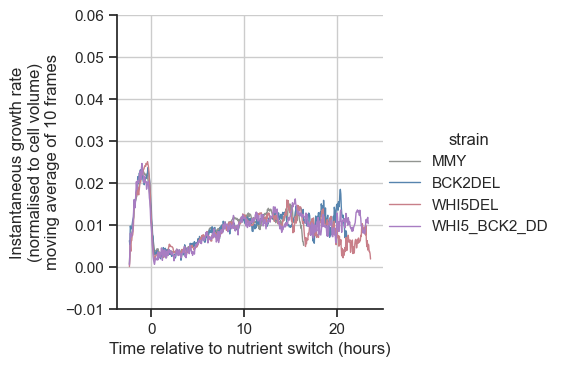

In [156]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(categories_pooled_with_ma, 
                  # col = "plotting_col_ref", 
                  # col_order =[ 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  # row = "strain",
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  # col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "moving_avg_delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
# b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.01,0.06))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Instantaneous growth rate\n(normalised to cell volume)\nmoving average of 10 frames")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_pooled.png')
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_pooled.svg')
plt.savefig(r'C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\R3_1.svg')




plt.show()

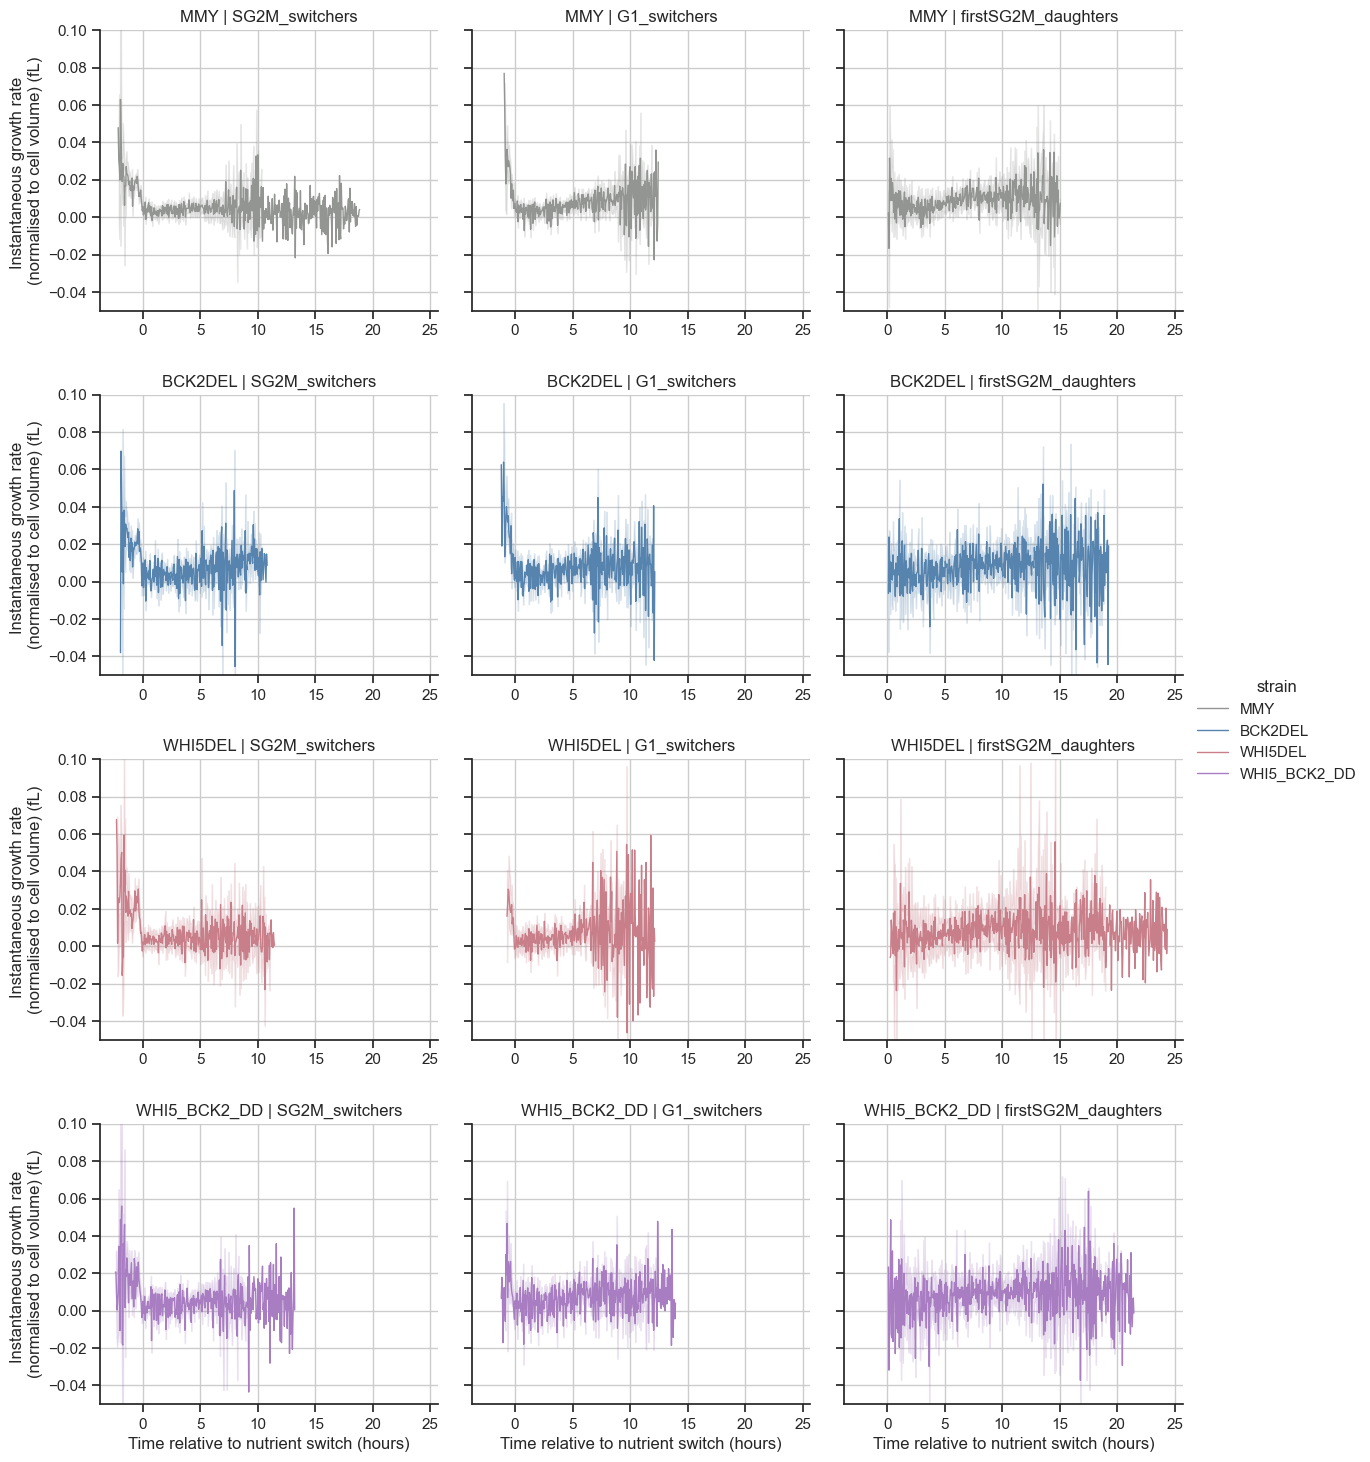

In [157]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df[(figure_plotting_df["plotting_col_ref"] == "G1_switchers") | 
                                      (figure_plotting_df["plotting_col_ref"] == "SG2M_switchers") |
                                    (figure_plotting_df["plotting_col_ref"] == "firstSG2M_daughters")], 
                  col = "plotting_col_ref", 
                  col_order =[ 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  row = "strain",
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  # col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.05,0.1))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Instantaneous growth rate \n(normalised to cell volume) (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
# plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_categoryspecific.png')





plt.show()

In [158]:
appending_list = []
for category in figure_plotting_df['plotting_col_ref'].unique():
    category_df = figure_plotting_df[figure_plotting_df['plotting_col_ref'] == category]
    for strain in category_df['strain'].unique():
        strain_df = category_df[category_df['strain'] == strain]
        strain_df.sort_values(by = "frame_i", inplace=True)
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            if len(frame_df['position'].unique()) > 1:
                time_rel_to_nutrient_switch_hours = frame_df['time_rel_to_nutrient_switch_hours'].iloc[0]
                frame_avg_deltavol_norm = frame_df['delta_vol_norm_cellvol'].mean()
                info = {'plotting_col_ref': category, 
                        'strain': strain,
                        'frame_i': frame,
                        'time_rel_to_nutrient_switch_hours': time_rel_to_nutrient_switch_hours,
                        'frame_avg_deltavol_norm': frame_avg_deltavol_norm
                        }
                appending_list.append(info)
                
figure_plotting_df_with_ma = pd.DataFrame.from_dict(appending_list)  

display(figure_plotting_df_with_ma.head(20))


C:\Users\timon\AppData\Local\Temp\ipykernel_23760\1734368068.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df.sort_values(by = "frame_i", inplace=True)


,plotting_col_ref,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm
0,SCD_SS,MMY,1,-2.45,0.085246
1,SCD_SS,MMY,2,-2.40,0.013710
2,SCD_SS,MMY,3,-2.35,0.003676
3,SCD_SS,MMY,4,-2.30,0.003130
4,SCD_SS,MMY,5,-2.25,0.015546
5,SCD_SS,MMY,6,-2.20,0.024981
6,SCD_SS,MMY,7,-2.15,0.006359
7,SCD_SS,MMY,8,-2.10,0.011174
8,SCD_SS,MMY,9,-2.05,0.017674
9,SCD_SS,MMY,10,-2.00,0.026765


In [159]:
appending_list = []
for category in figure_plotting_df_with_ma['plotting_col_ref'].unique():
    category_df = figure_plotting_df_with_ma[figure_plotting_df_with_ma['plotting_col_ref'] == category]
    for strain in category_df['strain'].unique():
        strain_df = category_df[category_df['strain'] == strain]
        strain_df.sort_values(by = "frame_i", inplace=True)
        strain_df['moving_avg_delta_vol_norm_cellvol'] = strain_df['frame_avg_deltavol_norm'].rolling(10, min_periods = 3).mean()
        appending_list.append(strain_df)
figure_plotting_df_with_ma = pd.concat(appending_list).reset_index(drop= True)        
display(figure_plotting_df_with_ma.head(20))

C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3332681188.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df.sort_values(by = "frame_i", inplace=True)
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3332681188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df['moving_avg_delta_vol_norm_cellvol'] = strain_df['frame_avg_deltavol_norm'].rolling(10, min_periods = 3).mean()
C:\Users\timon\AppData\Local\Temp\ipykernel_23760\3332681188.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the ca

,plotting_col_ref,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm,moving_avg_delta_vol_norm_cellvol
0,SCD_SS,MMY,1,-2.45,0.085246,NaN
1,SCD_SS,MMY,2,-2.40,0.013710,NaN
2,SCD_SS,MMY,3,-2.35,0.003676,0.034211
3,SCD_SS,MMY,4,-2.30,0.003130,0.026440
4,SCD_SS,MMY,5,-2.25,0.015546,0.024262
5,SCD_SS,MMY,6,-2.20,0.024981,0.024381
6,SCD_SS,MMY,7,-2.15,0.006359,0.021807
7,SCD_SS,MMY,8,-2.10,0.011174,0.020478
8,SCD_SS,MMY,9,-2.05,0.017674,0.020166
9,SCD_SS,MMY,10,-2.00,0.026765,0.020826


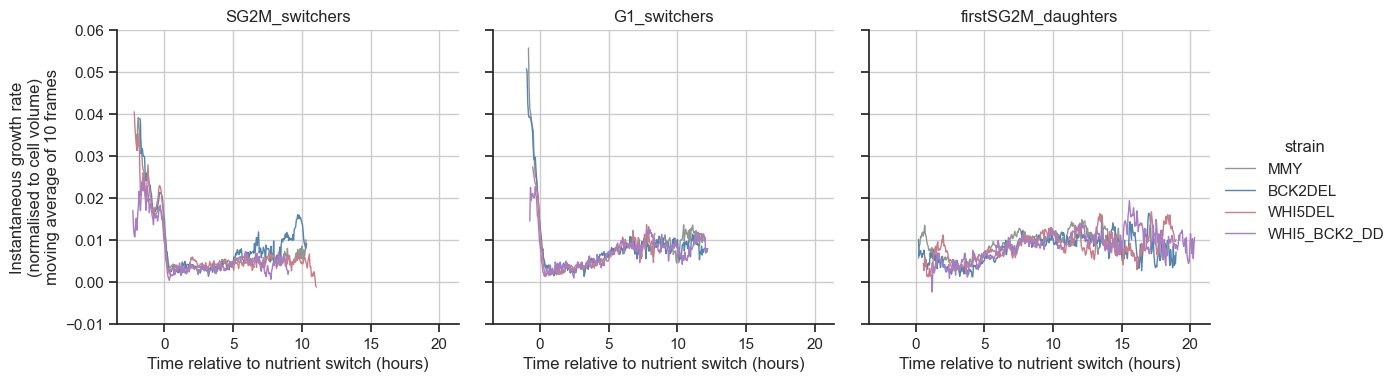

In [160]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df_with_ma[(figure_plotting_df_with_ma["plotting_col_ref"] == "G1_switchers") | 
                                      (figure_plotting_df_with_ma["plotting_col_ref"] == "SG2M_switchers") |
                                    (figure_plotting_df_with_ma["plotting_col_ref"] == "firstSG2M_daughters")], 
                  col = "plotting_col_ref", 
                  col_order =[ 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  # row = "strain",
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  # col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "moving_avg_delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.01,0.06))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Instantaneous growth rate\n(normalised to cell volume)\nmoving average of 10 frames")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_categoryspecific.png')
#plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_categoryspecific.svg')



plt.savefig(r'C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\R3_2.svg')

plt.show()